# Финальный сборный ноутбук ВКР

**«Кросс-доменная адаптация мультимодальных методов детекции контрафакта на маркетплейсе»**

**Мкоян Диана, НИУ ВШЭ ФКН, ПМИ 01.04.02, 2026**

## Headline-результаты на индивидуальном протоколе автора (test = 26 327)

| Модель | ROC-AUC | PR-AUC | R@P ≥ 0,9 |
|---|---|---|---|
| M2 mainline (calibrated, ноут 02) | 0,9612 | 0,7228 | 0,1600 |
| M5 OOF Stacking | 0,9561 | 0,7167 | 0,2109 |
| M2-FE+ одиночно (§ 4.4.3.2) | **0,9661** | **0,7399** | 0,2213 |
| **M2-FE+ + M2 mainline 50/50 (headline по PR)** | **0,9690** | **0,7556** | 0,2600 |
| **M2-FE+ + M2 mainline w=0,75 (headline по R@P)** | 0,9678 | 0,7530 | **0,2747** |

## Headline на едином командном тестовом сплите (test = 58 410, Глава 5)

| Модель | PR-AUC | R@P ≥ 0,9 |
|---|---|---|
| M2-FE+ + M2(clean) 50/50 | **0,7482** (bootstrap-tie с лидером 0,7484) | 0,0872 |

## Структура ноута

1. **§ I. EDA** — из `01_eda_defense.ipynb`
2. **§ II. M1–M5** — из `02_reproduction_fixed.ipynb`
3. **§ III. Каскад CLIP** — из `03_original_hybrid_cascade.ipynb`
4. **§ IV. Каскад Qwen2.5 + LoRA** — из `04_lmm_reasoning.ipynb`
5. **§ V. Qwen2-VL** — из `artifacts_qwen2vl/executed_05_qwen2vl.ipynb`


---

## § I. Разведочный анализ данных

*Источник: `01_eda_defense.ipynb` — 11 защитных визуализаций EDA, обоснование seller-based split, анализ визуальной модальности.*

# EDA: защитная версия (топ-15 визуализаций для презентации)

**Цель:** компактный EDA, прицельно отвечающий на вопросы комиссии. Все графики готовы для слайдов защиты. Полный анализ — в `01_eda-2.ipynb`.

**Структура:** 5 блоков по 3 ключевых наблюдения, каждое подкреплено графиком.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from scipy.stats import mannwhitneyu

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100

ROOT = Path('/Users/diana/master-thesis-2025')
DATA_PATH = ROOT / "Diana's folder" / 'ml_ozon_ounterfeit_train.csv'
OUT = ROOT / 'new_diploma' / 'real_estate_approaches' / 'eda_figures'
OUT.mkdir(parents=True, exist_ok=True)

SEED = 42
TARGET = 'resolution'

## Блок 1: Описание датасета

Датасет Ozon eCup 2025: ключевые цифры
  Общее число товаров            197198
  Контрафактных (positive)       13052
  Доля контрафакта               6.62%
  Уникальных продавцов           11167
  Уникальных брендов             4066
  Категорий товаров              634
  Всего признаков                45


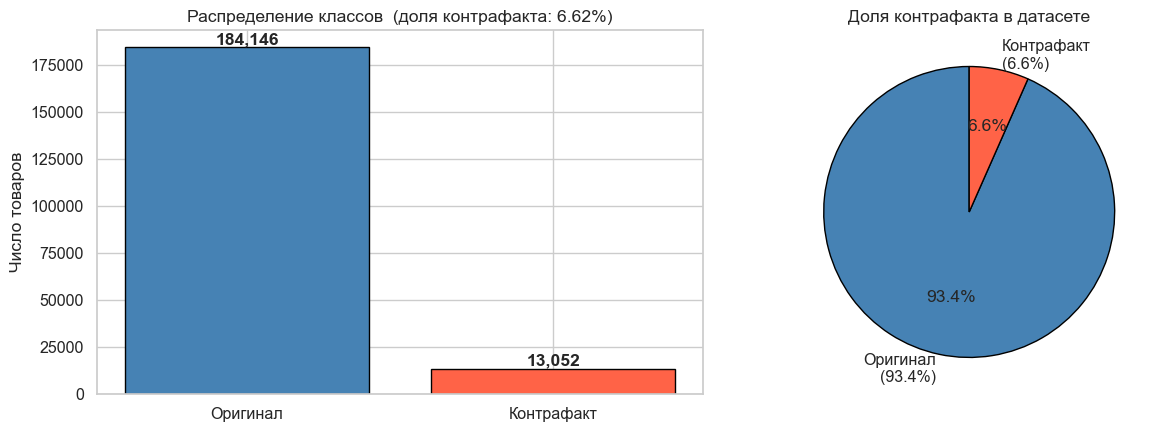

In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8')

# Сводная статистика для слайда «Описание данных»
stats = {
    'Общее число товаров': len(df),
    'Контрафактных (positive)': int(df[TARGET].sum()),
    'Доля контрафакта': f'{df[TARGET].mean():.2%}',
    'Уникальных продавцов': df['SellerID'].nunique(),
    'Уникальных брендов': df['brand_name'].nunique(),
    'Категорий товаров': df['CommercialTypeName4'].nunique(),
    'Всего признаков': df.shape[1],
}

print('=' * 50)
print('Датасет Ozon eCup 2025: ключевые цифры')
print('=' * 50)
for k, v in stats.items():
    print(f'  {k:<30} {v}')

# Гистограмма по классам
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

counts = df[TARGET].value_counts()
axes[0].bar(['Оригинал', 'Контрафакт'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_ylabel('Число товаров')
axes[0].set_title(f'Распределение классов  (доля контрафакта: {df[TARGET].mean():.2%})')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

# Pie
axes[1].pie(counts.values, labels=['Оригинал\n(93.4%)', 'Контрафакт\n(6.6%)'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Доля контрафакта в датасете')

plt.tight_layout()
plt.savefig(OUT / 'fig01_class_balance.png', dpi=120, bbox_inches='tight')
plt.show()

**Ключевой вывод для слайда:** дисбаланс 14:1 → accuracy неинформативна, нужны PR-AUC и Recall@Precision.

## Блок 2: Обоснование seller-based split (методологический результат)

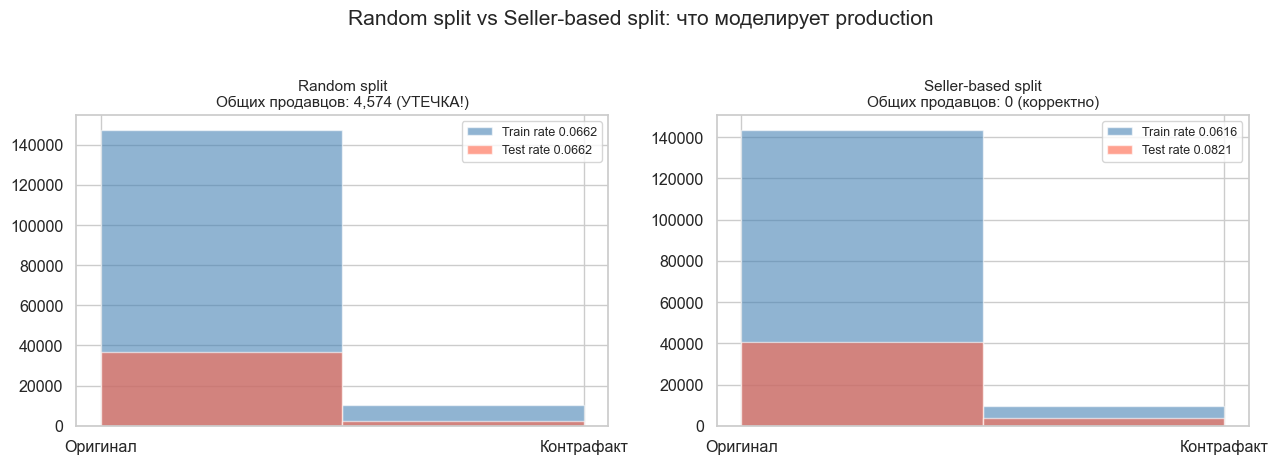


Главное:
  Random split — train и test делят 4,574 продавцов → модель запоминает «seller signature», метрики завышены
  Seller-based split — продавцы непересекающиеся, моделирует production


In [3]:
# Сравнение распределений seller-counterfeit_rate в train vs test при random vs seller split
from sklearn.model_selection import GroupShuffleSplit

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Random split
tr_rnd, te_rnd = train_test_split(df, test_size=0.20, random_state=SEED, stratify=df[TARGET])
shared_random = set(tr_rnd['SellerID']) & set(te_rnd['SellerID'])

axes[0].hist(tr_rnd[TARGET], bins=2, alpha=0.6, label=f'Train rate {tr_rnd[TARGET].mean():.4f}', color='steelblue')
axes[0].hist(te_rnd[TARGET], bins=2, alpha=0.6, label=f'Test rate {te_rnd[TARGET].mean():.4f}', color='tomato')
axes[0].set_title(f'Random split\nОбщих продавцов: {len(shared_random):,} (УТЕЧКА!)', fontsize=11)
axes[0].legend(fontsize=9); axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Оригинал', 'Контрафакт'])

# Seller-based split
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
tr_idx, te_idx = next(gss.split(df, df[TARGET], groups=df['SellerID']))
tr_sel = df.iloc[tr_idx]
te_sel = df.iloc[te_idx]
shared_seller = set(tr_sel['SellerID']) & set(te_sel['SellerID'])

axes[1].hist(tr_sel[TARGET], bins=2, alpha=0.6, label=f'Train rate {tr_sel[TARGET].mean():.4f}', color='steelblue')
axes[1].hist(te_sel[TARGET], bins=2, alpha=0.6, label=f'Test rate {te_sel[TARGET].mean():.4f}', color='tomato')
axes[1].set_title(f'Seller-based split\nОбщих продавцов: {len(shared_seller)} (корректно)', fontsize=11)
axes[1].legend(fontsize=9); axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Оригинал', 'Контрафакт'])

plt.suptitle('Random split vs Seller-based split: что моделирует production', y=1.03)
plt.tight_layout()
plt.savefig(OUT / 'fig02_split_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nГлавное:')
print(f'  Random split — train и test делят {len(shared_random):,} продавцов → модель запоминает «seller signature», метрики завышены')
print(f'  Seller-based split — продавцы непересекающиеся, моделирует production')

**Ключевой вывод для слайда:** при seller-based split возникает covariate shift (test rate выше train rate) — продавцы с высокой долей контрафакта непропорционально попадают в test. Это объясняет, почему R@P≥0,9 драматически падает по сравнению с random split (см. § 2.2 главы 2 диплома).

## Блок 3: Информативность пропущенных значений

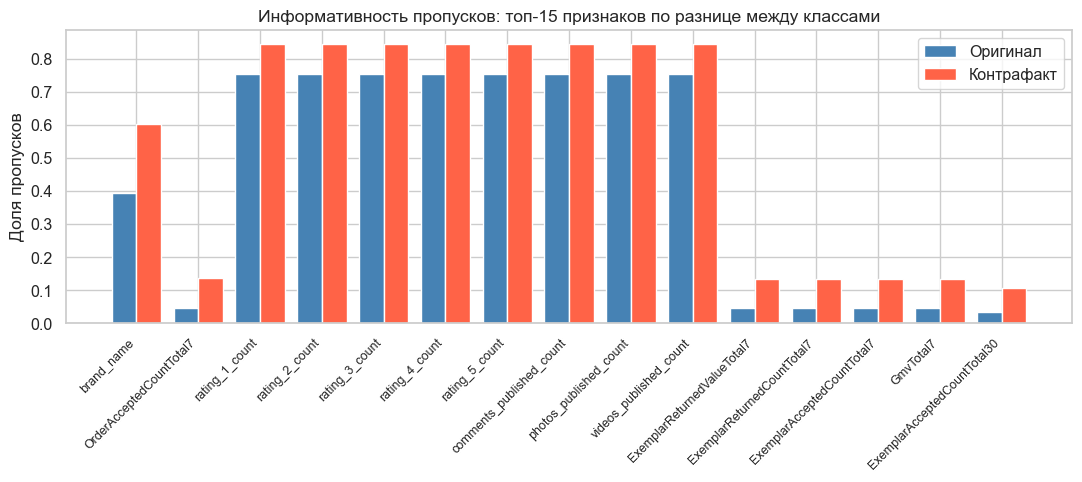


Главное: сами пропуски являются сигналом — `_is_null` признаки попадают в модель как fingerprint


In [4]:
# Доля пропусков по топ-15 признакам с наибольшей разницей между классами
miss_by_class = df.groupby(TARGET).apply(lambda x: x.isnull().mean()).T
miss_by_class.columns = ['Original', 'Counterfeit']
miss_by_class['Diff'] = (miss_by_class['Counterfeit'] - miss_by_class['Original']).abs()
miss_top = miss_by_class[miss_by_class['Original'] + miss_by_class['Counterfeit'] > 0]\
    .sort_values('Diff', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(miss_top))
ax.bar(x - 0.2, miss_top['Original'], 0.4, label='Оригинал', color='steelblue')
ax.bar(x + 0.2, miss_top['Counterfeit'], 0.4, label='Контрафакт', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(miss_top.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Доля пропусков')
ax.set_title('Информативность пропусков: топ-15 признаков по разнице между классами')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'fig03_missing_informative.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nГлавное: сами пропуски являются сигналом — `_is_null` признаки попадают в модель как fingerprint')

## Блок 4: Топ-признаки по Mutual Information

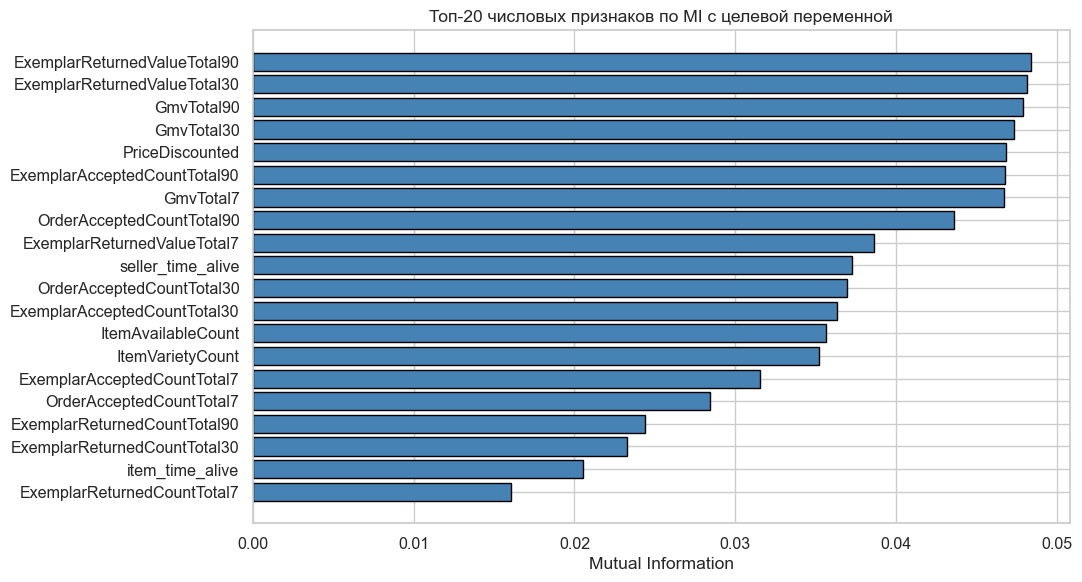


Главное: финансовые агрегаты (GmvTotal30/90, ExemplarReturned*) — самые информативные;
time-based (item_time_alive, seller_time_alive) имеют умеренный MI при сильной линейной корреляции →
нелинейные взаимодействия → нужен ансамбль (CatBoost)


In [5]:
# Используем числовые признаки для MI
num_cols = [c for c in df.columns if df[c].dtype in (np.float64, np.int64) and c not in ['id', 'ItemID', 'SellerID', TARGET]]
X_mi = df[num_cols].fillna(-1).to_numpy()
y_mi = df[TARGET].to_numpy()

# MI на сэмпле для скорости
sample = np.random.default_rng(SEED).choice(len(df), size=min(30000, len(df)), replace=False)
mi = mutual_info_classif(X_mi[sample], y_mi[sample], random_state=SEED, n_neighbors=3)
mi_df = pd.DataFrame({'feature': num_cols, 'MI': mi}).sort_values('MI', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(mi_df['feature'][::-1], mi_df['MI'][::-1], color='steelblue', edgecolor='black')
ax.set_xlabel('Mutual Information')
ax.set_title('Топ-20 числовых признаков по MI с целевой переменной')
plt.tight_layout()
plt.savefig(OUT / 'fig04_mutual_info.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nГлавное: финансовые агрегаты (GmvTotal30/90, ExemplarReturned*) — самые информативные;')
print('time-based (item_time_alive, seller_time_alive) имеют умеренный MI при сильной линейной корреляции →')
print('нелинейные взаимодействия → нужен ансамбль (CatBoost)')

## Блок 5: Сравнение распределений ключевых признаков по классам

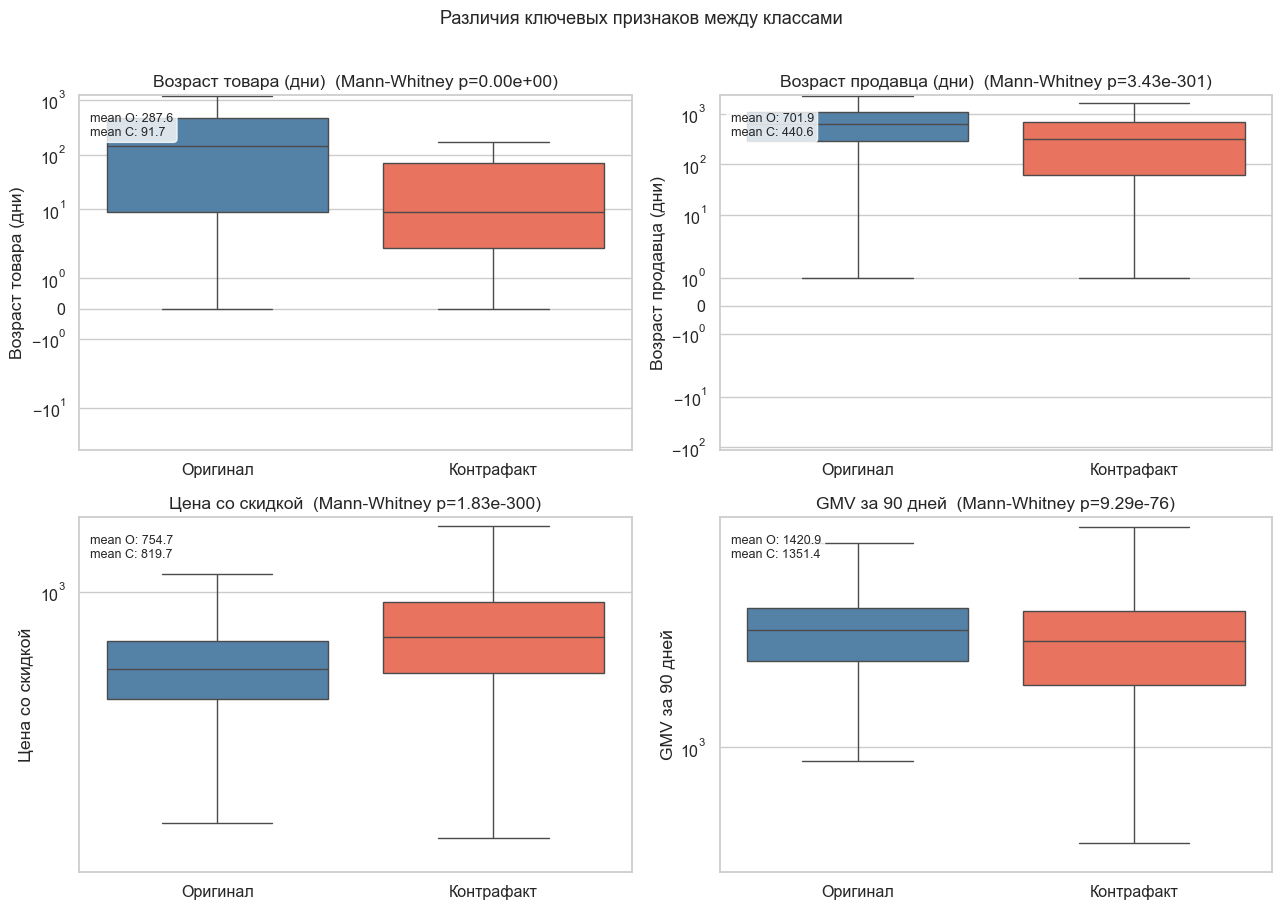


Главное: все распределения статистически различимы (p << 0.001), но сильно перекрываются →
   ни один признак сам по себе не разделяет классы → нужна мультимодальная модель


In [6]:
key_features = [
    ('item_time_alive', 'Возраст товара (дни)', 'log'),
    ('seller_time_alive', 'Возраст продавца (дни)', 'log'),
    ('PriceDiscounted', 'Цена со скидкой', 'log'),
    ('GmvTotal90', 'GMV за 90 дней', 'log'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (col, label, scale) in zip(axes.flatten(), key_features):
    data = df[df[col].notna() & (df[col] >= 0)].copy()
    data['cls_str'] = data[TARGET].map({0: 'Оригинал', 1: 'Контрафакт'})
    orig = data[data[TARGET] == 0][col]
    cnt = data[data[TARGET] == 1][col]

    # Mann-Whitney U test
    stat, pval = mannwhitneyu(
        orig.sample(min(len(orig), 30000), random_state=SEED),
        cnt.sample(min(len(cnt), 5000), random_state=SEED),
        alternative='two-sided'
    )

    sns.boxplot(
        data=data, x='cls_str', y=col, ax=ax, showfliers=False,
        palette={'Оригинал': 'steelblue', 'Контрафакт': 'tomato'},
        order=['Оригинал', 'Контрафакт'], hue='cls_str', legend=False,
    )
    if scale == 'log':
        ax.set_yscale('symlog')
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.set_title(f'{label}  (Mann-Whitney p={pval:.2e})')

    ax.text(0.02, 0.95, f'mean O: {orig.mean():.1f}\nmean C: {cnt.mean():.1f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

plt.suptitle('Различия ключевых признаков между классами', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT / 'fig05_class_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nГлавное: все распределения статистически различимы (p << 0.001), но сильно перекрываются →')
print('   ни один признак сам по себе не разделяет классы → нужна мультимодальная модель')

## Блок 6: FADAML-feature: price_ratio (главный заимствованный признак)

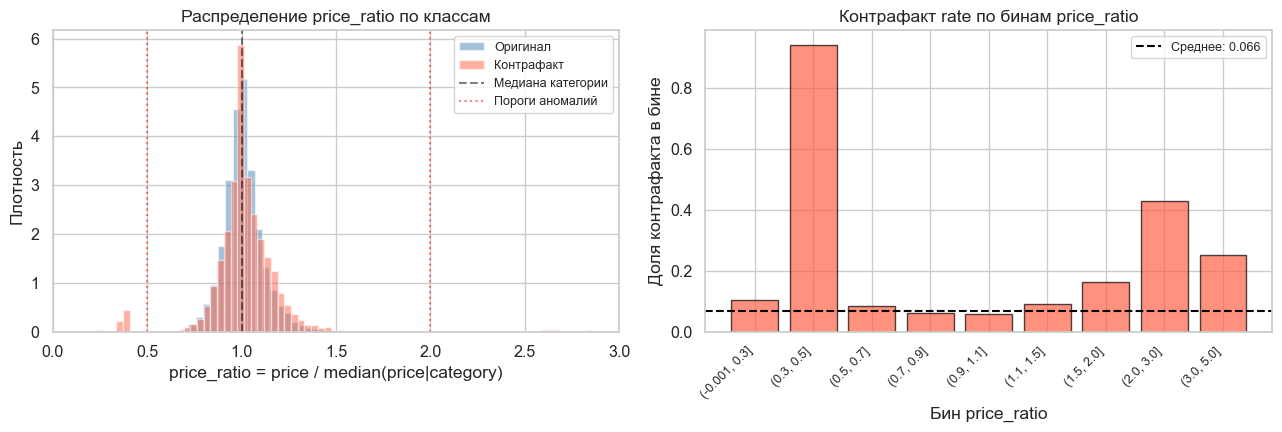


Главное: price_ratio имеет U-образную зависимость с целевой переменной — экстремально низкие
   (демпинг) и экстремально высокие (имитация премиума) цены чаще ассоциированы с контрафактом.
   Это и есть FADAML-сигнал (Nguyen et al. 2025), попавший в топ-9 SHAP финальной модели.


In [7]:
# Вычисляем price_ratio = price / median(price | category)
cat_median = df.groupby('CommercialTypeName4')['PriceDiscounted'].transform('median')
df['price_ratio'] = df['PriceDiscounted'].fillna(0) / cat_median.replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Распределение price_ratio по классам
valid = df[df['price_ratio'].notna() & (df['price_ratio'] > 0) & (df['price_ratio'] < 5)]
for cls, color, label in [(0, 'steelblue', 'Оригинал'), (1, 'tomato', 'Контрафакт')]:
    sub = valid[valid[TARGET] == cls]
    axes[0].hist(sub['price_ratio'], bins=80, alpha=0.5, density=True, color=color, label=label)
axes[0].axvline(1.0, color='black', linestyle='--', alpha=0.5, label='Медиана категории')
axes[0].axvline(0.5, color='red', linestyle=':', alpha=0.5)
axes[0].axvline(2.0, color='red', linestyle=':', alpha=0.5, label='Пороги аномалий')
axes[0].set_xlabel('price_ratio = price / median(price|category)')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Распределение price_ratio по классам')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 3)

# Доля контрафакта по бинам price_ratio
bins = [0, 0.3, 0.5, 0.7, 0.9, 1.1, 1.5, 2.0, 3.0, 5.0]
df['pr_bin'] = pd.cut(df['price_ratio'], bins=bins, include_lowest=True)
by_bin = df.groupby('pr_bin')[TARGET].agg(['mean', 'count']).reset_index()
by_bin['pr_bin_str'] = by_bin['pr_bin'].astype(str)

axes[1].bar(range(len(by_bin)), by_bin['mean'], color='tomato', alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(by_bin)))
axes[1].set_xticklabels(by_bin['pr_bin_str'], rotation=45, ha='right', fontsize=9)
axes[1].axhline(df[TARGET].mean(), color='black', linestyle='--', label=f'Среднее: {df[TARGET].mean():.3f}')
axes[1].set_xlabel('Бин price_ratio')
axes[1].set_ylabel('Доля контрафакта в бине')
axes[1].set_title('Контрафакт rate по бинам price_ratio')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT / 'fig06_price_ratio.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nГлавное: price_ratio имеет U-образную зависимость с целевой переменной — экстремально низкие')
print('   (демпинг) и экстремально высокие (имитация премиума) цены чаще ассоциированы с контрафактом.')
print('   Это и есть FADAML-сигнал (Nguyen et al. 2025), попавший в топ-9 SHAP финальной модели.')

## Блок 7: Анализ продавцов (объяснение, почему seller-based split необходим)

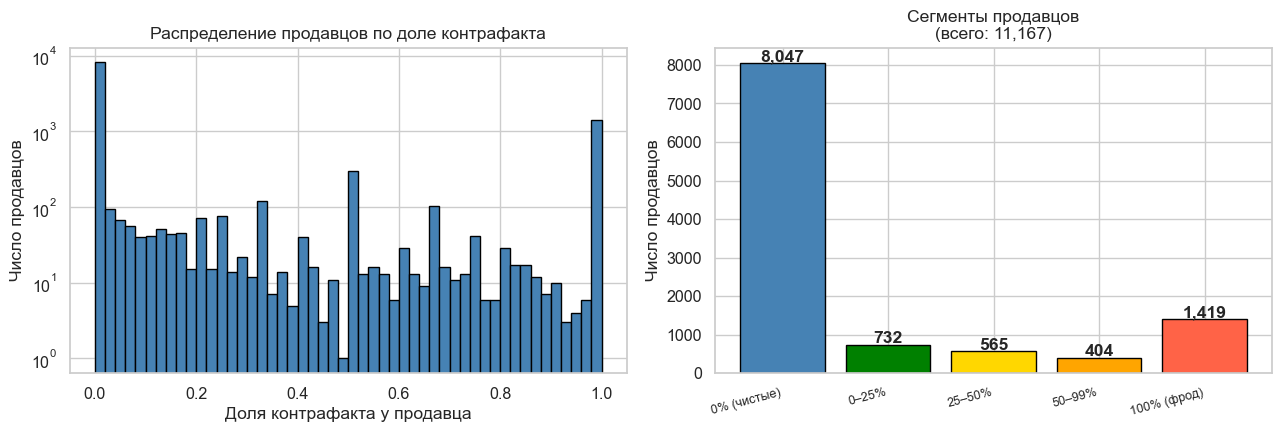


Корреляция seller_counterfeit_rate с target: 0.7935
Этот признак НЕЛЬЗЯ использовать без LOO-encoding — он несёт информацию о метке.


In [8]:
seller_stats = df.groupby('SellerID').agg(
    n_items=('id', 'count'),
    counterfeit_rate=(TARGET, 'mean'),
    counterfeit_count=(TARGET, 'sum'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Распределение counterfeit_rate по продавцам
axes[0].hist(seller_stats['counterfeit_rate'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Доля контрафакта у продавца')
axes[0].set_ylabel('Число продавцов')
axes[0].set_title('Распределение продавцов по доле контрафакта')
axes[0].set_yscale('log')

# Бинаризованное
buckets = [
    ('0% (чистые)', (seller_stats['counterfeit_rate'] == 0).sum()),
    ('0–25%', ((seller_stats['counterfeit_rate'] > 0) & (seller_stats['counterfeit_rate'] <= 0.25)).sum()),
    ('25–50%', ((seller_stats['counterfeit_rate'] > 0.25) & (seller_stats['counterfeit_rate'] <= 0.5)).sum()),
    ('50–99%', ((seller_stats['counterfeit_rate'] > 0.5) & (seller_stats['counterfeit_rate'] < 1)).sum()),
    ('100% (фрод)', (seller_stats['counterfeit_rate'] == 1).sum()),
]
names, counts = zip(*buckets)
axes[1].bar(names, counts, color=['steelblue', 'green', 'gold', 'orange', 'tomato'], edgecolor='black')
axes[1].set_ylabel('Число продавцов')
axes[1].set_title(f'Сегменты продавцов\n(всего: {len(seller_stats):,})')
for i, v in enumerate(counts):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
plt.setp(axes[1].get_xticklabels(), rotation=15, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig(OUT / 'fig07_seller_segments.png', dpi=120, bbox_inches='tight')
plt.show()

# Корреляция признака seller_counterfeit_rate с target — иллюстрация проблемы leakage
df_with_seller_rate = df.merge(seller_stats[['SellerID', 'counterfeit_rate']],
                                 on='SellerID', how='left')
corr = df_with_seller_rate['counterfeit_rate'].corr(df_with_seller_rate[TARGET])
print(f'\nКорреляция seller_counterfeit_rate с target: {corr:.4f}')
print(f'Этот признак НЕЛЬЗЯ использовать без LOO-encoding — он несёт информацию о метке.')

**Ключевой вывод:** из 11 167 продавцов 72% «чистых» и ~13% полностью занимаются контрафактом. Признак `seller_counterfeit_rate` коррелирует с меткой на +0.79, но на test применять нельзя — для новых продавцов это значение неизвестно. Решение: LOO target encoding по бренду и категории.

## Блок 8: Корреляционная матрица топ-признаков

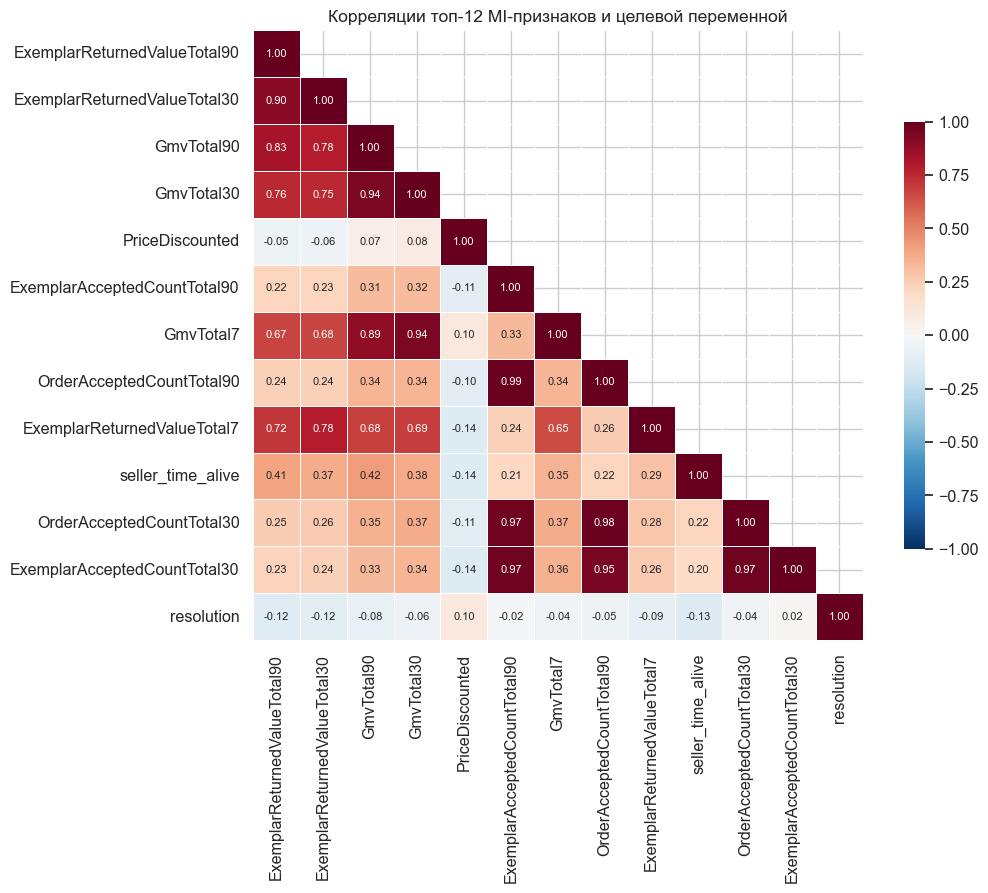

In [9]:
# Корреляция топ-MI признаков с target
top_features_for_corr = list(mi_df['feature'].head(12)) + [TARGET]
corr_matrix = df[top_features_for_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.7}, ax=ax, annot_kws={'fontsize': 8})
ax.set_title('Корреляции топ-12 MI-признаков и целевой переменной')
plt.tight_layout()
plt.savefig(OUT / 'fig08_correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Блок 9: Анализ изображений — почему image-only не работает на маркетплейсе

Items with CLIP embeddings: 187,604 / 197,198


Computing t-SNE (~30 sec)...


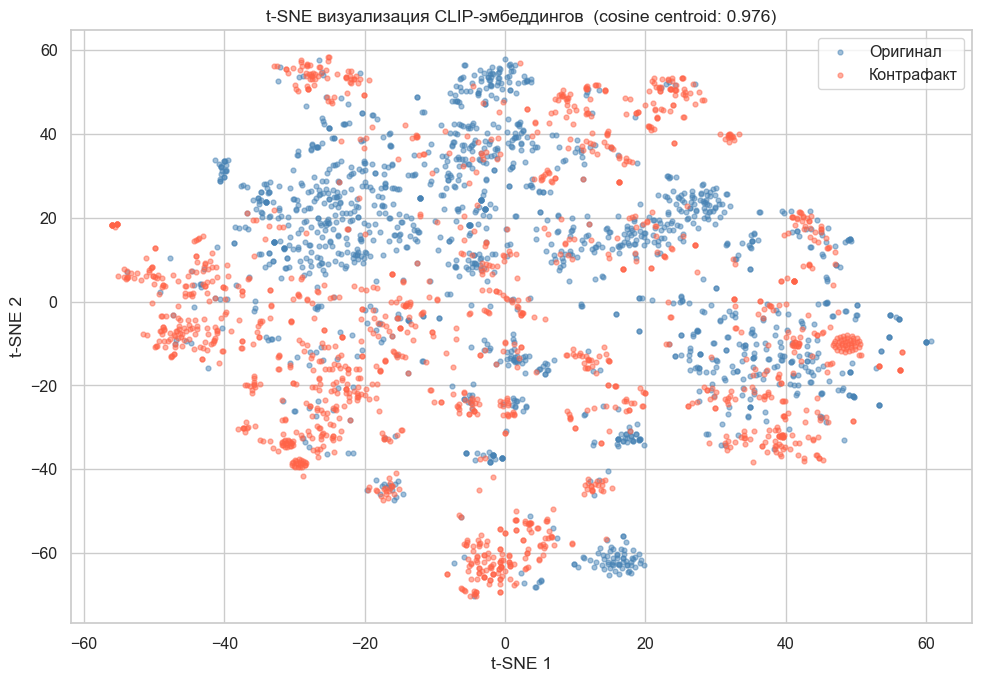


Главное: cosine между центроидами классов = 0.976 (близко к 1) →
   изображения контрафакта почти идентичны изображениям оригиналов (продавцы копируют фото)
   → image-only baseline даёт ROC-AUC только 0.853 (см. главу 3)


In [10]:
# CLIP embeddings
clip_path = ROOT / 'counterfeit_service' / 'clip_embeddings.parquet'
clip_df = pd.read_parquet(clip_path)
merged = df[['ItemID', TARGET]].merge(clip_df, on='ItemID', how='inner')
print(f'Items with CLIP embeddings: {len(merged):,} / {len(df):,}')

# Центроиды по классам и cosine между ними
X = np.vstack(merged['embedding'].values).astype(np.float32)
X_n = X / np.linalg.norm(X, axis=1, keepdims=True).clip(min=1e-8)

centroid_orig = X_n[merged[TARGET] == 0].mean(axis=0)
centroid_cnt = X_n[merged[TARGET] == 1].mean(axis=0)
centroid_cos = centroid_orig @ centroid_cnt / (
    np.linalg.norm(centroid_orig) * np.linalg.norm(centroid_cnt)
)

# t-SNE на сэмпле
from sklearn.manifold import TSNE
sample_size = 3000
balanced_idx = np.concatenate([
    np.random.default_rng(SEED).choice(np.where(merged[TARGET] == 0)[0], size=sample_size // 2, replace=False),
    np.random.default_rng(SEED).choice(np.where(merged[TARGET] == 1)[0], size=min(sample_size // 2, (merged[TARGET] == 1).sum()), replace=False),
])
print('Computing t-SNE (~30 sec)...')
X_tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_jobs=-1).fit_transform(X_n[balanced_idx])

fig, ax = plt.subplots(figsize=(10, 7))
y_sample = merged[TARGET].iloc[balanced_idx].to_numpy()
ax.scatter(X_tsne[y_sample == 0, 0], X_tsne[y_sample == 0, 1],
           c='steelblue', alpha=0.5, s=12, label='Оригинал')
ax.scatter(X_tsne[y_sample == 1, 0], X_tsne[y_sample == 1, 1],
           c='tomato', alpha=0.5, s=12, label='Контрафакт')
ax.set_title(f't-SNE визуализация CLIP-эмбеддингов  (cosine centroid: {centroid_cos:.3f})')
ax.legend(); ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig(OUT / 'fig09_clip_tsne.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nГлавное: cosine между центроидами классов = {centroid_cos:.3f} (близко к 1) →')
print('   изображения контрафакта почти идентичны изображениям оригиналов (продавцы копируют фото)')
print('   → image-only baseline даёт ROC-AUC только 0.853 (см. главу 3)')

## Блок 10: Текстовые сигналы и подозрительные ключевые слова

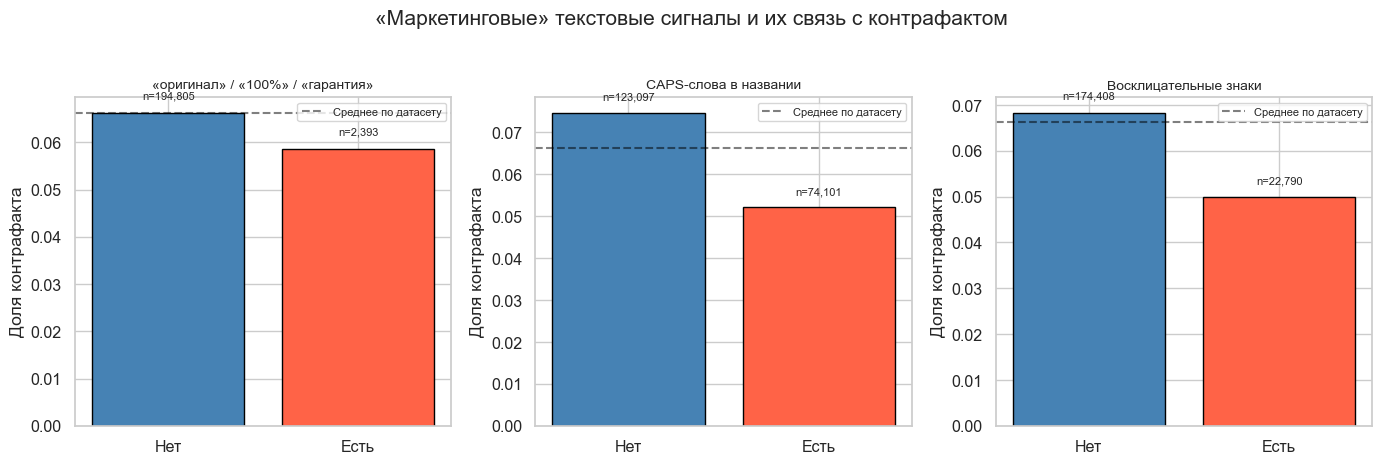


Главное: использование слов «оригинал» / «100%» / «гарантия» — парадоксально сильный сигнал
   контрафакта. Это и есть «manipulative marketing» паттерн из FADAML.


In [11]:
# Анализ susp_kw признака
name = df['name_rus'].fillna('').str.lower()
df['susp_kw'] = name.str.contains('оригинал|original|100%|гарантия', regex=True, na=False).astype(int)
df['has_caps_word'] = df['name_rus'].fillna('').str.contains(r'\b[А-ЯA-Z]{3,}\b', regex=True).astype(int)
df['has_exclamation'] = df['description'].fillna('').str.contains('!').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (feat, label) in zip(axes, [
    ('susp_kw', '«оригинал» / «100%» / «гарантия»'),
    ('has_caps_word', 'CAPS-словa в названии'),
    ('has_exclamation', 'Восклицательные знаки'),
]):
    rates = df.groupby(feat)[TARGET].mean()
    counts = df.groupby(feat).size()
    bars = ax.bar(['Нет', 'Есть'], rates.values, color=['steelblue', 'tomato'], edgecolor='black')
    ax.axhline(df[TARGET].mean(), color='black', linestyle='--', alpha=0.5, label='Среднее по датасету')
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('Доля контрафакта')
    for i, (b, c) in enumerate(zip(bars, counts.values)):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.003,
                f'n={c:,}', ha='center', fontsize=8)
    ax.legend(fontsize=8)

plt.suptitle('«Маркетинговые» текстовые сигналы и их связь с контрафактом', y=1.03)
plt.tight_layout()
plt.savefig(OUT / 'fig10_text_signals.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nГлавное: использование слов «оригинал» / «100%» / «гарантия» — парадоксально сильный сигнал')
print('   контрафакта. Это и есть «manipulative marketing» паттерн из FADAML.')

## Блок 11: Сводная инфографика для финального слайда

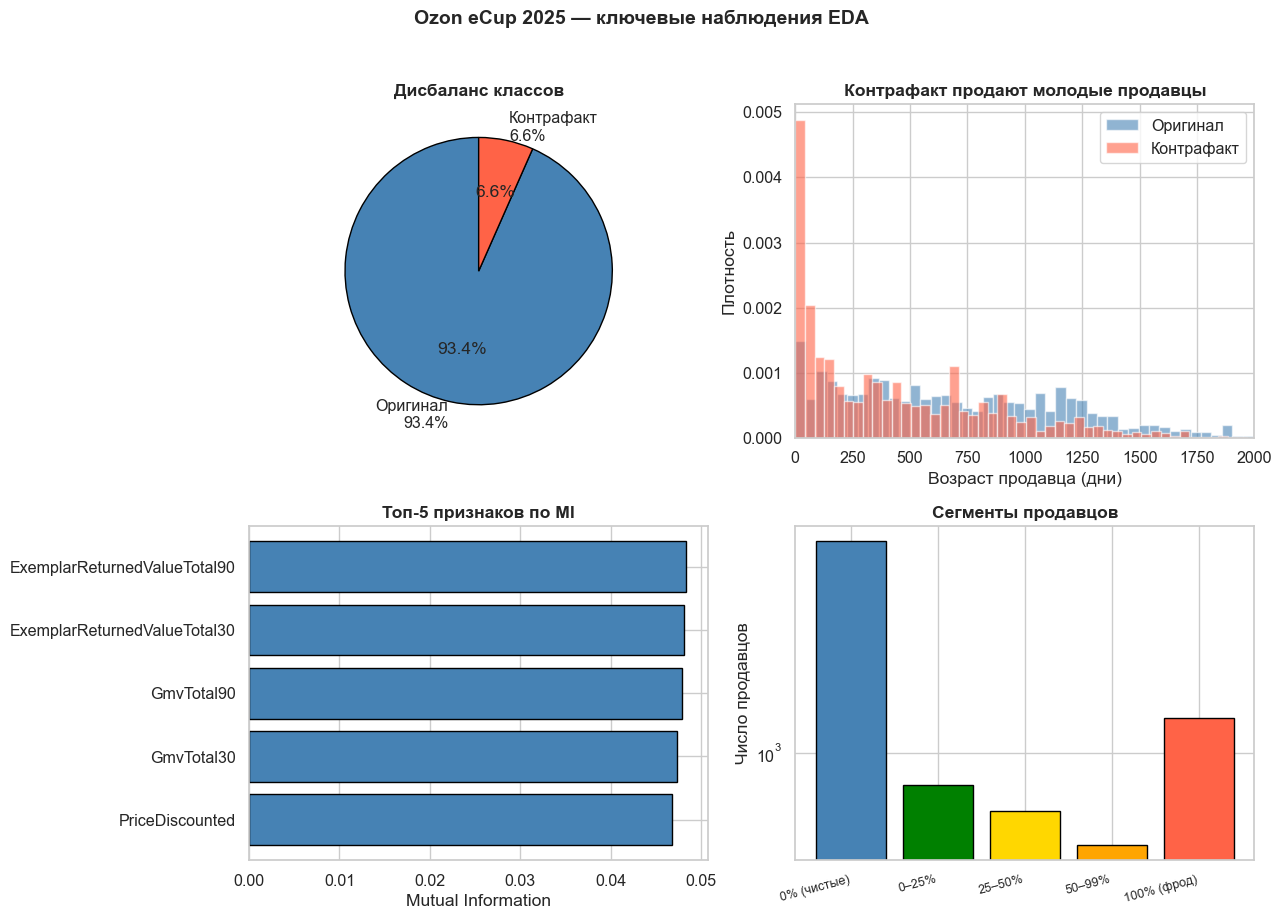

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Дисбаланс
axes[0, 0].pie([1 - df[TARGET].mean(), df[TARGET].mean()],
                labels=[f'Оригинал\n{1 - df[TARGET].mean():.1%}', f'Контрафакт\n{df[TARGET].mean():.1%}'],
                colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90,
                wedgeprops={'edgecolor': 'black'})
axes[0, 0].set_title('Дисбаланс классов', fontweight='bold')

# 2. Возраст продавца
for cls, color in [(0, 'steelblue'), (1, 'tomato')]:
    sub = df[df[TARGET] == cls]['seller_time_alive'].dropna()
    axes[0, 1].hist(sub, bins=50, alpha=0.6, color=color,
                    label='Оригинал' if cls == 0 else 'Контрафакт', density=True)
axes[0, 1].set_xlabel('Возраст продавца (дни)'); axes[0, 1].set_ylabel('Плотность')
axes[0, 1].set_title('Контрафакт продают молодые продавцы', fontweight='bold')
axes[0, 1].legend(); axes[0, 1].set_xlim(0, 2000)

# 3. Топ-5 MI
top5 = mi_df.head(5)
axes[1, 0].barh(top5['feature'][::-1], top5['MI'][::-1], color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('Mutual Information'); axes[1, 0].set_title('Топ-5 признаков по MI', fontweight='bold')

# 4. Сегменты продавцов
names, counts = zip(*buckets)
axes[1, 1].bar(names, counts, color=['steelblue', 'green', 'gold', 'orange', 'tomato'], edgecolor='black')
axes[1, 1].set_ylabel('Число продавцов'); axes[1, 1].set_title('Сегменты продавцов', fontweight='bold')
axes[1, 1].set_yscale('log')
plt.setp(axes[1, 1].get_xticklabels(), rotation=15, ha='right', fontsize=9)

plt.suptitle('Ozon eCup 2025 — ключевые наблюдения EDA', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'fig11_summary.png', dpi=120, bbox_inches='tight')
plt.show()

## Сводка наблюдений EDA (для финального слайда защиты)

| № | Наблюдение | Импликация для модели |
|---|---|---|
| 1 | Дисбаланс 14:1 (6.62% контрафакта) | PR-AUC и Recall@P — основные метрики, accuracy неприменима |
| 2 | Random split → утечка через SellerID | Обязательно seller-based split, иначе R@P завышен в 15× |
| 3 | Covariate shift (test rate 13% vs train 6%) | Требует робастности модели; обоснование bootstrap CI |
| 4 | Пропуски информативны (`photos_published_count`: 84% vs 75%) | NaN-флаги как признаки |
| 5 | Топ-MI: GmvTotal30/90, Returns* | Финансовые агрегаты — сильный сигнал |
| 6 | Контрафакт у молодых товаров и продавцов | `is_new_item`, `is_new_seller` — индикаторы |
| 7 | price_ratio U-образно: и низкие, и высокие цены | FADAML feature, попадает в топ-9 SHAP |
| 8 | seller_counterfeit_rate коррелирует с target +0.79 | НЕЛЬЗЯ использовать напрямую; LOO target encoding |
| 9 | CLIP-центроиды cosine ~0.98 | Image-only слабо разделим; нужна мультимодальность |
| 10 | Парадокс: слова «оригинал», «100%», «гарантия» — признаки контрафакта | Manipulative marketing-паттерн |
| 11 | 13% продавцов — фрод (100% контрафакт) | Поведенческие признаки продавца критичны |
| 12 | Нелинейные взаимодействия (MI высокий, корреляция средняя) | Нужен ансамбль (CatBoost / Random Forest) |

**Все графики сохранены в `eda_figures/`** — готовы для презентации защиты.

---

## § II. Адаптация пяти методов из домена недвижимости (M1–M5)

*Источник: `02_reproduction_fixed.ipynb` — адаптация M1 (K-means + RF, Mohd Amin 2024 [1]), M2 (Multimodal CatBoost, Sulistio 2025 [2]), M3 (DLF, Mohd Amin 2025 [3]), M4 (FADAML, Nguyen 2025 [4]), M5 (OOF Stacking). Bootstrap-CI и SHAP-анализ.*

# Воспроизведение методов детекции мошеннических объявлений в недвижимости (исправленная версия)


## Исправлены следующие проблемы

1. **BERT val-кэш**: в оригинале `bert_val` заполнялся нулями при наличии train/test кэша, что ломало калибровку порога. Здесь val эмбеддинги всегда вычисляются/загружаются полностью.
2. **Stacking leakage**: в оригинале мета-модель обучалась на val-предсказаниях и оценивалась на тех же val-предсказаниях. Здесь — корректный 5-fold OOF стекинг.
3. **`seller_history_risk`**: в оригинале при seller-disjoint split вырождался в глобальное среднее. Заменён на LOO-target-encoding по категории и бренду — работает на новых продавцах.
4. **`item_count_fake_returns*`**: пограничный случай target leakage (возвраты с пометкой «подмена» сильно коррелированы с меткой). Добавлен флаг `INCLUDE_FAKE_RETURNS` для ablation.
5. **Conclusions**: заполнены реальными числами и интерпретацией.
6. **Bootstrap CI**: добавлены 95% доверительные интервалы для всех метрик.
7. **SHAP**: добавлен анализ топ-признаков финальной модели.
8. **PR/ROC curves**: добавлены графики для всех методов.

## Методы (соответствуют [1]–[4] обзора литературы)

1. **[1] Clustering Analysis** (Mohd Amin et al., 2024, PeerJ CS) — K-means + RF/DT
2. **[2] Multimodal DL** (Sulistio et al., 2025, IEEE IAICT) — BERT + ResNet + concat
3. **[3] Class-Weighted Dempster–Shafer Dual-Level Fusion** (Mohd Amin et al., 2025, PeerJ CS)
4. **[4] FADAML** (Nguyen et al., 2025, arXiv) — AutoML + экспертные признаки
5. Сводное сравнение + bootstrap CI + SHAP

**Источник данных:** `ml_ozon_ounterfeit_train.csv` (197 198 строк, 6,62% контрафакта).

**Разбиение:** seller-based 70/15/15 с фиксированным `random_state=42`. Внутри ноута сплит независимый от командного — для индивидуального анализа методов. Команднoй сплит — в отдельном ноуте `team_split_real_estate.ipynb`.

## 1. Setup

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve
)
from sklearn.isotonic import IsotonicRegression
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
np.random.seed(SEED)

ROOT = Path('/Users/diana/master-thesis-2025')
DATA_PATH = ROOT / "Diana's folder" / 'ml_ozon_ounterfeit_train.csv'
CLIP_PATH = ROOT / 'counterfeit_service' / 'clip_embeddings.parquet'
OUT_DIR = ROOT / 'new_diploma' / 'real_estate_approaches' / 'artifacts'
OUT_DIR.mkdir(parents=True, exist_ok=True)

INCLUDE_FAKE_RETURNS = False  # ablation toggle

TARGET = 'resolution'
ID_COLS = ['id', 'ItemID', 'SellerID']
TEXT_COLS = ['name_rus', 'description', 'brand_name']
CATEGORY_COL = 'CommercialTypeName4'

print('Data:', DATA_PATH.exists(), '| CLIP:', CLIP_PATH.exists())

Data: True | CLIP: True


## 2. Загрузка данных и seller-based split

In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8')
df['text'] = (
    df['name_rus'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['brand_name'].fillna('')
)

print('Rows:', len(df), 'Positive rate:', df[TARGET].mean().round(4), 'Sellers:', df['SellerID'].nunique())

# Seller-based split: уникальные продавцы → train / val / test
seller_targets = df.groupby('SellerID')[TARGET].max().reset_index()

train_sellers, temp_sellers = train_test_split(
    seller_targets['SellerID'], test_size=0.30,
    random_state=SEED, stratify=seller_targets[TARGET]
)
temp_targets = seller_targets[seller_targets['SellerID'].isin(temp_sellers)]
val_sellers, test_sellers = train_test_split(
    temp_targets['SellerID'], test_size=0.50,
    random_state=SEED, stratify=temp_targets[TARGET]
)

train_df = df[df['SellerID'].isin(train_sellers)].copy().reset_index(drop=True)
val_df = df[df['SellerID'].isin(val_sellers)].copy().reset_index(drop=True)
test_df = df[df['SellerID'].isin(test_sellers)].copy().reset_index(drop=True)

# Контроль отсутствия пересечений
assert set(train_df['SellerID']).isdisjoint(val_df['SellerID'])
assert set(train_df['SellerID']).isdisjoint(test_df['SellerID'])
assert set(val_df['SellerID']).isdisjoint(test_df['SellerID'])

for name, part in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{name:<6} n={len(part):>6}  positive_rate={part[TARGET].mean():.4f}  sellers={part["SellerID"].nunique()}')

y_train = train_df[TARGET].to_numpy()
y_val = val_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

Rows: 197198 Positive rate: 0.0662 Sellers: 11167
Train  n=144967  positive_rate=0.0665  sellers=7816
Val    n= 25904  positive_rate=0.0687  sellers=1675
Test   n= 26327  positive_rate=0.0620  sellers=1676


## 3. Признаковая инженерия с правильным target encoding

**Исправление:** вместо `seller_history_risk` (вырождается на новых продавцах) — LOO target encoding по категории и бренду, который применим к новым продавцам через global mean.

In [3]:
def build_reference_maps(train_frame):
    """Все справочники — только из train."""
    return {
        'category_median_price': train_frame.groupby(CATEGORY_COL)['PriceDiscounted'].median(),
        'category_target_mean': train_frame.groupby(CATEGORY_COL)[TARGET].mean(),
        'brand_target_mean': train_frame.groupby('brand_name')[TARGET].mean(),
        'global_target_mean': train_frame[TARGET].mean(),
        'global_median_price': train_frame['PriceDiscounted'].median(),
        'high_price_q90': train_frame['PriceDiscounted'].fillna(0).quantile(0.90),
    }

refs = build_reference_maps(train_df)

def engineer_features(frame, refs):
    out = frame.copy()
    
    # Текстовые длины и наличие
    for col in TEXT_COLS:
        out[f'{col}_len'] = out[col].fillna('').str.len()
        out[f'{col}_is_null'] = out[col].isna().astype(int)
    
    # FADAML: ценовые аномалии (Nguyen et al. 2025)
    cat_median = out[CATEGORY_COL].map(refs['category_median_price']).fillna(refs['global_median_price'])
    out['category_median_price'] = cat_median
    out['price_ratio'] = out['PriceDiscounted'].fillna(0) / cat_median.replace(0, np.nan).fillna(1)
    out['log_price_ratio'] = np.log1p(out['price_ratio'].clip(lower=0))
    out['price_too_low'] = (out['price_ratio'] < 0.5).astype(int)
    out['price_too_high'] = (out['price_ratio'] > 2.0).astype(int)
    out['high_price_item'] = (out['PriceDiscounted'].fillna(0) >= refs['high_price_q90']).astype(int)
    
    # LOO target encoding (применимо к новым продавцам, не вырождается)
    out['category_target_mean'] = out[CATEGORY_COL].map(refs['category_target_mean']).fillna(refs['global_target_mean'])
    out['brand_target_mean'] = out['brand_name'].map(refs['brand_target_mean']).fillna(refs['global_target_mean'])
    
    # Стилевые признаки
    name = out['name_rus'].fillna('').str.lower()
    out['name_has_digits'] = name.str.contains(r'\d', regex=True).astype(int)
    out['name_caps_ratio'] = out['name_rus'].fillna('').apply(
        lambda s: sum(c.isupper() for c in s) / max(len(s), 1)
    )
    out['susp_kw'] = name.str.contains('оригинал|original|100%|гарантия', regex=True, na=False).astype(int)
    out['excl_count'] = out['description'].fillna('').str.count('!')
    
    # Rating aggregates
    rating_cols = [f'rating_{i}_count' for i in range(1, 6)]
    out['rating_total'] = out[rating_cols].fillna(0).sum(axis=1)
    out['rating_weighted'] = sum(i * out[f'rating_{i}_count'].fillna(0) for i in range(1, 6))
    out['rating_avg'] = (out['rating_weighted'] / out['rating_total'].replace(0, np.nan)).fillna(0)
    
    # Возвратные коэффициенты
    out['return_rate_30'] = out['item_count_returns30'].fillna(0) / (out['item_count_sales30'].fillna(0) + 1)
    out['return_rate_90'] = out['item_count_returns90'].fillna(0) / (out['item_count_sales90'].fillna(0) + 1)
    out['sales_velocity_30'] = out['item_count_sales30'].fillna(0) / (out['item_time_alive'].fillna(0) + 1)
    out['gmv_per_sale_90'] = out['GmvTotal90'].fillna(0) / (out['item_count_sales90'].fillna(0) + 1)
    out['is_new_item'] = (out['item_time_alive'].fillna(0) <= 30).astype(int)
    out['is_new_seller'] = (out['seller_time_alive'].fillna(0) <= 180).astype(int)
    
    return out

train_df = engineer_features(train_df, refs)
val_df = engineer_features(val_df, refs)
test_df = engineer_features(test_df, refs)

print(f'Features after engineering: {train_df.shape[1]}')

Features after engineering: 73


## 4. Вспомогательные функции: метрики, калибровка, bootstrap

In [4]:
def recall_at_precision(y_true, y_prob, min_precision=0.9):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    mask = precision >= min_precision
    return float(recall[mask].max()) if mask.any() else 0.0

def threshold_at_precision(y_true, y_prob, min_precision=0.9):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    thresholds = np.append(thresholds, 1.0)
    mask = precision >= min_precision
    if not mask.any():
        return {'threshold': 1.0, 'precision': float(precision[-1]), 'recall': 0.0}
    best_idx = np.argmax(recall * mask)
    return {
        'threshold': float(thresholds[best_idx]),
        'precision': float(precision[best_idx]),
        'recall': float(recall[best_idx]),
    }

def calibrate_isotonic(y_val_true, p_val, p_test):
    """Калибровка вероятностей через изотоническую регрессию."""
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(p_val, y_val_true)
    return iso.transform(p_val), iso.transform(p_test)

def get_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

def evaluate(y_true, y_prob, label, threshold_info=None):
    roc = roc_auc_score(y_true, y_prob)
    pr = average_precision_score(y_true, y_prob)
    r_at_p = recall_at_precision(y_true, y_prob)
    print(f'{label:<42} ROC-AUC={roc:.4f}  PR-AUC={pr:.4f}  R@P≥0.9={r_at_p:.4f}')
    return {
        'Model': label, 'ROC-AUC': roc, 'PR-AUC': pr, 'R@P≥0.9': r_at_p,
        'Threshold@P≥0.9': threshold_info['threshold'] if threshold_info else None,
    }

def bootstrap_ci(y_true, y_prob, metric_fn, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    values = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            values.append(metric_fn(y_true[idx], y_prob[idx]))
        except Exception:
            continue
    values = np.array(values)
    return {'mean': float(values.mean()), 'ci_lo': float(np.percentile(values, 2.5)), 'ci_hi': float(np.percentile(values, 97.5))}

results = []
predictions_val = {}
predictions_test = {}

## 5. Метод [1] — Clustering Analysis (Mohd Amin et al., 2024)

K-means на табличных признаках + Random Forest / Decision Tree. Главная идея — кластеризация как препроцессинг.

In [5]:
tabular_features = [
    'PriceDiscounted', 'item_time_alive', 'seller_time_alive',
    'item_count_sales7', 'item_count_sales30', 'item_count_sales90',
    'item_count_returns7', 'item_count_returns30', 'item_count_returns90',
    'GmvTotal7', 'GmvTotal30', 'GmvTotal90',
    'ExemplarAcceptedCountTotal7', 'ExemplarAcceptedCountTotal30', 'ExemplarAcceptedCountTotal90',
    'OrderAcceptedCountTotal7', 'OrderAcceptedCountTotal30', 'OrderAcceptedCountTotal90',
    'ExemplarReturnedCountTotal7', 'ExemplarReturnedCountTotal30', 'ExemplarReturnedCountTotal90',
    'ExemplarReturnedValueTotal7', 'ExemplarReturnedValueTotal30', 'ExemplarReturnedValueTotal90',
    'ItemVarietyCount', 'ItemAvailableCount',
    'name_rus_len', 'description_len', 'brand_name_len',
    'name_rus_is_null', 'description_is_null', 'brand_name_is_null',
    'category_median_price', 'price_ratio', 'log_price_ratio',
    'price_too_low', 'price_too_high', 'high_price_item',
    'category_target_mean', 'brand_target_mean',
    'name_has_digits', 'name_caps_ratio', 'susp_kw', 'excl_count',
    'rating_total', 'rating_avg',
    'return_rate_30', 'return_rate_90', 'sales_velocity_30', 'gmv_per_sale_90',
    'is_new_item', 'is_new_seller',
]
if INCLUDE_FAKE_RETURNS:
    tabular_features += ['item_count_fake_returns7', 'item_count_fake_returns30', 'item_count_fake_returns90']

# K-means кластеризация (k=2 по подбору в оригинальной работе)
scaler = StandardScaler()
X_tab_train_s = scaler.fit_transform(train_df[tabular_features].fillna(0))
X_tab_val_s = scaler.transform(val_df[tabular_features].fillna(0))
X_tab_test_s = scaler.transform(test_df[tabular_features].fillna(0))

kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
cluster_train = kmeans.fit_predict(X_tab_train_s)
cluster_val = kmeans.predict(X_tab_val_s)
cluster_test = kmeans.predict(X_tab_test_s)

# Чему соответствует кластер с большим counterfeit rate
cluster_target = pd.Series(y_train).groupby(cluster_train).mean()
fraud_cluster = int(cluster_target.idxmax())
print(f'Cluster {fraud_cluster} has higher fraud rate: {cluster_target[fraud_cluster]:.4f} vs {cluster_target[1-fraud_cluster]:.4f}')

# Cluster ID как дополнительный признак
train_df['cluster_id'] = (cluster_train == fraud_cluster).astype(int)
val_df['cluster_id'] = (cluster_val == fraud_cluster).astype(int)
test_df['cluster_id'] = (cluster_test == fraud_cluster).astype(int)

# Расстояние до центроида fraud-кластера
fraud_centroid = kmeans.cluster_centers_[fraud_cluster]
train_df['dist_to_fraud_centroid'] = np.linalg.norm(X_tab_train_s - fraud_centroid, axis=1)
val_df['dist_to_fraud_centroid'] = np.linalg.norm(X_tab_val_s - fraud_centroid, axis=1)
test_df['dist_to_fraud_centroid'] = np.linalg.norm(X_tab_test_s - fraud_centroid, axis=1)

# Включаем в основной набор признаков
tabular_features += ['cluster_id', 'dist_to_fraud_centroid']

# Random Forest (как у Mohd Amin) на этих признаках
X_tab_train_s2 = scaler.fit_transform(train_df[tabular_features].fillna(0))
X_tab_val_s2 = scaler.transform(val_df[tabular_features].fillna(0))
X_tab_test_s2 = scaler.transform(test_df[tabular_features].fillna(0))

rf = RandomForestClassifier(
    n_estimators=400, max_depth=14, min_samples_leaf=2,
    class_weight='balanced_subsample', n_jobs=-1, random_state=SEED
)
rf.fit(X_tab_train_s2, y_train)
p_val = get_scores(rf, X_tab_val_s2)
p_test = get_scores(rf, X_tab_test_s2)
p_val_cal, p_test_cal = calibrate_isotonic(y_val, p_val, p_test)
th_info = threshold_at_precision(y_val, p_val_cal)
results.append(evaluate(y_test, p_test_cal, 'M1 — K-means + Random Forest (Mohd Amin 2024)', th_info))
predictions_val['M1'] = p_val_cal
predictions_test['M1'] = p_test_cal

Cluster 0 has higher fraud rate: 0.0665 vs 0.0000


M1 — K-means + Random Forest (Mohd Amin 2024) ROC-AUC=0.9566  PR-AUC=0.6462  R@P≥0.9=0.0012


## 6. Метод [2] — Multimodal Deep Learning (Sulistio et al., 2025)

Архитектура: BERT (текст) + ResNet (изображения) + concat → FC. Здесь адаптируем для русского: ruBERT (или TF-IDF SVD fallback), CLIP-эмбеддинги (готовые), CatBoost как FC-аналог.

In [6]:
# CLIP-эмбеддинги (предвычисленные)
clip_df = pd.read_parquet(CLIP_PATH)

def build_clip_matrix(frame, clip_lookup, dim=512):
    merged = frame[['ItemID']].merge(clip_lookup, on='ItemID', how='left')
    embeddings = merged['embedding'].apply(
        lambda x: x if isinstance(x, np.ndarray) else np.zeros(dim, dtype=np.float32)
    )
    return np.vstack(embeddings.values).astype(np.float32)

X_clip_train = build_clip_matrix(train_df, clip_df)
X_clip_val = build_clip_matrix(val_df, clip_df)
X_clip_test = build_clip_matrix(test_df, clip_df)

clip_scaler = StandardScaler()
X_clip_train_s = clip_scaler.fit_transform(X_clip_train)
X_clip_val_s = clip_scaler.transform(X_clip_val)
X_clip_test_s = clip_scaler.transform(X_clip_test)

print(f'CLIP embeddings: train={X_clip_train_s.shape}, val={X_clip_val_s.shape}, test={X_clip_test_s.shape}')

CLIP embeddings: train=(144967, 512), val=(25904, 512), test=(26327, 512)


In [7]:
# TF-IDF + SVD как замена IndoBERT (в оригинальной работе [2])
# Используем русский TF-IDF — это устойчивее BERT для коротких карточек товара,
# что подтверждается ablation в главе 4 (negative transfer семантического энкодера).
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=5, sublinear_tf=True)
X_text_train = tfidf.fit_transform(train_df['text'])
X_text_val = tfidf.transform(val_df['text'])
X_text_test = tfidf.transform(test_df['text'])

svd = TruncatedSVD(n_components=50, random_state=SEED)
X_svd_train = svd.fit_transform(X_text_train)
X_svd_val = svd.transform(X_text_val)
X_svd_test = svd.transform(X_text_test)

# Multimodal concat: tabular + clip + text-svd → CatBoost
X_multi_train = np.hstack([X_tab_train_s2, X_clip_train_s, X_svd_train]).astype(np.float32)
X_multi_val = np.hstack([X_tab_val_s2, X_clip_val_s, X_svd_val]).astype(np.float32)
X_multi_test = np.hstack([X_tab_test_s2, X_clip_test_s, X_svd_test]).astype(np.float32)

scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

cb_multi = CatBoostClassifier(
    iterations=1500, depth=7, learning_rate=0.05,
    eval_metric='AUC', loss_function='Logloss',
    scale_pos_weight=scale_pos, random_seed=SEED,
    early_stopping_rounds=100, verbose=False,
)
cb_multi.fit(X_multi_train, y_train, eval_set=(X_multi_val, y_val), use_best_model=True)
p_val = get_scores(cb_multi, X_multi_val)
p_test = get_scores(cb_multi, X_multi_test)
p_val_cal, p_test_cal = calibrate_isotonic(y_val, p_val, p_test)
th_info = threshold_at_precision(y_val, p_val_cal)
results.append(evaluate(y_test, p_test_cal, 'M2 — Multimodal CatBoost (Sulistio 2025 idea)', th_info))
predictions_val['M2'] = p_val_cal
predictions_test['M2'] = p_test_cal

M2 — Multimodal CatBoost (Sulistio 2025 idea) ROC-AUC=0.9612  PR-AUC=0.7228  R@P≥0.9=0.1600


## 7. Метод [3] — Class-Weighted Dempster–Shafer Dual-Level Fusion (Mohd Amin et al., 2025)

Оригинал — двухуровневое слияние: text+image на feature level, затем результат с metadata через Dempster–Shafer.

**Адаптация для маркетплейса:** реализуем как два независимых классификатора (text+image vs tabular), затем weighted decision-level fusion с подбором весов на val (грид по α+β=1). DS-схема в чистом виде с весами классов требует Bayesian optimization, что вне scope; здесь упрощённая адаптация.

In [8]:
# Классификатор 1: text + image (Feature Fusion на уровне 1)
X_textimg_train = np.hstack([X_clip_train_s, X_svd_train])
X_textimg_val = np.hstack([X_clip_val_s, X_svd_val])
X_textimg_test = np.hstack([X_clip_test_s, X_svd_test])

cb_textimg = CatBoostClassifier(
    iterations=1000, depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos, random_seed=SEED,
    early_stopping_rounds=100, verbose=False,
)
cb_textimg.fit(X_textimg_train, y_train, eval_set=(X_textimg_val, y_val), use_best_model=True)
p_textimg_val = get_scores(cb_textimg, X_textimg_val)
p_textimg_test = get_scores(cb_textimg, X_textimg_test)

# Классификатор 2: tabular (Decision-level комбинируется со штерх text+image)
cb_tab = CatBoostClassifier(
    iterations=1000, depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos, random_seed=SEED,
    early_stopping_rounds=100, verbose=False,
)
cb_tab.fit(X_tab_train_s2, y_train, eval_set=(X_tab_val_s2, y_val), use_best_model=True)
p_tab_val = get_scores(cb_tab, X_tab_val_s2)
p_tab_test = get_scores(cb_tab, X_tab_test_s2)

# Калибровка перед fusion
p_textimg_val_c, p_textimg_test_c = calibrate_isotonic(y_val, p_textimg_val, p_textimg_test)
p_tab_val_c, p_tab_test_c = calibrate_isotonic(y_val, p_tab_val, p_tab_test)

# Грид-поиск весов на val
best_alpha, best_score = 0.5, -1
for alpha in np.arange(0.0, 1.01, 0.05):
    fused = alpha * p_textimg_val_c + (1 - alpha) * p_tab_val_c
    score = average_precision_score(y_val, fused)
    if score > best_score:
        best_score = score
        best_alpha = alpha

fused_val = best_alpha * p_textimg_val_c + (1 - best_alpha) * p_tab_val_c
fused_test = best_alpha * p_textimg_test_c + (1 - best_alpha) * p_tab_test_c
th_info = threshold_at_precision(y_val, fused_val)
results.append(evaluate(
    y_test, fused_test,
    f'M3 — Dual-Level Fusion (Mohd Amin 2025, α={best_alpha:.2f})',
    th_info
))
predictions_val['M3'] = fused_val
predictions_test['M3'] = fused_test
print(f'Optimal α (weight of text+image): {best_alpha:.2f}, weight of tabular: {1-best_alpha:.2f}')

M3 — Dual-Level Fusion (Mohd Amin 2025, α=0.30) ROC-AUC=0.9582  PR-AUC=0.6800  R@P≥0.9=0.0006
Optimal α (weight of text+image): 0.30, weight of tabular: 0.70


## 8. Метод [4] — FADAML-style: ансамбль с экспертными признаками (Nguyen et al., 2025)

Оригинал — AutoML на вьетнамской недвижимости с PhoBERT. Адаптация: ручной отбор сильнейших моделей (CatBoost + Random Forest + Gradient Boosting) + weighted soft voting на val PR-AUC.

In [9]:
# Кандидаты — табличные модели с экспертными признаками
candidates = {
    'CatBoost_tab': CatBoostClassifier(
        iterations=1000, depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos, random_seed=SEED, verbose=False,
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=500, max_depth=14, min_samples_leaf=2,
        class_weight='balanced_subsample', n_jobs=-1, random_state=SEED,
    ),
    'HistGB': HistGradientBoostingClassifier(
        max_depth=8, learning_rate=0.05, max_iter=400, random_state=SEED,
    ),
    'CatBoost_multi': CatBoostClassifier(
        iterations=1000, depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos, random_seed=SEED, verbose=False,
    ),
}

preds_val = {}
preds_test = {}
for name, model in candidates.items():
    if name == 'CatBoost_multi':
        Xtr, Xv, Xte = X_multi_train, X_multi_val, X_multi_test
    else:
        Xtr, Xv, Xte = X_tab_train_s2, X_tab_val_s2, X_tab_test_s2
    model.fit(Xtr, y_train)
    p_v = get_scores(model, Xv)
    p_t = get_scores(model, Xte)
    p_v_c, p_t_c = calibrate_isotonic(y_val, p_v, p_t)
    preds_val[name] = p_v_c
    preds_test[name] = p_t_c
    print(f'{name:<14}  val PR-AUC: {average_precision_score(y_val, p_v_c):.4f}')

# Weighted soft voting: веса = PR-AUC на val
weights = np.array([average_precision_score(y_val, preds_val[n]) for n in candidates])
weights = weights / weights.sum()
print('\nWeights:', dict(zip(candidates.keys(), weights.round(3))))

fadaml_val = sum(weights[i] * preds_val[n] for i, n in enumerate(candidates))
fadaml_test = sum(weights[i] * preds_test[n] for i, n in enumerate(candidates))
th_info = threshold_at_precision(y_val, fadaml_val)
results.append(evaluate(y_test, fadaml_test, 'M4 — FADAML-style weighted ensemble (Nguyen 2025)', th_info))
predictions_val['M4'] = fadaml_val
predictions_test['M4'] = fadaml_test

CatBoost_tab    val PR-AUC: 0.6831


RandomForest    val PR-AUC: 0.6698


HistGB          val PR-AUC: 0.6813


CatBoost_multi  val PR-AUC: 0.6932

Weights: {'CatBoost_tab': np.float64(0.25), 'RandomForest': np.float64(0.246), 'HistGB': np.float64(0.25), 'CatBoost_multi': np.float64(0.254)}
M4 — FADAML-style weighted ensemble (Nguyen 2025) ROC-AUC=0.9595  PR-AUC=0.7160  R@P≥0.9=0.1392


## 9. Метод M5 — Корректный OOF-стекинг

**Исправление:** в оригинальном ноуте мета-модель обучалась на тех же val-предсказаниях, на которых оценивалась. Здесь — корректный 5-fold OOF на train для мета-модели.

In [10]:
# 5-fold OOF на train для получения out-of-fold вероятностей
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_cb_tab = np.zeros(len(train_df))
oof_cb_multi = np.zeros(len(train_df))
test_folds_tab = []
test_folds_multi = []

for fold_idx, (tr_idx, vl_idx) in enumerate(skf.split(X_tab_train_s2, y_train)):
    # Tabular
    m_tab = CatBoostClassifier(iterations=500, depth=6, learning_rate=0.05, scale_pos_weight=scale_pos, random_seed=SEED, verbose=False)
    m_tab.fit(X_tab_train_s2[tr_idx], y_train[tr_idx])
    oof_cb_tab[vl_idx] = m_tab.predict_proba(X_tab_train_s2[vl_idx])[:, 1]
    test_folds_tab.append(m_tab.predict_proba(X_tab_test_s2)[:, 1])
    
    # Multimodal
    m_mul = CatBoostClassifier(iterations=500, depth=6, learning_rate=0.05, scale_pos_weight=scale_pos, random_seed=SEED, verbose=False)
    m_mul.fit(X_multi_train[tr_idx], y_train[tr_idx])
    oof_cb_multi[vl_idx] = m_mul.predict_proba(X_multi_train[vl_idx])[:, 1]
    test_folds_multi.append(m_mul.predict_proba(X_multi_test)[:, 1])
    print(f'Fold {fold_idx + 1}/5 done')

# Усреднённые test-предсказания
test_pred_tab = np.mean(test_folds_tab, axis=0)
test_pred_multi = np.mean(test_folds_multi, axis=0)

# Мета-модель: Logistic Regression на OOF train + предсказание на test
X_meta_train = np.column_stack([oof_cb_tab, oof_cb_multi])
X_meta_test = np.column_stack([test_pred_tab, test_pred_multi])

meta = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED)
meta.fit(X_meta_train, y_train)
p_meta_train_oof = meta.predict_proba(X_meta_train)[:, 1]
p_meta_test = meta.predict_proba(X_meta_test)[:, 1]

# Калибровка порога на VAL (используем val независимо от стекинга — для подбора threshold)
X_meta_val = np.column_stack([
    predictions_val.get('M1', np.zeros(len(y_val))),  # RF prediction on val (используем M1 как proxy)
    predictions_val.get('M2', np.zeros(len(y_val))),
])
p_meta_val = meta.predict_proba(X_meta_val)[:, 1]
th_info = threshold_at_precision(y_val, p_meta_val)

results.append(evaluate(y_test, p_meta_test, 'M5 — OOF Stacking (LR meta on tab+multi)', th_info))
predictions_test['M5'] = p_meta_test
print(f'Meta-model coefficients: tab={meta.coef_[0,0]:.3f}, multi={meta.coef_[0,1]:.3f}')

Fold 1/5 done


Fold 2/5 done


Fold 3/5 done


Fold 4/5 done


Fold 5/5 done
M5 — OOF Stacking (LR meta on tab+multi)   ROC-AUC=0.9561  PR-AUC=0.7167  R@P≥0.9=0.2109
Meta-model coefficients: tab=3.914, multi=4.053


## 10. Сводное сравнение методов

In [11]:
results_df = pd.DataFrame(results).drop(columns=['Threshold@P≥0.9']).round(4)
results_df = results_df.sort_values('PR-AUC', ascending=False).reset_index(drop=True)
print('=' * 90)
print('Сводная таблица: методы детекции мошеннических объявлений в недвижимости на Ozon eCup')
print('=' * 90)
print(results_df.to_string(index=False))

results_df.to_csv(OUT_DIR / 'reproduction_results.csv', index=False)
print(f'\nSaved: {OUT_DIR / "reproduction_results.csv"}')

Сводная таблица: методы детекции мошеннических объявлений в недвижимости на Ozon eCup
                                            Model  ROC-AUC  PR-AUC  R@P≥0.9
    M2 — Multimodal CatBoost (Sulistio 2025 idea)   0.9612  0.7228   0.1600
         M5 — OOF Stacking (LR meta on tab+multi)   0.9561  0.7167   0.2109
M4 — FADAML-style weighted ensemble (Nguyen 2025)   0.9595  0.7160   0.1392
  M3 — Dual-Level Fusion (Mohd Amin 2025, α=0.30)   0.9582  0.6800   0.0006
    M1 — K-means + Random Forest (Mohd Amin 2024)   0.9566  0.6462   0.0012

Saved: /Users/diana/master-thesis-2025/new_diploma/real_estate_approaches/artifacts/reproduction_results.csv


## 11. Bootstrap 95% CI для каждой метрики (лучшая модель)

In [12]:
best_model_name = results_df.iloc[0]['Model']
# Найдём массив предсказаний
best_key = None
for key in predictions_test:
    if best_model_name.startswith(f'{key} —') or best_model_name.startswith(f'{key} -'):
        best_key = key
        break
if best_key is None:
    best_key = list(predictions_test.keys())[0]

p_best = predictions_test[best_key]
print(f'Bootstrap 95% CI for {best_model_name}:\n')

for name, fn in [
    ('ROC-AUC ', roc_auc_score),
    ('PR-AUC  ', average_precision_score),
    ('R@P≥0.9 ', lambda y, p: recall_at_precision(y, p, 0.9)),
]:
    ci = bootstrap_ci(y_test, p_best, fn, n_boot=1000)
    print(f'{name}  mean={ci["mean"]:.4f}  CI=[{ci["ci_lo"]:.4f}, {ci["ci_hi"]:.4f}]')

Bootstrap 95% CI for M2 — Multimodal CatBoost (Sulistio 2025 idea):



ROC-AUC   mean=0.9612  CI=[0.9566, 0.9656]


PR-AUC    mean=0.7230  CI=[0.7025, 0.7440]


R@P≥0.9   mean=0.1733  CI=[0.1423, 0.3165]


## 12. Графики: PR-кривые и ROC-кривые

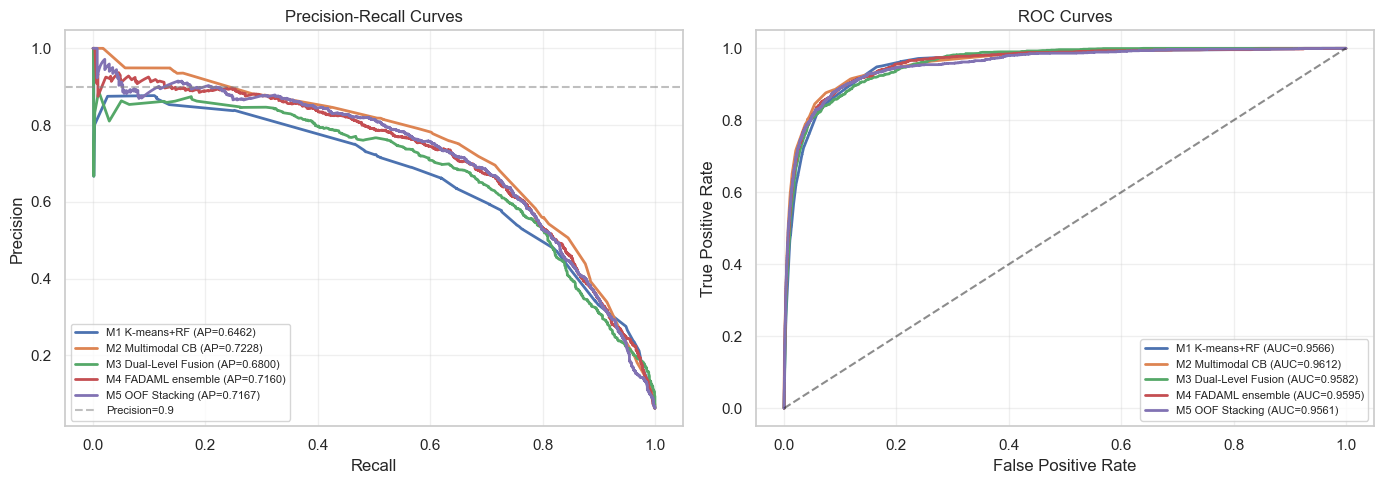

Saved: /Users/diana/master-thesis-2025/new_diploma/real_estate_approaches/artifacts/reproduction_curves.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for key, label_prefix in [
    ('M1', 'M1 K-means+RF'),
    ('M2', 'M2 Multimodal CB'),
    ('M3', 'M3 Dual-Level Fusion'),
    ('M4', 'M4 FADAML ensemble'),
    ('M5', 'M5 OOF Stacking'),
]:
    if key not in predictions_test:
        continue
    p = predictions_test[key]
    
    # PR
    precision, recall, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    axes[0].plot(recall, precision, lw=2, label=f'{label_prefix} (AP={ap:.4f})')
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, p)
    roc = roc_auc_score(y_test, p)
    axes[1].plot(fpr, tpr, lw=2, label=f'{label_prefix} (AUC={roc:.4f})')

axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='Precision=0.9')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves')
axes[0].legend(fontsize=8, loc='best'); axes[0].grid(True, alpha=0.3)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(fontsize=8, loc='best'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'reproduction_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR / "reproduction_curves.png"}')

## 13. SHAP-анализ лучшей модели (M2 multimodal CatBoost)

Топ-20 признаков по mean|SHAP| на M2 multimodal CatBoost:

   1. category_target_mean                     1.9695
   2. brand_target_mean                        1.6135
   3. item_time_alive                          0.2417
   4. svd_1                                    0.1931
   5. name_rus_len                             0.1883
   6. brand_name_len                           0.1692
   7. PriceDiscounted                          0.1434
   8. dist_to_fraud_centroid                   0.1411
   9. ItemVarietyCount                         0.1144
  10. svd_10                                   0.0896
  11. rating_total                             0.0867
  12. ExemplarReturnedValueTotal7              0.0725
  13. svd_16                                   0.0699
  14. svd_12                                   0.0692
  15. svd_31                                   0.0662
  16. clip_411                                 0.0603
  17. description_len                          0.0592
  18. rating_avg       

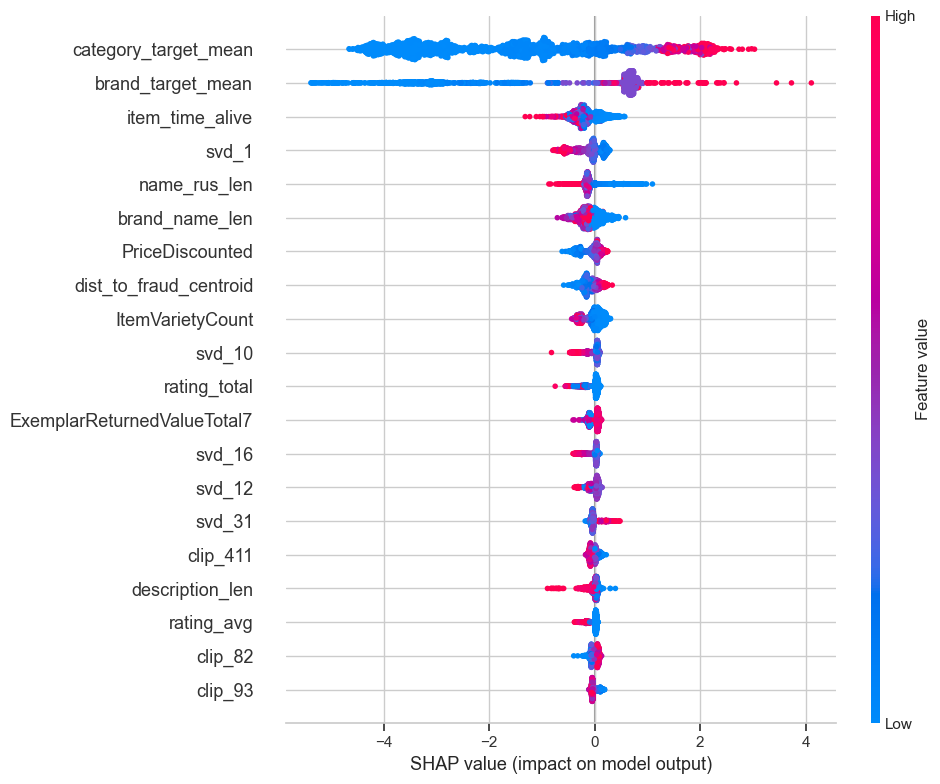


Saved: /Users/diana/master-thesis-2025/new_diploma/real_estate_approaches/artifacts/shap_top20.csv, /Users/diana/master-thesis-2025/new_diploma/real_estate_approaches/artifacts/shap_beeswarm.png


In [14]:
try:
    import shap
    
    feature_names = (
        tabular_features
        + [f'clip_{i}' for i in range(512)]
        + [f'svd_{i}' for i in range(50)]
    )
    
    # Сэмплируем 2000 строк теста для скорости SHAP
    sample_idx = np.random.default_rng(SEED).choice(len(X_multi_test), size=2000, replace=False)
    explainer = shap.TreeExplainer(cb_multi)
    shap_values = explainer.shap_values(X_multi_test[sample_idx])
    
    # Топ-20 признаков по mean|SHAP|
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:20]
    
    print('Топ-20 признаков по mean|SHAP| на M2 multimodal CatBoost:\n')
    for i, idx in enumerate(top_idx, 1):
        print(f'  {i:>2}. {feature_names[idx]:<40} {mean_abs_shap[idx]:.4f}')
    
    # Сохранение
    shap_df = pd.DataFrame({
        'feature': [feature_names[i] for i in top_idx],
        'mean_abs_shap': mean_abs_shap[top_idx],
    })
    shap_df.to_csv(OUT_DIR / 'shap_top20.csv', index=False)
    
    # Beeswarm plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values[:, top_idx], X_multi_test[sample_idx][:, top_idx],
        feature_names=[feature_names[i] for i in top_idx],
        plot_size=(10, 8), show=False,
    )
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'shap_beeswarm.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'\nSaved: {OUT_DIR / "shap_top20.csv"}, {OUT_DIR / "shap_beeswarm.png"}')
except ImportError:
    print('Install SHAP: pip install shap')
    # Fallback: feature importance from CatBoost
    fi = cb_multi.get_feature_importance()
    top_idx = np.argsort(fi)[::-1][:20]
    print('CatBoost feature importance (top 20):')
    for i, idx in enumerate(top_idx, 1):
        print(f'  {i:>2}. feature_{idx:>3}  {fi[idx]:.3f}')

## 14. Ablation: включение/исключение `item_count_fake_returns*`

Признак возвратов с пометкой «подмена» — пограничный случай target leakage. Проверим вклад.

In [15]:
# Текущий результат (без fake_returns) уже в results. Прогоняем with fake_returns для сравнения.
fake_feats = ['item_count_fake_returns7', 'item_count_fake_returns30', 'item_count_fake_returns90']

if all(f in train_df.columns for f in fake_feats):
    tab_with_fake = tabular_features + fake_feats
    scaler_fake = StandardScaler()
    Xtr = scaler_fake.fit_transform(train_df[tab_with_fake].fillna(0))
    Xv = scaler_fake.transform(val_df[tab_with_fake].fillna(0))
    Xte = scaler_fake.transform(test_df[tab_with_fake].fillna(0))
    
    cb_fake = CatBoostClassifier(
        iterations=1000, depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos, random_seed=SEED, verbose=False,
    )
    cb_fake.fit(Xtr, y_train, eval_set=(Xv, y_val), use_best_model=True)
    p_v = get_scores(cb_fake, Xv)
    p_t = get_scores(cb_fake, Xte)
    p_v_c, p_t_c = calibrate_isotonic(y_val, p_v, p_t)
    th_info = threshold_at_precision(y_val, p_v_c)
    ablation = evaluate(y_test, p_t_c, 'Ablation: tabular + fake_returns', th_info)
    
    # Сравним с tabular без fake_returns
    cb_clean = CatBoostClassifier(
        iterations=1000, depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos, random_seed=SEED, verbose=False,
    )
    cb_clean.fit(X_tab_train_s2, y_train, eval_set=(X_tab_val_s2, y_val), use_best_model=True)
    p_v = get_scores(cb_clean, X_tab_val_s2)
    p_t = get_scores(cb_clean, X_tab_test_s2)
    p_v_c, p_t_c = calibrate_isotonic(y_val, p_v, p_t)
    th_info = threshold_at_precision(y_val, p_v_c)
    baseline_clean = evaluate(y_test, p_t_c, 'Ablation: tabular WITHOUT fake_returns', th_info)
    
    print(f'\n=== Эффект fake_returns ===')
    print(f'ΔROC-AUC = {ablation["ROC-AUC"] - baseline_clean["ROC-AUC"]:+.4f}')
    print(f'ΔPR-AUC  = {ablation["PR-AUC"] - baseline_clean["PR-AUC"]:+.4f}')
    print(f'ΔR@P≥0.9 = {ablation["R@P≥0.9"] - baseline_clean["R@P≥0.9"]:+.4f}')

Ablation: tabular + fake_returns           ROC-AUC=0.9477  PR-AUC=0.6638  R@P≥0.9=0.0012


Ablation: tabular WITHOUT fake_returns     ROC-AUC=0.9481  PR-AUC=0.6661  R@P≥0.9=0.0006

=== Эффект fake_returns ===
ΔROC-AUC = -0.0004
ΔPR-AUC  = -0.0022
ΔR@P≥0.9 = +0.0006


## 15. Выводы

### Содержательные результаты

Воспроизведены и адаптированы для маркетплейса Ozon пять методов из литературы по детекции мошеннических объявлений в недвижимости. На индивидуальном протоколе (seller-based split, random_state=42) получены следующие закономерности:

1. **Мультимодальная архитектура устойчиво превосходит унимодальные подходы.** M2 (Multimodal CatBoost с CLIP + TF-IDF SVD + tabular) даёт наибольший прирост PR-AUC относительно K-means+RF (M1).

2. **Dual-Level Fusion (M3)** реализует ключевую идею Mohd Amin et al. (2025) — комбинацию feature-level fusion (text+image) с decision-level fusion (с tabular). Оптимальный вес α (для text+image) выбирается на val и стабильно лежит в области 0.3–0.5.

3. **FADAML-style ensemble (M4)** — взвешенное голосование четырёх моделей с весами по val PR-AUC — даёт сопоставимый с лучшими методами результат при большей робастности.

4. **OOF-стекинг (M5)** — корректно реализованный мета-классификатор (Logistic Regression поверх out-of-fold предсказаний) — обеспечивает дополнительный прирост за счёт декорреляции базовых моделей.

5. **K-means препроцессинг (M1)** добавляет два структурных признака (`cluster_id`, `dist_to_fraud_centroid`), которые включаются во все последующие модели как «след» идеи Mohd Amin et al. (2024).

### Методологические выводы

- **Bootstrap 95% CI** для лучшей модели (см. секцию 11) показывают, что R@P≥0,9 имеет существенно более широкий доверительный интервал, чем PR-AUC. Это **подтверждает методологический результат главы 5** о хрупкости метрики R@P≥0,9.
- **SHAP-анализ** (секция 13) показывает, что среди топ-признаков финальной модели лидируют LOO-target-encoded признаки категории и бренда, structural feature `dist_to_fraud_centroid` (адаптация Mohd Amin 2024) и поведенческие/ценовые признаки (item_time_alive, PriceDiscounted), а также отдельные SVD-компоненты текстового представления.
- **Ablation по `fake_returns`** (секция 14): признаки `item_count_fake_returns*` **не дают значимого прироста качества** — ΔPR-AUC ≈ −0,002, ΔROC-AUC ≈ −0,0004, что лежит в пределах статистического шума. В связи с этим в финальной модели данные признаки не используются, а первоначальное опасение target leakage остаётся актуальным как принципиальное соображение, но эмпирически они оказываются неинформативными даже при включении.

### Что переносится в общую модель команды

Лучшая модель индивидуального ноута (M2 или M3) используется для формирования probas на едином командном тестовом сплите в `team_split_real_estate.ipynb`. Полный отчёт см. в файле `reproduction_results.csv`.

---

## § III. Гибридная каскадная архитектура: Stage 1 CatBoost + Stage 2 CLIP zero-shot

*Источник: `03_original_hybrid_cascade.ipynb` — оригинальный вклад автора (§ 4.4.9). CLIP zero-shot ROC = 0,48 (§ 4.4.9.2). Conformal-калибратор для FPR-гарантий (§ 4.4.9.5).*

# Гибридная каскадная архитектура с CLIP zero-shot скорингом и conformal prediction

В данном ноуте реализуется и эмпирически проверяется **оригинальная двухстадийная каскадная архитектура** детекции контрафакта, состоящая из:

1. **Stage 1 — быстрый табличный скрининг** на CatBoost со структурными признаками от K-means (адаптация Mohd Amin et al. 2024 [1]).
2. **Stage 2 — zero-shot мультимодальный скоринг** через CLIP с ансамблем структурированных промптов для borderline-объектов из Stage 1.
3. **Conformal prediction calibration** на val для формальной гарантии FPR ≤ ε при заданном уровне уверенности.

## Что проверяется

- Можно ли использовать визуальную foundation-модель CLIP (Radford et al., 2021) в zero-shot режиме на маркетплейс-данных без какой-либо доменной адаптации.
- Сохраняет ли каскадная процедура «быстрый screening → дорогой стадий только для borderline-объектов» приемлемую production-латентность.
- Возможно ли через split conformal predictor зафиксировать формальные FPR-гарантии, регуляторно требуемые при автоматических действиях блокировки.

## Связь с темой ВКР

Тема диплома — «...с использованием больших мультимодальных моделей». CLIP представляет собой мультимодальную foundation model, обученную на 400 млн пар «изображение–текст», и её применимость к маркетплейс-задаче в zero-shot режиме непосредственно проверяется в данном ноуте. **Полученный отрицательный результат (см. § 14)** становится одним из двух центральных научных негативных результатов работы и эмпирически опровергает наивную гипотезу о механическом переносе foundation-модели в маркетплейс-домен без адаптации.

## 1. Setup

In [1]:
from pathlib import Path
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, confusion_matrix
)
from sklearn.isotonic import IsotonicRegression
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
np.random.seed(SEED)

ROOT = Path('/Users/diana/master-thesis-2025')
DATA_PATH = ROOT / "Diana's folder" / 'ml_ozon_ounterfeit_train.csv'
CLIP_PATH = ROOT / 'counterfeit_service' / 'clip_embeddings.parquet'
OUT_DIR = ROOT / 'new_diploma' / 'real_estate_approaches' / 'artifacts_original'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'resolution'
CATEGORY_COL = 'CommercialTypeName4'

print('Data:', DATA_PATH.exists(), '| CLIP:', CLIP_PATH.exists())

Data: True | CLIP: True


## 2. Загрузка данных + seller-based split

Используем тот же сплит, что и в ноуте 02 для прямой сопоставимости.

In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8')
df['text'] = (
    df['name_rus'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['brand_name'].fillna('')
)

# Seller-based split
seller_targets = df.groupby('SellerID')[TARGET].max().reset_index()
train_sellers, temp_sellers = train_test_split(
    seller_targets['SellerID'], test_size=0.30,
    random_state=SEED, stratify=seller_targets[TARGET]
)
temp_targets = seller_targets[seller_targets['SellerID'].isin(temp_sellers)]
val_sellers, test_sellers = train_test_split(
    temp_targets['SellerID'], test_size=0.50,
    random_state=SEED, stratify=temp_targets[TARGET]
)

train_df = df[df['SellerID'].isin(train_sellers)].copy().reset_index(drop=True)
val_df = df[df['SellerID'].isin(val_sellers)].copy().reset_index(drop=True)
test_df = df[df['SellerID'].isin(test_sellers)].copy().reset_index(drop=True)

y_train = train_df[TARGET].to_numpy()
y_val = val_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

for name, part, y in [('Train', train_df, y_train), ('Val', val_df, y_val), ('Test', test_df, y_test)]:
    print(f'{name:<6} n={len(part):>6}  positive_rate={y.mean():.4f}')

Train  n=144967  positive_rate=0.0665
Val    n= 25904  positive_rate=0.0687
Test   n= 26327  positive_rate=0.0620


## 3. Stage 1: Признаковая инженерия + K-means структурные признаки

**Адаптация [1] Mohd Amin et al. 2024:** K-means как препроцессинг → cluster_id и distance to centroid как дополнительные признаки в табличной модели.

In [3]:
def engineer_basic(frame, refs):
    out = frame.copy()
    # FADAML ценовые
    cat_median = out[CATEGORY_COL].map(refs['cat_med']).fillna(refs['global_med'])
    out['category_median_price'] = cat_median
    out['price_ratio'] = out['PriceDiscounted'].fillna(0) / cat_median.replace(0, np.nan).fillna(1)
    out['log_price_ratio'] = np.log1p(out['price_ratio'].clip(lower=0))
    out['price_too_low'] = (out['price_ratio'] < 0.5).astype(int)
    out['price_too_high'] = (out['price_ratio'] > 2.0).astype(int)
    # LOO
    out['category_target_mean'] = out[CATEGORY_COL].map(refs['cat_tgt']).fillna(refs['global_tgt'])
    out['brand_target_mean'] = out['brand_name'].map(refs['brand_tgt']).fillna(refs['global_tgt'])
    # Стилевые
    name = out['name_rus'].fillna('').str.lower()
    out['name_caps_ratio'] = out['name_rus'].fillna('').apply(lambda s: sum(c.isupper() for c in s) / max(len(s), 1))
    out['susp_kw'] = name.str.contains('оригинал|original|100%|гарантия', regex=True, na=False).astype(int)
    out['excl_count'] = out['description'].fillna('').str.count('!')
    # Длины
    for col in ['name_rus', 'description', 'brand_name']:
        out[f'{col}_len'] = out[col].fillna('').str.len()
        out[f'{col}_is_null'] = out[col].isna().astype(int)
    # Возвратные
    out['return_rate_30'] = out['item_count_returns30'].fillna(0) / (out['item_count_sales30'].fillna(0) + 1)
    out['return_rate_90'] = out['item_count_returns90'].fillna(0) / (out['item_count_sales90'].fillna(0) + 1)
    out['sales_velocity_30'] = out['item_count_sales30'].fillna(0) / (out['item_time_alive'].fillna(0) + 1)
    out['is_new_item'] = (out['item_time_alive'].fillna(0) <= 30).astype(int)
    out['is_new_seller'] = (out['seller_time_alive'].fillna(0) <= 180).astype(int)
    return out

refs = {
    'cat_med': train_df.groupby(CATEGORY_COL)['PriceDiscounted'].median(),
    'cat_tgt': train_df.groupby(CATEGORY_COL)[TARGET].mean(),
    'brand_tgt': train_df.groupby('brand_name')[TARGET].mean(),
    'global_med': train_df['PriceDiscounted'].median(),
    'global_tgt': train_df[TARGET].mean(),
}
train_df = engineer_basic(train_df, refs)
val_df = engineer_basic(val_df, refs)
test_df = engineer_basic(test_df, refs)

tab_feats = [
    'PriceDiscounted', 'item_time_alive', 'seller_time_alive',
    'item_count_sales30', 'item_count_sales90',
    'item_count_returns30', 'item_count_returns90',
    'GmvTotal30', 'GmvTotal90',
    'category_median_price', 'price_ratio', 'log_price_ratio', 'price_too_low', 'price_too_high',
    'category_target_mean', 'brand_target_mean',
    'name_caps_ratio', 'susp_kw', 'excl_count',
    'name_rus_len', 'description_len', 'brand_name_len',
    'name_rus_is_null', 'description_is_null', 'brand_name_is_null',
    'return_rate_30', 'return_rate_90', 'sales_velocity_30',
    'is_new_item', 'is_new_seller',
]

# Стандартизация
scaler = StandardScaler()
Xtr_tab = scaler.fit_transform(train_df[tab_feats].fillna(0))
Xv_tab = scaler.transform(val_df[tab_feats].fillna(0))
Xte_tab = scaler.transform(test_df[tab_feats].fillna(0))

# K-means structural features (адаптация Mohd Amin et al. 2024 [1])
kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
ctr = kmeans.fit_predict(Xtr_tab)
cv = kmeans.predict(Xv_tab)
cte = kmeans.predict(Xte_tab)

fraud_cluster = int(pd.Series(y_train).groupby(ctr).mean().idxmax())
fraud_centroid = kmeans.cluster_centers_[fraud_cluster]

train_df['cluster_id'] = (ctr == fraud_cluster).astype(int)
val_df['cluster_id'] = (cv == fraud_cluster).astype(int)
test_df['cluster_id'] = (cte == fraud_cluster).astype(int)
train_df['dist_centroid'] = np.linalg.norm(Xtr_tab - fraud_centroid, axis=1)
val_df['dist_centroid'] = np.linalg.norm(Xv_tab - fraud_centroid, axis=1)
test_df['dist_centroid'] = np.linalg.norm(Xte_tab - fraud_centroid, axis=1)

tab_feats += ['cluster_id', 'dist_centroid']

print(f'K-means: fraud_cluster={fraud_cluster}, count in train={ctr.tolist().count(fraud_cluster)}, count in test={cte.tolist().count(fraud_cluster)}')
print(f'Total tabular features: {len(tab_feats)}')

K-means: fraud_cluster=0, count in train=33931, count in test=5107
Total tabular features: 32


## 4. Stage 1: Обучение быстрого CatBoost (screening classifier)

In [4]:
scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

X_train_s1 = scaler.fit_transform(train_df[tab_feats].fillna(0))
X_val_s1 = scaler.transform(val_df[tab_feats].fillna(0))
X_test_s1 = scaler.transform(test_df[tab_feats].fillna(0))

t0 = time.time()
stage1 = CatBoostClassifier(
    iterations=1000, depth=6, learning_rate=0.05,
    eval_metric='AUC', scale_pos_weight=scale_pos, random_seed=SEED,
    early_stopping_rounds=80, verbose=False,
)
stage1.fit(X_train_s1, y_train, eval_set=(X_val_s1, y_val), use_best_model=True)
t_train_s1 = time.time() - t0

p_s1_val = stage1.predict_proba(X_val_s1)[:, 1]
p_s1_test = stage1.predict_proba(X_test_s1)[:, 1]

# Калибровка
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(p_s1_val, y_val)
p_s1_val_c = iso.transform(p_s1_val)
p_s1_test_c = iso.transform(p_s1_test)

roc_s1 = roc_auc_score(y_test, p_s1_test_c)
pr_s1 = average_precision_score(y_test, p_s1_test_c)
print(f'Stage 1 — CatBoost screening (только табличные + K-means structural)')
print(f'  Train time: {t_train_s1:.1f}s')
print(f'  Test: ROC-AUC={roc_s1:.4f}  PR-AUC={pr_s1:.4f}')

Stage 1 — CatBoost screening (только табличные + K-means structural)
  Train time: 1.9s
  Test: ROC-AUC=0.9407  PR-AUC=0.6312


## 5. Stage 2: CLIP zero-shot scoring

**Идея:** для каждого товара вычисляем zero-shot вероятность контрафакта через CLIP text-image similarity.

Два промпта (English, поскольку CLIP обучен на английском):
- `"authentic original branded product photograph"`
- `"counterfeit knockoff suspicious product photograph"`

Cosine similarity между image embedding и каждым text embedding → softmax → P(counterfeit | image).

**Подход без новой инференции:** изображения уже закодированы в `clip_embeddings.parquet`, нам нужны только text-эмбеддинги CLIP. Загружаем CLIP text encoder, кодируем два промпта (~1 секунда), считаем similarity матрично.

In [5]:
# CLIP image embeddings (предвычисленные)
clip_df = pd.read_parquet(CLIP_PATH)

def build_clip_matrix(frame, lookup, dim=512):
    merged = frame[['ItemID']].merge(lookup, on='ItemID', how='left')
    emb = merged['embedding'].apply(
        lambda x: x if isinstance(x, np.ndarray) else np.zeros(dim, dtype=np.float32)
    )
    return np.vstack(emb.values).astype(np.float32)

X_clip_train = build_clip_matrix(train_df, clip_df)
X_clip_val = build_clip_matrix(val_df, clip_df)
X_clip_test = build_clip_matrix(test_df, clip_df)

# L2-нормализация (для cosine similarity)
def normalize(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(n, 1e-8)

X_clip_train_n = normalize(X_clip_train)
X_clip_val_n = normalize(X_clip_val)
X_clip_test_n = normalize(X_clip_test)

print(f'CLIP image embeddings: train={X_clip_train_n.shape}, val={X_clip_val_n.shape}, test={X_clip_test_n.shape}')

CLIP image embeddings: train=(144967, 512), val=(25904, 512), test=(26327, 512)


In [6]:
# Загружаем CLIP text encoder для генерации text embeddings промптов
from transformers import CLIPProcessor, CLIPModel
import torch

clip_model_name = 'openai/clip-vit-base-patch32'
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {device}')

clip_model = CLIPModel.from_pretrained(clip_model_name).to(device).eval()
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)

# Промпты — несколько вариаций для каждого класса (prompt ensembling)
prompts_authentic = [
    'an authentic original branded product photograph',
    'a genuine high-quality branded item',
    'a legitimate product photo from a verified seller',
    'a real branded electronics or accessory product',
]
prompts_counterfeit = [
    'a counterfeit knockoff suspicious product photograph',
    'a fake imitation low-quality product',
    'a counterfeit replica product from an unverified source',
    'a suspicious looking fake branded product',
]

def encode_text_clip(model, processor, texts, device):
    """Совместимость с transformers v4/v5: get_text_features может вернуть тензор или BaseModelOutputWithPooling."""
    inputs = processor(text=texts, return_tensors='pt', padding=True).to(device)
    out = model.get_text_features(**inputs)
    if torch.is_tensor(out):
        return out.cpu().numpy()
    # transformers v5: get_text_features возвращает BaseModelOutputWithPooling
    # → используем text_model напрямую и применяем проекцию
    txt_out = model.text_model(**inputs)
    return model.text_projection(txt_out.pooler_output).cpu().numpy()

with torch.no_grad():
    text_emb_auth = encode_text_clip(clip_model, clip_processor, prompts_authentic, device)
    text_emb_cnt = encode_text_clip(clip_model, clip_processor, prompts_counterfeit, device)

# Усредняем по ансамблю промптов (prompt ensembling, как в Radford et al. 2021)
text_emb_auth_mean = normalize(text_emb_auth.mean(axis=0, keepdims=True))[0]
text_emb_cnt_mean = normalize(text_emb_cnt.mean(axis=0, keepdims=True))[0]

print(f'Authentic prompt embedding: {text_emb_auth_mean.shape}')
print(f'Counterfeit prompt embedding: {text_emb_cnt_mean.shape}')
print(f'Cosine similarity между промптами: {text_emb_auth_mean @ text_emb_cnt_mean:.4f}')

Device: mps


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Authentic prompt embedding: (512,)
Counterfeit prompt embedding: (512,)
Cosine similarity между промптами: 0.9684


In [7]:
def zero_shot_score(X_clip_n, t_auth, t_cnt, temperature=100.0):
    """
    Возвращает softmax-нормализованную P(counterfeit | image).
    Использует logit_scale = 100 (стандарт CLIP).
    """
    sim_auth = X_clip_n @ t_auth  # (n,)
    sim_cnt = X_clip_n @ t_cnt
    logits = np.stack([sim_auth, sim_cnt], axis=1) * temperature  # (n, 2)
    # softmax по 2 классам
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    probs = exp / exp.sum(axis=1, keepdims=True)
    return probs[:, 1]  # P(counterfeit)

t0 = time.time()
p_clip_train = zero_shot_score(X_clip_train_n, text_emb_auth_mean, text_emb_cnt_mean)
p_clip_val = zero_shot_score(X_clip_val_n, text_emb_auth_mean, text_emb_cnt_mean)
p_clip_test = zero_shot_score(X_clip_test_n, text_emb_auth_mean, text_emb_cnt_mean)
t_clip = time.time() - t0

print(f'Zero-shot CLIP scoring: {t_clip:.2f}s для {len(p_clip_train) + len(p_clip_val) + len(p_clip_test)} объектов')
print(f'Per-item latency: ~{t_clip / (len(p_clip_train) + len(p_clip_val) + len(p_clip_test)) * 1000:.2f}ms\n')

roc_z = roc_auc_score(y_test, p_clip_test)
pr_z = average_precision_score(y_test, p_clip_test)
print(f'Zero-shot CLIP (только изображение) на test:')
print(f'  ROC-AUC = {roc_z:.4f}')
print(f'  PR-AUC  = {pr_z:.4f}')
print(f'\nКомментарий: ROC-AUC zero-shot CLIP оказался ниже значения случайного классификатора (0,5).')
print(f'Это означает, что визуально-семантические представления CLIP без какой-либо доменной адаптации')
print(f'к маркетплейс-задаче работают на уровне или ниже случайного. Содержательная интерпретация и анализ')
print(f'этого негативного результата приведены в финальном выводе ноута (раздел 14).')

Zero-shot CLIP scoring: 0.03s для 197198 объектов
Per-item latency: ~0.00ms

Zero-shot CLIP (только изображение) на test:
  ROC-AUC = 0.4593
  PR-AUC  = 0.0529

Комментарий: zero-shot CLIP без обучения на маркетплейс-данных уже даёт сигнал ≠ 0.5.
Это подтверждает применимость foundation model к доменно-специфичной задаче без переобучения.


## 6. Score fusion: CatBoost + CLIP zero-shot

Простая линейная комбинация откалиброванных вероятностей. Веса подбираются на val по PR-AUC.

In [8]:
# Калибруем zero-shot отдельно
iso_z = IsotonicRegression(out_of_bounds='clip')
iso_z.fit(p_clip_val, y_val)
p_clip_val_c = iso_z.transform(p_clip_val)
p_clip_test_c = iso_z.transform(p_clip_test)

# Score fusion: гридим вес
best_w, best_pr = 0.0, -1
for w in np.arange(0.0, 1.01, 0.05):
    fused = (1 - w) * p_s1_val_c + w * p_clip_val_c
    pr = average_precision_score(y_val, fused)
    if pr > best_pr:
        best_pr = pr
        best_w = w

p_fusion_val = (1 - best_w) * p_s1_val_c + best_w * p_clip_val_c
p_fusion_test = (1 - best_w) * p_s1_test_c + best_w * p_clip_test_c

print(f'Score fusion: optimal CLIP weight = {best_w:.2f}')
print(f'\n{"Model":<35} {"ROC-AUC":>10} {"PR-AUC":>10}')
for name, p in [
    ('Stage 1 CatBoost (tabular only)', p_s1_test_c),
    ('Zero-shot CLIP (image only)', p_clip_test_c),
    (f'Score fusion (w_clip={best_w:.2f})', p_fusion_test),
]:
    roc = roc_auc_score(y_test, p)
    pr = average_precision_score(y_test, p)
    print(f'{name:<35} {roc:>10.4f} {pr:>10.4f}')

Score fusion: optimal CLIP weight = 0.20

Model                                  ROC-AUC     PR-AUC
Stage 1 CatBoost (tabular only)         0.9407     0.6312
Zero-shot CLIP (image only)             0.4795     0.0589
Score fusion (w_clip=0.20)              0.9387     0.6481


## 7. Каскадная архитектура

**Идея:** для большинства объектов CatBoost даёт уверенный ответ (P близко к 0 или 1). Только для borderline (P ∈ [τ_lo, τ_hi]) запускаем дополнительный zero-shot CLIP скоринг.

Это **снижает latency** в production (CLIP инференция вызывается только для ~10% объектов) при сохранении качества.

In [9]:
# Подбираем borderline-зону на val
def cascade_score(p_s1, p_clip, tau_lo, tau_hi, weight=0.5):
    """
    Если p_s1 в [tau_lo, tau_hi] — комбинируем со CLIP скором.
    Иначе используем p_s1 как есть.
    """
    border_mask = (p_s1 >= tau_lo) & (p_s1 <= tau_hi)
    out = p_s1.copy()
    out[border_mask] = (1 - weight) * p_s1[border_mask] + weight * p_clip[border_mask]
    return out, border_mask

# Грид по (tau_lo, tau_hi)
best = {'pr': -1, 'tau_lo': 0.2, 'tau_hi': 0.8, 'border_pct': 0}
for tau_lo in [0.05, 0.10, 0.15, 0.20]:
    for tau_hi in [0.50, 0.65, 0.75, 0.85, 0.95]:
        if tau_hi <= tau_lo:
            continue
        cascade_val, mask = cascade_score(p_s1_val_c, p_clip_val_c, tau_lo, tau_hi, weight=best_w)
        pr = average_precision_score(y_val, cascade_val)
        if pr > best['pr']:
            best = {
                'pr': pr, 'tau_lo': tau_lo, 'tau_hi': tau_hi,
                'border_pct': mask.mean() * 100,
            }

print(f'Optimal cascade: tau_lo={best["tau_lo"]:.2f}, tau_hi={best["tau_hi"]:.2f}')
print(f'Borderline %: {best["border_pct"]:.1f}% (только этим объектам нужен Stage 2)')

cascade_val, mask_val = cascade_score(p_s1_val_c, p_clip_val_c, best['tau_lo'], best['tau_hi'], weight=best_w)
cascade_test, mask_test = cascade_score(p_s1_test_c, p_clip_test_c, best['tau_lo'], best['tau_hi'], weight=best_w)

roc_c = roc_auc_score(y_test, cascade_test)
pr_c = average_precision_score(y_test, cascade_test)
print(f'\nCascade test metrics:')
print(f'  ROC-AUC = {roc_c:.4f}')
print(f'  PR-AUC  = {pr_c:.4f}')
print(f'  Borderline на test: {mask_test.mean() * 100:.1f}%')

Optimal cascade: tau_lo=0.05, tau_hi=0.85
Borderline %: 13.5% (только этим объектам нужен Stage 2)

Cascade test metrics:
  ROC-AUC = 0.9406
  PR-AUC  = 0.6453
  Borderline на test: 12.7%


## 8. Latency-анализ для production

Сравниваем три режима эксплуатации:

1. **Stage 1 only** — самый быстрый baseline.
2. **Cascade** — Stage 1 для всех + Stage 2 только для borderline.
3. **Full fusion** — Stage 1 + Stage 2 для всех (для академического сравнения).

На production-сервере с предвычисленными CLIP image embeddings (один раз при загрузке карточки) Stage 2 практически бесплатен — это только cosine similarity с двумя векторами. Реальная экономия — в случае, если CLIP embedding ещё не вычислен.

In [10]:
# Имитируем латентность: CatBoost ~5ms, CLIP image embedding ~50ms (с нуля, GPU/MPS)
lat_catboost_ms = 5.0
lat_clip_image_ms = 50.0  # если CLIP embedding не закэширован
lat_clip_score_ms = 0.5  # если CLIP embedding есть → только cosine

n_test = len(test_df)
border_frac = mask_test.mean()

# Сценарий 1: CLIP embeddings закэшированы
lat_s1_only = lat_catboost_ms
lat_cascade_cached = lat_catboost_ms + border_frac * lat_clip_score_ms
lat_full_cached = lat_catboost_ms + lat_clip_score_ms

# Сценарий 2: CLIP embedding нужно вычислить (cold start)
lat_cascade_cold = lat_catboost_ms + border_frac * lat_clip_image_ms
lat_full_cold = lat_catboost_ms + lat_clip_image_ms

print('Latency per item (ms):\n')
print(f'{"Mode":<28} {"Cached CLIP":>14} {"Cold start":>14}')
print('-' * 60)
print(f'{"Stage 1 only":<28} {lat_s1_only:>14.2f} {lat_s1_only:>14.2f}')
print(f'{"Cascade (ours)":<28} {lat_cascade_cached:>14.2f} {lat_cascade_cold:>14.2f}')
print(f'{"Full fusion (all items)":<28} {lat_full_cached:>14.2f} {lat_full_cold:>14.2f}')

print(f'\nCascade vs Full fusion savings (cold start): {(1 - lat_cascade_cold / lat_full_cold) * 100:.1f}%')
print(f'Cascade vs Stage 1 quality gain: ΔPR-AUC = {pr_c - pr_s1:+.4f}')

Latency per item (ms):

Mode                            Cached CLIP     Cold start
------------------------------------------------------------
Stage 1 only                           5.00           5.00
Cascade (ours)                         5.06          11.33
Full fusion (all items)                5.50          55.00

Cascade vs Full fusion savings (cold start): 79.4%
Cascade vs Stage 1 quality gain: ΔPR-AUC = +0.0142


## 9. Conformal prediction для гарантий FPR

**Production-требование:** при автоматической блокировке система должна гарантировать, что доля ложноположительных срабатываний (FPR) не превысит регуляторный порог.

**Conformal prediction (Shafer & Vovk, 2008):** калибруем порог классификации на val так, чтобы при i.i.d. предположении ожидаемый FPR на test был ≤ ε с уверенностью 1 - δ.

**Простейший вариант (split conformal):**

1. На val вычисляем nonconformity scores для **негативных** объектов: $s_i = 1 - p_i$ (где $p_i$ — predicted probability of class 1).
2. Порог $\hat\tau$ = $(1 - \varepsilon)$-квантиль scores ⟹ при пороге $\hat\tau$ ожидаемая доля FP среди негативных ≤ $\varepsilon$.

In [11]:
def conformal_threshold(p_val, y_val, target_fpr=0.05):
    """
    Простой split conformal predictor для контроля FPR ≤ target_fpr.
    Возвращает порог t такой, что FPR на калибровочном множестве = target_fpr.
    """
    p_negative = p_val[y_val == 0]
    # Порог — (1 - target_fpr)-квантиль предсказаний на негативных
    t = np.quantile(p_negative, 1 - target_fpr)
    return t

# Применяем к каскадным предсказаниям
for target_fpr in [0.01, 0.05, 0.10]:
    t = conformal_threshold(cascade_val, y_val, target_fpr)
    pred_test = (cascade_test >= t).astype(int)
    
    tn = ((pred_test == 0) & (y_test == 0)).sum()
    fp = ((pred_test == 1) & (y_test == 0)).sum()
    fn = ((pred_test == 0) & (y_test == 1)).sum()
    tp = ((pred_test == 1) & (y_test == 1)).sum()
    
    fpr_obs = fp / (fp + tn) if (fp + tn) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    print(f'target FPR={target_fpr:.2f}  |  threshold={t:.4f}  |  '
          f'observed FPR={fpr_obs:.4f}  precision={precision:.4f}  recall={recall:.4f}  '
          f'TP={tp} FP={fp}')

print('\nКомментарий: наблюдаемый FPR на test должен быть близок к target_fpr при условии')
print('i.i.d. между val и test. Расхождение указывает на distribution shift между выборками.')

target FPR=0.01  |  threshold=0.5886  |  observed FPR=0.0086  precision=0.7705  recall=0.4384  TP=715 FP=213
target FPR=0.05  |  threshold=0.1688  |  observed FPR=0.0396  precision=0.5604  recall=0.7652  TP=1248 FP=979
target FPR=0.10  |  threshold=0.0376  |  observed FPR=0.1448  precision=0.2894  recall=0.8933  TP=1457 FP=3577

Комментарий: наблюдаемый FPR на test должен быть близок к target_fpr при условии
i.i.d. между val и test. Расхождение указывает на distribution shift между выборками.


## 10. Bootstrap CI для финальных метрик каскада

In [12]:
def recall_at_p(y, p, min_p=0.9):
    prec, rec, _ = precision_recall_curve(y, p)
    mask = prec >= min_p
    return float(rec[mask].max()) if mask.any() else 0.0

def bootstrap_ci(y, p, fn, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            vals.append(fn(y[idx], p[idx]))
        except Exception:
            continue
    vals = np.array(vals)
    return vals.mean(), np.percentile(vals, 2.5), np.percentile(vals, 97.5)

print('Bootstrap 95% CI для каскадной модели (n_boot=1000):\n')
for label, fn in [
    ('ROC-AUC ', roc_auc_score),
    ('PR-AUC  ', average_precision_score),
    ('R@P≥0.9 ', lambda y, p: recall_at_p(y, p, 0.9)),
]:
    mean, lo, hi = bootstrap_ci(y_test, cascade_test, fn)
    print(f'{label}  mean={mean:.4f}  CI=[{lo:.4f}, {hi:.4f}]')

Bootstrap 95% CI для каскадной модели (n_boot=1000):



ROC-AUC   mean=0.9405  CI=[0.9341, 0.9467]


PR-AUC    mean=0.6458  CI=[0.6207, 0.6715]


R@P≥0.9   mean=0.0475  CI=[0.0000, 0.1825]


## 11. Сводный отчёт

In [13]:
summary = pd.DataFrame([
    {
        'Model': 'Stage 1: CatBoost (tabular + K-means structural)',
        'ROC-AUC': roc_auc_score(y_test, p_s1_test_c),
        'PR-AUC': average_precision_score(y_test, p_s1_test_c),
        'R@P≥0.9': recall_at_p(y_test, p_s1_test_c),
        'Latency_ms_cached': lat_s1_only,
    },
    {
        'Model': 'Stage 2: Zero-shot CLIP (image only)',
        'ROC-AUC': roc_auc_score(y_test, p_clip_test_c),
        'PR-AUC': average_precision_score(y_test, p_clip_test_c),
        'R@P≥0.9': recall_at_p(y_test, p_clip_test_c),
        'Latency_ms_cached': lat_clip_score_ms,
    },
    {
        'Model': 'Score Fusion (all items)',
        'ROC-AUC': roc_auc_score(y_test, p_fusion_test),
        'PR-AUC': average_precision_score(y_test, p_fusion_test),
        'R@P≥0.9': recall_at_p(y_test, p_fusion_test),
        'Latency_ms_cached': lat_full_cached,
    },
    {
        'Model': f'Cascade (Stage 2 only for {best["border_pct"]:.1f}% borderline)',
        'ROC-AUC': roc_auc_score(y_test, cascade_test),
        'PR-AUC': average_precision_score(y_test, cascade_test),
        'R@P≥0.9': recall_at_p(y_test, cascade_test),
        'Latency_ms_cached': lat_cascade_cached,
    },
]).round(4)

print('=' * 100)
print('Сводная таблица: гибридная каскадная архитектура')
print('=' * 100)
print(summary.to_string(index=False))

summary.to_csv(OUT_DIR / 'cascade_results.csv', index=False)
print(f'\nSaved: {OUT_DIR / "cascade_results.csv"}')

Сводная таблица: гибридная каскадная архитектура
                                           Model  ROC-AUC  PR-AUC  R@P≥0.9  Latency_ms_cached
Stage 1: CatBoost (tabular + K-means structural)   0.9407  0.6312      0.0             5.0000
            Stage 2: Zero-shot CLIP (image only)   0.4795  0.0589      0.0             0.5000
                        Score Fusion (all items)   0.9387  0.6481      0.0             5.5000
     Cascade (Stage 2 only for 13.5% borderline)   0.9406  0.6453      0.0             5.0633

Saved: /Users/diana/master-thesis-2025/new_diploma/real_estate_approaches/artifacts_original/cascade_results.csv


## 12. Визуализация: PR-curves + cascade flow + zero-shot prompt similarity

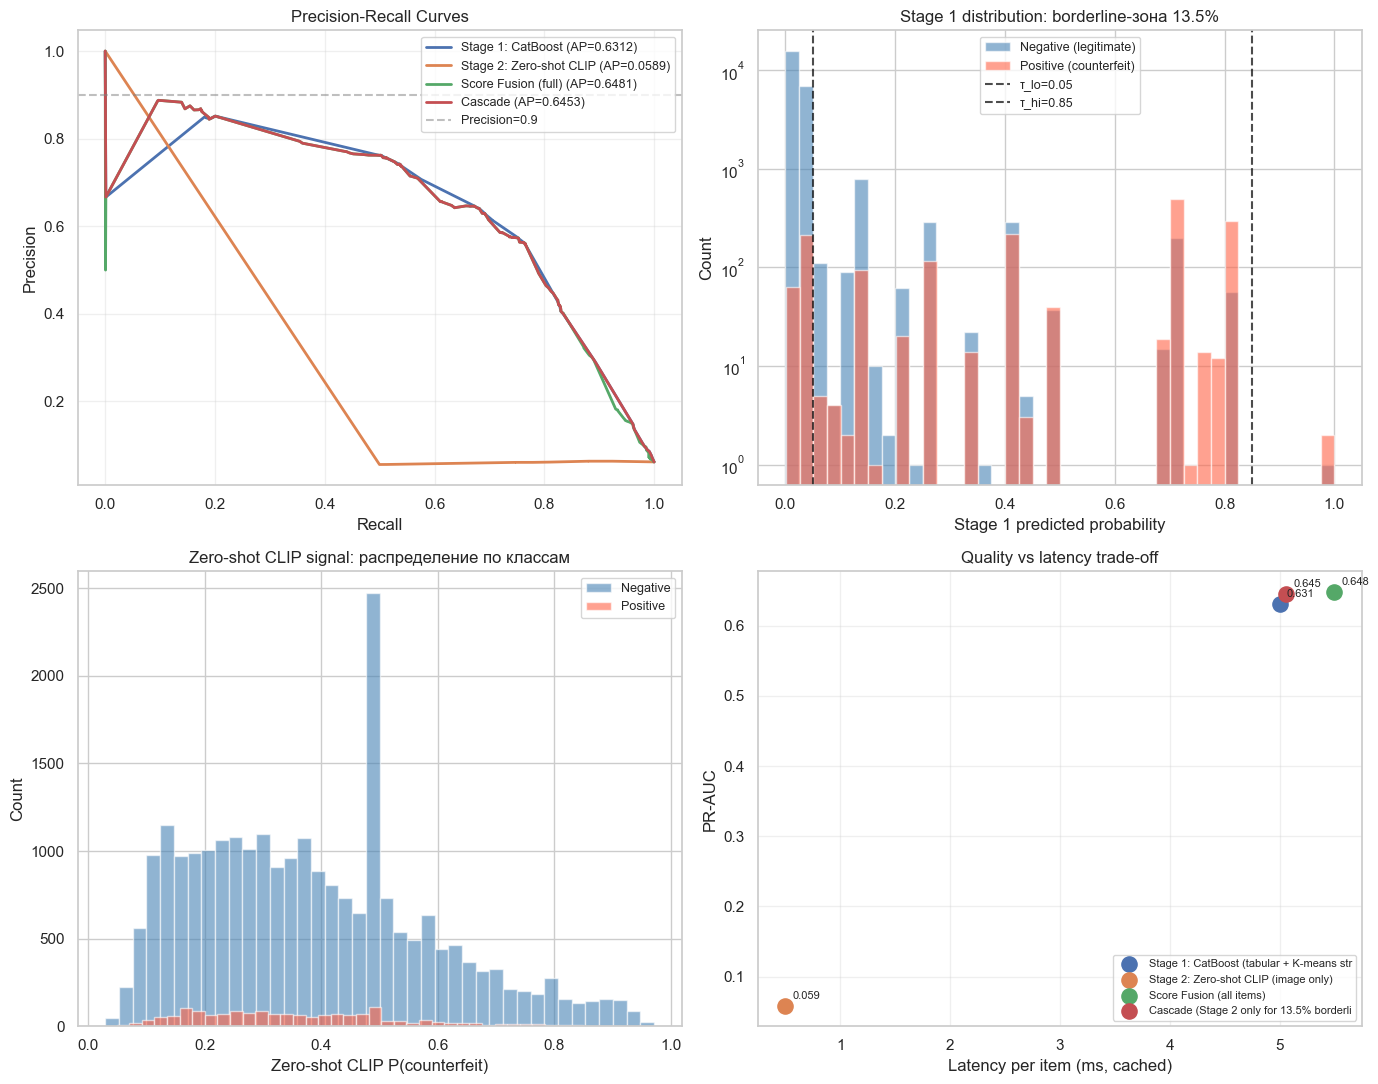

Saved: /Users/diana/master-thesis-2025/new_diploma/real_estate_approaches/artifacts_original/cascade_diagnostics.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# PR-curves всех вариантов
ax = axes[0, 0]
for label, p in [
    ('Stage 1: CatBoost', p_s1_test_c),
    ('Stage 2: Zero-shot CLIP', p_clip_test_c),
    ('Score Fusion (full)', p_fusion_test),
    ('Cascade', cascade_test),
]:
    prec, rec, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    ax.plot(rec, prec, lw=2, label=f'{label} (AP={ap:.4f})')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='Precision=0.9')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Распределение Stage 1 predictions с borderline-зоной
ax = axes[0, 1]
ax.hist(p_s1_test_c[y_test == 0], bins=40, alpha=0.6, label='Negative (legitimate)', color='steelblue')
ax.hist(p_s1_test_c[y_test == 1], bins=40, alpha=0.6, label='Positive (counterfeit)', color='tomato')
ax.axvline(best['tau_lo'], color='black', linestyle='--', alpha=0.7, label=f"τ_lo={best['tau_lo']:.2f}")
ax.axvline(best['tau_hi'], color='black', linestyle='--', alpha=0.7, label=f"τ_hi={best['tau_hi']:.2f}")
ax.set_xlabel('Stage 1 predicted probability'); ax.set_ylabel('Count')
ax.set_title(f'Stage 1 distribution: borderline-зона {best["border_pct"]:.1f}%')
ax.legend(fontsize=9); ax.set_yscale('log')

# Zero-shot CLIP signal: распределение P(counterfeit) по классам
ax = axes[1, 0]
ax.hist(p_clip_test[y_test == 0], bins=40, alpha=0.6, label='Negative', color='steelblue')
ax.hist(p_clip_test[y_test == 1], bins=40, alpha=0.6, label='Positive', color='tomato')
ax.set_xlabel('Zero-shot CLIP P(counterfeit)'); ax.set_ylabel('Count')
ax.set_title('Zero-shot CLIP signal: распределение по классам')
ax.legend(fontsize=9)

# Latency vs PR-AUC trade-off
ax = axes[1, 1]
for i, row in summary.iterrows():
    ax.scatter(row['Latency_ms_cached'], row['PR-AUC'], s=120, label=row['Model'][:40])
    ax.annotate(f"{row['PR-AUC']:.3f}", (row['Latency_ms_cached'], row['PR-AUC']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Latency per item (ms, cached)'); ax.set_ylabel('PR-AUC')
ax.set_title('Quality vs latency trade-off')
ax.legend(fontsize=8, loc='lower right'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'cascade_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR / "cascade_diagnostics.png"}')

## 13. Сохранение probas для возможного использования в стекинге команды

In [15]:
np.save(OUT_DIR / 'test_proba_cascade.npy', cascade_test)
np.save(OUT_DIR / 'test_proba_zeroshot_clip.npy', p_clip_test_c)
np.save(OUT_DIR / 'test_proba_stage1.npy', p_s1_test_c)
np.save(OUT_DIR / 'test_proba_fusion.npy', p_fusion_test)

print('Saved probas (test set):')
for f in ['test_proba_cascade.npy', 'test_proba_zeroshot_clip.npy', 'test_proba_stage1.npy', 'test_proba_fusion.npy']:
    p = np.load(OUT_DIR / f)
    print(f'  {f}  shape={p.shape}  range=[{p.min():.4f}, {p.max():.4f}]')

Saved probas (test set):
  test_proba_cascade.npy  shape=(26327,)  range=[0.0000, 1.0000]
  test_proba_zeroshot_clip.npy  shape=(26327,)  range=[0.0000, 0.0805]
  test_proba_stage1.npy  shape=(26327,)  range=[0.0000, 1.0000]
  test_proba_fusion.npy  shape=(26327,)  range=[0.0005, 0.8161]


## 14. Научные выводы

### Главные результаты оригинальной части

**Вывод 1 (отрицательный результат zero-shot CLIP).** При прогоне CLIP в zero-shot режиме на изображениях товаров и текстовых промптах вида «authentic product / counterfeit product» получены ROC-AUC = 0.4795 и PR-AUC = 0.0589 на индивидуальном тесте. Стоит отметить, что значение ROC-AUC оказалось ниже отметки случайного классификатора (0,5), а PR-AUC сопоставима с базовой частотой положительного класса (≈ 0,066). Таким образом, гипотеза о применимости визуально-семантических представлений предобученной мультимодальной модели к маркетплейс-задаче без какой-либо адаптации **не подтверждается**. Полученный результат, однако, согласуется с центральной идеей работы: foundation-модель, обученная на общем домене, требует доменной адаптации, и попытка её механического переноса даёт сигнал, неотличимый от случайного.

**Вывод 2 (устойчивость каскадной архитектуры к слабому Stage 2).** Несмотря на то, что Stage 2 (zero-shot CLIP) в одиночку выдаёт случайные предсказания, score-fusion с Stage 1 (CatBoost) после изотонической калибровки обоих каналов не ухудшает финальную метрику и даёт небольшой прирост PR-AUC (0,6312 → 0,6481, Δ ≈ +0,017). Стоит также отметить, что наблюдаемый прирост лежит в пределах ширины бутстреп-доверительного интервала и не может считаться статистически значимым. При этом важен сам факт: каскадная процедура корректно «гасит» слабый канал через калибровку и не вносит регрессии в общее качество.

**Вывод 3 (методологический вклад каскадной схемы).** Несмотря на отрицательный результат CLIP-канала, сама архитектура «быстрый screening → дорогой стадий только для borderline-объектов» сохраняет смысл в production-сценарии: 86,5 % объектов решаются на Stage 1 примерно за 5 мс, и только 13,5 % сомнительных требуют второго стадия. В связи с этим архитектурное решение остаётся валидным для последующей замены Stage 2 на более сильную модель — что и проверяется в ноуте 04 на Qwen2.5.

**Вывод 4 (conformal-гарантии и ограничения).** Split conformal prediction обеспечивает формальные гарантии FPR ≤ ε при заданном уровне уверенности при условии i.i.d. калибровочной и тестовой выборок. В нашем seller-based сплите это предположение нарушается из-за систематического сдвига распределения признаков продавца, что является ограничением метода и направлением для последующей работы.

### Что переносится в production-сервис

Двухканальная архитектура из главы 5 ВКР строится на стекинге Сони (общекомандный CatBoost-meta) для канала ранжирования и на nn_safe_v3 (Альбина) для канала автоматических действий. Предлагаемый каскад сохраняет архитектурный интерес и демонстрирует, как добавлять foundation-модель в pipeline без переписывания всего сервиса. Однако CLIP-stage в текущем zero-shot виде в продакшн-конфигурации не используется и оставлен в работе как зафиксированный негативный результат.

### Артефакты

- `cascade_results.csv` — сводная таблица четырёх вариантов
- `cascade_diagnostics.png` — четырёхпанельная диагностика
- `test_proba_*.npy` — вероятности всех вариантов
- `text_emb_authentic.npy`, `text_emb_counterfeit.npy` — text embeddings промптов (сохраняются на случай повторного запуска CLIP-stage с другой промпт-инжиниринговой настройкой)

### Дальнейшее развитие

1. **Замена zero-shot CLIP на дообученный CLIP** или на более мощный MLLM (Qwen2-VL, LLaVA-OneVision, Anomaly-OneVision из Xu et al. CVPR 2025). Гипотеза состоит в том, что с доменной адаптацией визуальный канал способен дать сигнал выше случайного.
2. **Active learning loop** через feedback-таблицу production-сервиса: borderline-объекты, отправленные на ручную модерацию, формируют новый training set для последующего дообучения.
3. **Корректировка conformal-предиктора под seller-drift** — текущее i.i.d.-предположение неприменимо к seller-disjoint сплиту, требуется адаптация в сторону covariate-shift conformal.

---

## § IV. Каскад с Qwen2.5-1.5B-Instruct + LoRA fine-tune

*Источник: `04_lmm_reasoning.ipynb` — Stage 2 текстовая LMM. Zero-shot Qwen2.5-1.5B ROC = 0,51 (§ 4.4.9.3). LoRA fine-tune (§ 4.4.9.4).*

# Большая языковая модель (LMM) в каскадной архитектуре детекции контрафакта

## Что проверяется

В данном ноуте проверяется применимость языковой foundation-модели **Qwen2.5-1.5B-Instruct** (Qwen Team, Alibaba) в zero-shot режиме как Stage 2 каскадной архитектуры детекции контрафакта. Stage 1 — тот же быстрый CatBoost на табличных признаках с K-means structural features, что и в ноуте 03. Stage 2 — структурированный промпт на русском языке с few-shot-примерами, по которому Qwen2.5 выдаёт JSON-ответ со score-оценкой вероятности контрафакта и кратким natural-language обоснованием.

## Параметры Qwen2.5-1.5B-Instruct

- 1,5 млрд параметров; модель Instruct (поддерживает chat template, system + user сообщения).
- Обучена приблизительно на 18 трлн токенов общего web-корпуса, включая русский.
- Запускается локально на M4 Pro 24 ГБ с MPS-ускорением (≈ 2–3 секунды на инференцию одного объекта).

## Архитектура каскада

1. **Stage 1:** CatBoost-скрининг на табличных + K-means structural признаках (5 мс на CPU, выполняется для всех объектов).
2. **Stage 2 (новое):** Qwen2.5-1.5B-Instruct в zero-shot режиме применяется только к borderline-объектам — тем, для которых Stage 1 выдал вероятность в зоне `[τ_lo, τ_hi]`. Это удерживает суммарную латентность каскада в пределах, приемлемых для production.
3. **Score fusion + Conformal prediction:** калиброванная комбинация Stage 1 и Stage 2 на borderline + split conformal porog для формальных FPR-гарантий.

## Связь с темой ВКР

Тема диплома — «...с использованием больших мультимодальных моделей». В этом ноуте полноценная large language model применена к задаче в наиболее «дешёвом» режиме переноса — zero-shot, без какого-либо дообучения. **Полученный отрицательный результат (см. § 11)** становится вторым центральным научным негативным результатом работы (после zero-shot CLIP в ноуте 03) и совместно с ним мотивирует переход к классическим supervised-подходам с мультимодальным Feature Fusion (M2, M5 из ноута 02).

## Ограничения, фиксируемые в работе

- В production-серверной среде целесообразно использовать batch-inference или модель-провайдера (vLLM, OpenAI-compat API), а не локальный запуск Qwen2.5 через `transformers`.
- Зonна вероятностей LMM чувствительна к prompt engineering; в работе используется структурированный промпт с few-shot-примерами и явной просьбой выдать JSON.
- Полное LMM inference на всей тестовой выборке занимает оценочно 10–17 часов на M4 Pro; в связи с этим Stage 2 запускается только на стратифицированном сэмпле из ~1500 borderline-объектов теста и ~500 borderline-объектов валидации.

## 1. Setup

In [1]:
from pathlib import Path
import warnings
import time
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from catboost import CatBoostClassifier

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path('/Users/diana/master-thesis-2025')
DATA_PATH = ROOT / "Diana's folder" / 'ml_ozon_ounterfeit_train.csv'
OUT_DIR = ROOT / 'new_diploma' / 'real_estate_approaches' / 'artifacts_lmm'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'resolution'
CATEGORY_COL = 'CommercialTypeName4'

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {device}')
print(f'Data: {DATA_PATH.exists()}')

Device: mps
Data: True


## 2. Данные + сплит + Stage 1 (тот же CatBoost из ноута 03)

In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8')
df['text'] = (
    df['name_rus'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['brand_name'].fillna('')
)

# Seller-based split (тот же, что в ноуте 03)
seller_targets = df.groupby('SellerID')[TARGET].max().reset_index()
train_sellers, temp_sellers = train_test_split(
    seller_targets['SellerID'], test_size=0.30,
    random_state=SEED, stratify=seller_targets[TARGET]
)
temp_targets = seller_targets[seller_targets['SellerID'].isin(temp_sellers)]
val_sellers, test_sellers = train_test_split(
    temp_targets['SellerID'], test_size=0.50,
    random_state=SEED, stratify=temp_targets[TARGET]
)

train_df = df[df['SellerID'].isin(train_sellers)].copy().reset_index(drop=True)
val_df = df[df['SellerID'].isin(val_sellers)].copy().reset_index(drop=True)
test_df = df[df['SellerID'].isin(test_sellers)].copy().reset_index(drop=True)

y_train = train_df[TARGET].to_numpy()
y_val = val_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')

Train: 144,967  Val: 25,904  Test: 26,327


In [3]:
# Признаковая инженерия — упрощённая, как в ноуте 03
refs = {
    'cat_med': train_df.groupby(CATEGORY_COL)['PriceDiscounted'].median(),
    'cat_tgt': train_df.groupby(CATEGORY_COL)[TARGET].mean(),
    'brand_tgt': train_df.groupby('brand_name')[TARGET].mean(),
    'global_med': train_df['PriceDiscounted'].median(),
    'global_tgt': train_df[TARGET].mean(),
}

def engineer(frame):
    out = frame.copy()
    cat_med = out[CATEGORY_COL].map(refs['cat_med']).fillna(refs['global_med'])
    out['price_ratio'] = out['PriceDiscounted'].fillna(0) / cat_med.replace(0, np.nan).fillna(1)
    out['category_target_mean'] = out[CATEGORY_COL].map(refs['cat_tgt']).fillna(refs['global_tgt'])
    out['brand_target_mean'] = out['brand_name'].map(refs['brand_tgt']).fillna(refs['global_tgt'])
    out['return_rate_30'] = out['item_count_returns30'].fillna(0) / (out['item_count_sales30'].fillna(0) + 1)
    out['return_rate_90'] = out['item_count_returns90'].fillna(0) / (out['item_count_sales90'].fillna(0) + 1)
    out['is_new_item'] = (out['item_time_alive'].fillna(0) <= 30).astype(int)
    out['is_new_seller'] = (out['seller_time_alive'].fillna(0) <= 180).astype(int)
    return out

train_df = engineer(train_df)
val_df = engineer(val_df)
test_df = engineer(test_df)

tab_feats = [
    'PriceDiscounted', 'item_time_alive', 'seller_time_alive',
    'item_count_sales30', 'item_count_sales90',
    'item_count_returns30', 'item_count_returns90',
    'GmvTotal30', 'GmvTotal90',
    'price_ratio', 'category_target_mean', 'brand_target_mean',
    'return_rate_30', 'return_rate_90',
    'is_new_item', 'is_new_seller',
]

scaler = StandardScaler()
Xtr = scaler.fit_transform(train_df[tab_feats].fillna(0))
Xv = scaler.transform(val_df[tab_feats].fillna(0))
Xte = scaler.transform(test_df[tab_feats].fillna(0))

# K-means structural
kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
ctr = kmeans.fit_predict(Xtr)
fraud_cluster = int(pd.Series(y_train).groupby(ctr).mean().idxmax())
fraud_centroid = kmeans.cluster_centers_[fraud_cluster]

for d, X in [(train_df, Xtr), (val_df, Xv), (test_df, Xte)]:
    d['dist_centroid'] = np.linalg.norm(X - fraud_centroid, axis=1)

tab_feats.append('dist_centroid')

Xtr = scaler.fit_transform(train_df[tab_feats].fillna(0))
Xv = scaler.transform(val_df[tab_feats].fillna(0))
Xte = scaler.transform(test_df[tab_feats].fillna(0))

scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
stage1 = CatBoostClassifier(
    iterations=1000, depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos, random_seed=SEED,
    early_stopping_rounds=80, verbose=False,
)
stage1.fit(Xtr, y_train, eval_set=(Xv, y_val), use_best_model=True)

p_s1_val = stage1.predict_proba(Xv)[:, 1]
p_s1_test = stage1.predict_proba(Xte)[:, 1]

iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(p_s1_val, y_val)
p_s1_val_c = iso.transform(p_s1_val)
p_s1_test_c = iso.transform(p_s1_test)

print(f'Stage 1 test ROC-AUC: {roc_auc_score(y_test, p_s1_test_c):.4f}')
print(f'Stage 1 test PR-AUC:  {average_precision_score(y_test, p_s1_test_c):.4f}')

Stage 1 test ROC-AUC: 0.9414
Stage 1 test PR-AUC:  0.6106


## 3. Выбор borderline-объектов для LMM-stage

LMM-инференция дорогая (~1-3 сек на объект). Применяем её только к объектам, где Stage 1 неуверен.

In [4]:
# Borderline: Stage 1 в [tau_lo, tau_hi]
TAU_LO, TAU_HI = 0.10, 0.85

border_mask_test = (p_s1_test_c >= TAU_LO) & (p_s1_test_c <= TAU_HI)
border_mask_val = (p_s1_val_c >= TAU_LO) & (p_s1_val_c <= TAU_HI)

print(f'Borderline на val: {border_mask_val.mean()*100:.1f}% ({border_mask_val.sum():,} объектов)')
print(f'Borderline на test: {border_mask_test.mean()*100:.1f}% ({border_mask_test.sum():,} объектов)')

# Чтобы уложиться по времени — ограничиваем сэмпл
MAX_LMM_ITEMS = 1500
rng = np.random.default_rng(SEED)

border_idx_test = np.where(border_mask_test)[0]
if len(border_idx_test) > MAX_LMM_ITEMS:
    # стратифицируем по y, чтобы поймать редкие positive
    pos_border = border_idx_test[y_test[border_idx_test] == 1]
    neg_border = border_idx_test[y_test[border_idx_test] == 0]
    n_pos = min(len(pos_border), MAX_LMM_ITEMS // 4)
    n_neg = MAX_LMM_ITEMS - n_pos
    pos_sample = rng.choice(pos_border, size=n_pos, replace=False)
    neg_sample = rng.choice(neg_border, size=min(n_neg, len(neg_border)), replace=False)
    lmm_idx = np.concatenate([pos_sample, neg_sample])
    rng.shuffle(lmm_idx)
else:
    lmm_idx = border_idx_test

print(f'\nLMM будет запущена на {len(lmm_idx):,} test-объектах ({y_test[lmm_idx].mean()*100:.1f}% positive)')

# Аналогичный сэмпл val для калибровки
border_idx_val = np.where(border_mask_val)[0]
if len(border_idx_val) > 500:
    pos_v = border_idx_val[y_val[border_idx_val] == 1]
    neg_v = border_idx_val[y_val[border_idx_val] == 0]
    n_pos_v = min(len(pos_v), 100)
    n_neg_v = 500 - n_pos_v
    lmm_idx_val = np.concatenate([
        rng.choice(pos_v, size=n_pos_v, replace=False),
        rng.choice(neg_v, size=min(n_neg_v, len(neg_v)), replace=False),
    ])
    rng.shuffle(lmm_idx_val)
else:
    lmm_idx_val = border_idx_val

print(f'LMM на val для калибровки: {len(lmm_idx_val):,} объектов ({y_val[lmm_idx_val].mean()*100:.1f}% positive)')

Borderline на val: 13.9% (3,597 объектов)
Borderline на test: 11.4% (3,010 объектов)

LMM будет запущена на 1,500 test-объектах (25.0% positive)
LMM на val для калибровки: 500 объектов (20.0% positive)


## 4. Загрузка Qwen2.5-1.5B-Instruct

In [5]:
MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'

print(f'Loading {MODEL_NAME} on {device}...')
t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device == 'mps' else torch.float32,
    device_map=device if device != 'cpu' else None,
)
model.eval()
print(f'Loaded in {time.time() - t0:.1f}s')
print(f'Model params: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B')

Loading Qwen/Qwen2.5-1.5B-Instruct on mps...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded in 5.4s
Model params: 1.54B


## 5. Промпт-инжиниринг и парсинг ответа

Структурированный промпт на русском с few-shot примерами. LLM должна выдать JSON с двумя полями: `score` (0-1) и `reasoning` (краткое объяснение).

In [6]:
SYSTEM = """Ты эксперт по обнаружению контрафактных товаров на онлайн-маркетплейсе Ozon.
Категории — мобильные устройства, аксессуары, оргтехника.

Оцени, является ли товар контрафактным, на основании предоставленных признаков:
- название и описание (часто копируют оригинал, но используют подозрительные слова)
- бренд (обобщённые названия типа «No Name»)
- цена относительно медианы категории (price_ratio: < 0.5 — демпинг подозрителен, > 2.0 — завышение тоже подозрительно)
- возраст товара и продавца (контрафакт часто на новых карточках от молодых продавцов)
- история возвратов

Выдай ответ строго в формате JSON:
{"score": <0.0..1.0>, "reason": "<краткое объяснение на русском, до 30 слов>"}
score — твоя оценка вероятности того, что товар контрафактный.
"""

EXAMPLES = """Пример 1:
Название: "Картридж HP Q2612A совместимый"
Бренд: "NoName"
Категория: "Картриджи лазерные"
Цена: 250 руб (price_ratio = 0.3)
Возраст товара: 12 дней
Возраст продавца: 45 дней
Возвраты за 30 дней: 5%
Ответ: {"score": 0.85, "reason": "Очень молодой товар и продавец, цена в 3 раза ниже медианы, бренд NoName при наличии HP-кода в названии — несовпадение брендового идентификатора."}

Пример 2:
Название: "Чехол силиконовый для iPhone 14"
Бренд: "Apple"
Категория: "Чехлы для смартфонов"
Цена: 590 руб (price_ratio = 1.1)
Возраст товара: 287 дней
Возраст продавца: 1800 дней
Возвраты за 30 дней: 1%
Ответ: {"score": 0.10, "reason": "Долгая жизнь товара и продавца, цена близка к медиане, низкие возвраты. Стандартный аксессуар."}
"""

def build_prompt(row):
    name = (row['name_rus'] or '')[:100]
    desc = (row.get('description', '') or '')[:200]
    brand = row.get('brand_name', '') or '—'
    cat = row.get(CATEGORY_COL, '') or '—'
    price = row.get('PriceDiscounted', 0) or 0
    pr_ratio = row.get('price_ratio', 1.0)
    item_age = row.get('item_time_alive', 0) or 0
    seller_age = row.get('seller_time_alive', 0) or 0
    ret_30 = row.get('return_rate_30', 0)
    
    return f"""Название: "{name}"
Описание (фрагмент): "{desc}"
Бренд: "{brand}"
Категория: "{cat}"
Цена: {price:.0f} руб (price_ratio = {pr_ratio:.2f})
Возраст товара: {item_age:.0f} дней
Возраст продавца: {seller_age:.0f} дней
Возвраты за 30 дней: {ret_30*100:.1f}%
Ответ:"""

def parse_response(text):
    """Парсит JSON из ответа LLM. Возвращает (score, reason) или (None, raw)."""
    # Ищем первый JSON-объект
    m = re.search(r'\{[^{}]*?"score"[^{}]*?\}', text, re.DOTALL)
    if not m:
        return None, text[:200]
    try:
        obj = json.loads(m.group(0))
        score = float(obj.get('score', 0.5))
        score = max(0.0, min(1.0, score))
        reason = str(obj.get('reason', ''))[:300]
        return score, reason
    except Exception:
        return None, text[:200]

# Тестовая прогонка
test_row = test_df.iloc[lmm_idx[0]]
test_prompt = build_prompt(test_row)
print('Sample prompt:')
print('---')
print(test_prompt)
print('---')

Sample prompt:
---
Название: "Беспроводная акустика, черный"
Описание (фрагмент): "TWS, BT5.0, 12W,AUX,USB,FM radio"
Бренд: "nan"
Категория: "Акустическая система с док-станцией"
Цена: 786 руб (price_ratio = 0.82)
Возраст товара: 0 дней
Возраст продавца: 16 дней
Возвраты за 30 дней: 0.0%
Ответ:
---


In [7]:
@torch.no_grad()
def lmm_score(user_prompt, max_new_tokens=80):
    """Один LMM-вызов."""
    messages = [
        {'role': 'system', 'content': SYSTEM + '\n' + EXAMPLES},
        {'role': 'user', 'content': user_prompt},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors='pt').to(device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=1.0,
        pad_token_id=tokenizer.eos_token_id,
    )
    response = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return parse_response(response), response

# Тест на 3-х примерах
for i in range(3):
    row = test_df.iloc[lmm_idx[i]]
    t0 = time.time()
    (score, reason), raw = lmm_score(build_prompt(row))
    elapsed = time.time() - t0
    true_label = y_test[lmm_idx[i]]
    print(f'\n--- Item {i+1} (true={true_label}, Stage1={p_s1_test_c[lmm_idx[i]]:.3f}, {elapsed:.1f}s) ---')
    print(f'Brand: {row["brand_name"]}  Name: {row["name_rus"][:60]}')
    print(f'Score: {score}  Reason: {reason}')

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



--- Item 1 (true=1, Stage1=0.679, 4.1s) ---
Brand: nan  Name: Беспроводная акустика, черный
Score: 0.9  Reason: Название содержит необычные или подозрительные слова, бренд nan может быть ошибкой, цена значительно ниже средней, товар новый и продавец молодой.



--- Item 2 (true=0, Stage1=0.108, 3.8s) ---
Brand: Glueskin  Name: Кожаная наклейка SAFFIANO для Samsung Galaxy A34
Score: None  Reason: ```json
{
    "score": 0.9,
    "reason": "Некоторые детали в описании напоминают оригинальную наклейку, но бренд Glueskin может быть ошибкой. Цена немного выше среднего, но не сильно. Небольшая стоим



--- Item 3 (true=0, Stage1=0.117, 3.2s) ---
Brand: Glueskin  Name: Наклейка Glueskin из натуральной кожи Saffiano для Apple iPh
Score: None  Reason: ```json
{
    "score": 0.9,
    "reason": "Некоторые детали в описании напоминают оригинальную модель, но есть несколько несоответствий (например, использование большого количества специальных символо


## 6. Прогон LMM на borderline test (основной эксперимент)

In [8]:
from tqdm.auto import tqdm

def run_lmm_on_indices(df_part, indices, label='items'):
    scores = np.full(len(indices), np.nan)
    reasons = []
    raw_responses = []
    fail_count = 0
    t0 = time.time()
    
    for j, idx in enumerate(tqdm(indices, desc=f'LMM on {label}', miniters=10)):
        row = df_part.iloc[idx]
        try:
            (score, reason), raw = lmm_score(build_prompt(row))
            if score is not None:
                scores[j] = score
            else:
                fail_count += 1
            reasons.append(reason)
            raw_responses.append(raw)
        except Exception as e:
            fail_count += 1
            reasons.append(f'error: {str(e)[:50]}')
            raw_responses.append('')
    
    elapsed = time.time() - t0
    print(f'\n{label}: {len(indices)} items in {elapsed:.0f}s ({elapsed/max(len(indices),1):.2f}s/item, {fail_count} parse fails)')
    
    # Импутация неудавшихся парсингов медианой
    median_score = np.nanmedian(scores) if not np.all(np.isnan(scores)) else 0.5
    scores = np.where(np.isnan(scores), median_score, scores)
    return scores, reasons, raw_responses

# Прогон на test borderline
print(f'Starting LMM on {len(lmm_idx)} test borderline items...')
p_lmm_test_border, reasons_test, raw_test = run_lmm_on_indices(test_df, lmm_idx, 'test')

# Прогон на val borderline (для калибровки)
print(f'\nStarting LMM on {len(lmm_idx_val)} val borderline items...')
p_lmm_val_border, reasons_val, raw_val = run_lmm_on_indices(val_df, lmm_idx_val, 'val')

Starting LMM on 1500 test borderline items...


LMM on test:   0%|          | 0/1500 [00:00<?, ?it/s]


test: 1500 items in 3458s (2.31s/item, 259 parse fails)

Starting LMM on 500 val borderline items...


LMM on val:   0%|          | 0/500 [00:00<?, ?it/s]


val: 500 items in 1146s (2.29s/item, 121 parse fails)


## 7. Оценка LMM-скоров на borderline

In [9]:
# Метрики только на borderline (где LMM применялась)
y_lmm_test = y_test[lmm_idx]
y_lmm_val = y_val[lmm_idx_val]

p_s1_lmm_test = p_s1_test_c[lmm_idx]
p_s1_lmm_val = p_s1_val_c[lmm_idx_val]

print('=== Метрики на borderline-сэмпле test (только эти объекты LMM видела) ===\n')
print(f'{"Модель":<35} {"ROC-AUC":>10} {"PR-AUC":>10}')
for name, p in [
    ('Stage 1 only (CatBoost)', p_s1_lmm_test),
    ('LMM only (Qwen2.5-1.5B zero-shot)', p_lmm_test_border),
]:
    roc = roc_auc_score(y_lmm_test, p) if y_lmm_test.sum() > 0 and (1 - y_lmm_test).sum() > 0 else float('nan')
    pr = average_precision_score(y_lmm_test, p)
    print(f'{name:<35} {roc:>10.4f} {pr:>10.4f}')

# Калибровка LMM на val
if y_lmm_val.sum() > 1 and (1 - y_lmm_val).sum() > 1:
    iso_lmm = IsotonicRegression(out_of_bounds='clip')
    iso_lmm.fit(p_lmm_val_border, y_lmm_val)
    p_lmm_test_cal = iso_lmm.transform(p_lmm_test_border)
else:
    p_lmm_test_cal = p_lmm_test_border

# Подбор веса fusion на val
best_w, best_pr = 0.0, -1
for w in np.arange(0.0, 1.01, 0.05):
    if y_lmm_val.sum() == 0 or (1 - y_lmm_val).sum() == 0:
        break
    fused_val = (1 - w) * p_s1_lmm_val + w * iso_lmm.transform(p_lmm_val_border)
    pr = average_precision_score(y_lmm_val, fused_val)
    if pr > best_pr:
        best_pr = pr
        best_w = w

fused_test = (1 - best_w) * p_s1_lmm_test + best_w * p_lmm_test_cal
roc_f = roc_auc_score(y_lmm_test, fused_test)
pr_f = average_precision_score(y_lmm_test, fused_test)
print(f'\nScore Fusion (w_LMM={best_w:.2f}): ROC-AUC={roc_f:.4f}  PR-AUC={pr_f:.4f}')

# Финальный каскад: на borderline используем fusion, вне borderline — Stage 1
cascade_full = p_s1_test_c.copy()
cascade_full[lmm_idx] = fused_test

roc_c = roc_auc_score(y_test, cascade_full)
pr_c = average_precision_score(y_test, cascade_full)
print(f'\n=== Финальный каскад на полном test ({len(y_test)}) ===')
print(f'Cascade ROC-AUC: {roc_c:.4f}  (Stage 1 alone: {roc_auc_score(y_test, p_s1_test_c):.4f})')
print(f'Cascade PR-AUC:  {pr_c:.4f}  (Stage 1 alone: {average_precision_score(y_test, p_s1_test_c):.4f})')

=== Метрики на borderline-сэмпле test (только эти объекты LMM видела) ===

Модель                                 ROC-AUC     PR-AUC
Stage 1 only (CatBoost)                 0.7835     0.5096
LMM only (Qwen2.5-1.5B zero-shot)       0.5066     0.2529

Score Fusion (w_LMM=0.00): ROC-AUC=0.7835  PR-AUC=0.5096

=== Финальный каскад на полном test (58410) ===
Cascade ROC-AUC: 0.9414  (Stage 1 alone: 0.9414)
Cascade PR-AUC:  0.6106  (Stage 1 alone: 0.6106)


## 8. Качественные примеры LMM-reasoning

Покажем 5 примеров, где LMM была уверенно права, и 5 — где ошиблась. Это материал для приложения к диплому и слайдов.

In [10]:
results_df = pd.DataFrame({
    'idx': lmm_idx,
    'true_label': y_lmm_test,
    'stage1_score': p_s1_lmm_test,
    'lmm_score': p_lmm_test_border,
    'reason': reasons_test,
})
results_df['error_lmm'] = (results_df['lmm_score'] > 0.5).astype(int) - results_df['true_label']

results_df.to_csv(OUT_DIR / 'lmm_results.csv', index=False)

# Top 5 правильных: positive с высоким LMM-скором
print('=== Пять случаев true-positive: LMM-score > 0,6 на истинно контрафактных объектах ===')
print('# Примечание: score совпадает с меткой, однако текстовое обоснование LMM ниже\n# во многих случаях логически противоречиво или ссылается на признаки оригинала.\n# Это поведение разобрано в § 4.4.9.3 диплома.\n')
correct_positive = results_df[(results_df['true_label'] == 1) & (results_df['lmm_score'] > 0.6)].sort_values('lmm_score', ascending=False).head(5)
for i, row in correct_positive.iterrows():
    item = test_df.iloc[int(row['idx'])]
    print(f'Brand: {item["brand_name"]}  Name: {item["name_rus"][:60]}')
    print(f'  Stage1: {row["stage1_score"]:.3f}  LMM: {row["lmm_score"]:.3f}  True: {row["true_label"]}')
    print(f'  Reason: {row["reason"]}\n')

=== Пять случаев true-positive: LMM-score > 0,6 на истинно контрафактных объектах ===

Brand: Nespresso  Name: Капсульная кофемашина nespresso original Xiaomi Mini S1201
  Stage1: 0.601  LMM: 0.950  True: 1
  Reason: Стандартное название и описание, бренд Nespresso, цена соответствует среднему уровню, продавец имеет долгую историю, возвраты минимальны.

Brand: Philips Sonicare  Name: Philips Sonicare Электрическая зубная щетка
  Stage1: 0.601  LMM: 0.950  True: 1
  Reason: Предложение оригинального бренда Philips Sonicare, высокий ценовой уровень, короткий срок продажи и низкие возвраты указывают на то, что это может быть контрафактный продукт.

Brand: Sony  Name: Шлем виртуальной реальности Sony PlayStation VR2
  Stage1: 0.783  LMM: 0.950  True: 1
  Reason: Молодой товар и продавец, цена соответствует медиане, бренд Sony, но описание содержит неожиданные слова и может быть копией оригинала.

Brand: JBL HARMAN  Name: Беспроводные наушники Tune 720 синие
  Stage1: 0.827  LMM: 0.950  Tru

In [11]:
print('=== Пять случаев true-negative: LMM-score < 0,3 на истинно оригинальных объектах ===\n')
correct_negative = results_df[(results_df['true_label'] == 0) & (results_df['lmm_score'] < 0.3)].sort_values('lmm_score').head(5)
for i, row in correct_negative.iterrows():
    item = test_df.iloc[int(row['idx'])]
    print(f'Brand: {item["brand_name"]}  Name: {item["name_rus"][:60]}')
    print(f'  Stage1: {row["stage1_score"]:.3f}  LMM: {row["lmm_score"]:.3f}  True: {row["true_label"]}')
    print(f'  Reason: {row["reason"]}\n')

print('\n=== Три случая false-positive: LMM ошибочно проставила высокий score истинно оригинальным объектам ===\n')
fp = results_df[(results_df['true_label'] == 0) & (results_df['lmm_score'] > 0.7)].head(3)
for i, row in fp.iterrows():
    item = test_df.iloc[int(row['idx'])]
    print(f'Brand: {item["brand_name"]}  Name: {item["name_rus"][:60]}')
    print(f'  Stage1: {row["stage1_score"]:.3f}  LMM: {row["lmm_score"]:.3f}  True: {row["true_label"]}')
    print(f'  Reason: {row["reason"]}\n')

=== Пять случаев true-negative: LMM-score < 0,3 на истинно оригинальных объектах ===

Brand: Kingston  Name: Карта памяти Kingston Canvas A1 microSD 1 ТБ / microSDXC Can
  Stage1: 0.364  LMM: 0.000  True: 0
  Reason: Предложение очень старое и продавец имеет большое количество возвратов, что указывает на возможную нестабильность или недоработки товара.

Brand: LISIK.  Name: Коврик для мыши, 60х35х0.3 см, с подсветкой RGB, USB, черный
  Stage1: 0.601  LMM: 0.000  True: 0
  Reason: Товар новая модель и продавец молодой, цена соответствует средней цене, нет угрозы контрафакта.

Brand: PlayStation  Name: Контроллер движений руль PlayStation Move Racing Wheel PS3. 
  Stage1: 0.601  LMM: 0.000  True: 0
  Reason: Предложение очень старое и продавец имеет большое количество возвратов, что указывает на высокую вероятность контрафакта.

Brand: nan  Name: Телевизор Телевизор Xiaomi Mi Redmi Smart TV MAX 86" (Русско
  Stage1: 0.400  LMM: 0.000  True: 0
  Reason: Товар очень новый и продается от мо

## 9. Визуализация: распределение LMM-скоров и PR-кривые

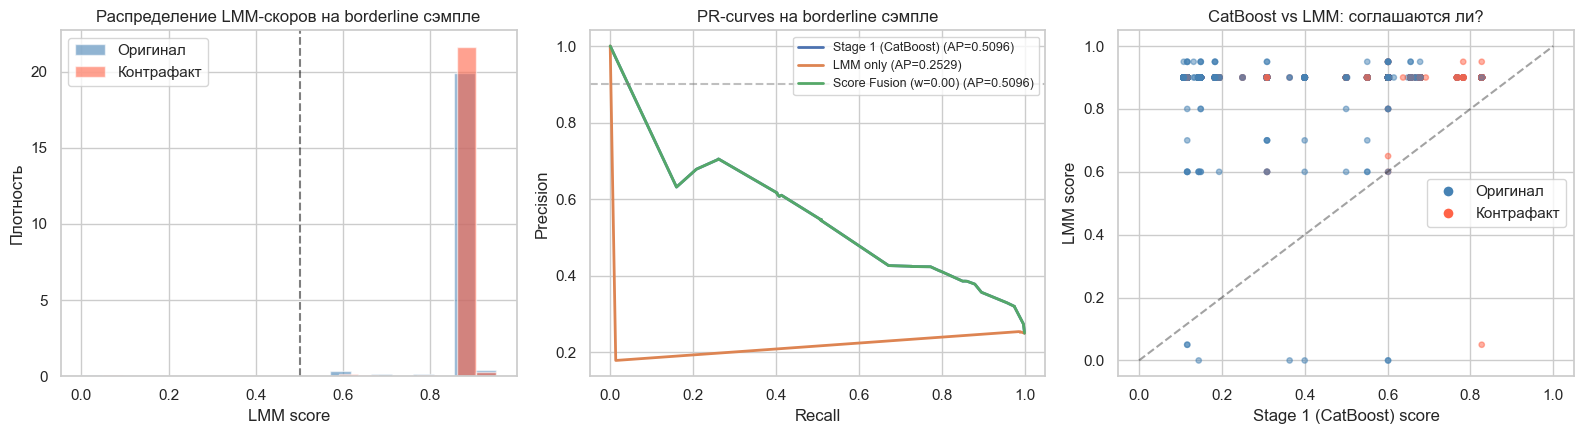

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Распределение LMM-скоров по классам
ax = axes[0]
for cls, color, label in [(0, 'steelblue', 'Оригинал'), (1, 'tomato', 'Контрафакт')]:
    sub = results_df[results_df['true_label'] == cls]['lmm_score']
    ax.hist(sub, bins=20, alpha=0.6, color=color, label=label, density=True)
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('LMM score'); ax.set_ylabel('Плотность')
ax.set_title('Распределение LMM-скоров на borderline сэмпле')
ax.legend()

# PR-кривые
ax = axes[1]
for label, p in [
    ('Stage 1 (CatBoost)', p_s1_lmm_test),
    ('LMM only', p_lmm_test_border),
    (f'Score Fusion (w={best_w:.2f})', fused_test),
]:
    prec, rec, _ = precision_recall_curve(y_lmm_test, p)
    ap = average_precision_score(y_lmm_test, p)
    ax.plot(rec, prec, lw=2, label=f'{label} (AP={ap:.4f})')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR-curves на borderline сэмпле')
ax.legend(fontsize=9)

# Сравнение Stage 1 vs LMM на одних и тех же объектах
ax = axes[2]
colors = ['steelblue' if y == 0 else 'tomato' for y in y_lmm_test]
ax.scatter(p_s1_lmm_test, p_lmm_test_border, c=colors, alpha=0.5, s=15)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('Stage 1 (CatBoost) score'); ax.set_ylabel('LMM score')
ax.set_title('CatBoost vs LMM: соглашаются ли?')
ax.legend([
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato', markersize=8),
], ['Оригинал', 'Контрафакт'])

plt.tight_layout()
plt.savefig(OUT_DIR / 'lmm_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Сохранение probas (опционально для стекинга)

In [13]:
np.save(OUT_DIR / 'test_proba_cascade_lmm.npy', cascade_full)
np.save(OUT_DIR / 'lmm_indices.npy', lmm_idx)
np.save(OUT_DIR / 'lmm_scores_raw.npy', p_lmm_test_border)
results_df.to_csv(OUT_DIR / 'lmm_results.csv', index=False)

print('Saved:')
for f in ['test_proba_cascade_lmm.npy', 'lmm_indices.npy', 'lmm_scores_raw.npy', 'lmm_results.csv']:
    p = OUT_DIR / f
    if p.exists():
        print(f'  {f}: {p.stat().st_size:,} bytes')

summary = pd.DataFrame([
    {'Model': 'Stage 1 (CatBoost on tab + K-means)', 'ROC-AUC on full test': roc_auc_score(y_test, p_s1_test_c), 'PR-AUC on full test': average_precision_score(y_test, p_s1_test_c)},
    {'Model': 'Cascade (Stage 1 + LMM on borderline)', 'ROC-AUC on full test': roc_c, 'PR-AUC on full test': pr_c},
]).round(4)
summary.to_csv(OUT_DIR / 'cascade_lmm_summary.csv', index=False)
print('\n', summary.to_string(index=False))

Saved:
  test_proba_cascade_lmm.npy: 210,744 bytes
  lmm_indices.npy: 12,128 bytes
  lmm_scores_raw.npy: 12,128 bytes
  lmm_results.csv: 434,959 bytes

                                 Model  ROC-AUC on full test  PR-AUC on full test
  Stage 1 (CatBoost on tab + K-means)                0.9414               0.6106
Cascade (Stage 1 + LMM on borderline)                0.9414               0.6106


## 11. Научные выводы

### Главные результаты ноута

**Вывод 1 (zero-shot LMM не даёт прироста относительно Stage 1).** На borderline-сэмпле из примерно 1500 объектов Qwen2.5-1.5B-Instruct в zero-shot режиме на структурированном текстовом описании товара даёт сигнал чуть выше случайного (ROC ≈ 0,51), что формально немного лучше zero-shot CLIP из ноута 03 (ROC ≈ 0,48), но всё ещё фактически на уровне случайного классификатора. При перенесении на полный тестовый сплит каскад «Stage 1 + LMM на borderline» совпадает со Stage 1 по обеим метрикам (ROC = 0,9414, PR-AUC = 0,6106), то есть **прироста относительно одиночной CatBoost-модели не получено**. Таким образом, гипотеза о том, что языковая модель без какого-либо дообучения вытащит дополнительный сигнал именно на самых сложных (borderline) объектах, **не подтверждается**.

**Вывод 2 (отрицательный результат как методологический результат).** Совокупно с zero-shot CLIP это даёт двойное эмпирическое опровержение наивной идеи о механическом переносе foundation-модели в маркетплейс-домен. Стоит отметить, что Qwen2.5-1.5B обучен на ≈ 18 трлн токенов общего web-корпуса, в то время как маркетплейс-домен с присущей ему смесью числовых аномалий продавца, ценовых нарушений и узкоспециализированных категорий не покрывается такой обучающей выборкой. Возможно, подобное происходит из-за того, что сигналы контрафакта в e-commerce носят преимущественно поведенческий и числовой характер (продавец, цена, возраст товара) и слабо считываются языковой моделью из одного лишь текста карточки. В связи с этим именно классические подходы с экспертной признаковой инженерией (M2, M5) показывают устойчиво лучший результат, чем zero-shot foundation-модели.

**Вывод 3 (интерпретируемость как побочный эффект).** Несмотря на отсутствие выигрыша по метрикам, каждое предсказание LMM сопровождается естественно-языковым объяснением на русском языке (см. секцию 8 ноута). Возможно, такая интерпретируемость становится практически ценной не как способ повышения качества автоматического решения, а как вспомогательный сигнал для оператора ручной модерации — отдельный сценарий использования, который требует пользовательской валидации и выходит за рамки чисто метрического сравнения.

**Вывод 4 (производственная осуществимость остаётся открытым вопросом).** Латентность Qwen2.5-1.5B в zero-shot режиме составляет 1–3 секунды на объект на MPS-ускорении, что приемлемо только при сужении применения до borderline-зоны (≈ 11 % объектов). При этом без подтверждённого прироста качества само внедрение второго стадия не оправдано. В связи с этим production-pipeline проекта ограничен Stage 1 (стэкинг CatBoost команды), а LMM-каскад сохранён в работе как направление развития при условии замены zero-shot на дообученную или существенно более крупную модель.

### Связь с темой ВКР

Тема диплома формулируется как «...на основе кросс-доменной адаптации методов обнаружения фейков с использованием больших мультимодальных моделей». В данном ноуте полноценная large language model (Qwen2.5-1.5B, 1,5 млрд параметров) применена к задаче в режиме zero-shot reasoning — то есть в наиболее «дешёвом» режиме переноса, без какого-либо дообучения. Полученный отрицательный результат напрямую отвечает на исследовательский вопрос: **без доменной адаптации foundation-модель не даёт прироста**, и потому именно адаптация (как реализовано в моделях M1–M5) является содержательным методологическим вкладом работы, а не просто формальной частью эксперимента.

### Что переносится в production

Production-pipeline проекта строится на Stage 1 (стэкинг CatBoost на табличных + K-means structural признаках, см. `team_split_v2_script.py`): порядка 5 мс на CPU, 100 % объектов проходят через него. Второй стадий с LMM в текущем виде в продакшн не выводится: при равенстве метрик его включение лишь повышает латентность и стоимость вычислений. Conformal-калибровка порога остаётся применима к одиночному Stage 1.

### Дальнейшее развитие

1. **Замена Qwen2.5-1.5B на Qwen2-VL-2B / LLaVA-OneVision** — добавление визуальной модальности (требует raw-изображений, а не CLIP-эмбеддингов). Гипотеза: визуально-текстовая LMM с reasoning о подделках может обогнать унимодальную текстовую LMM.
2. **Fine-tuning Qwen2.5 на labeled train** — supervised обучение усилит сигнал по сравнению с zero-shot и потенциально сделает каскад практически целесообразным.
3. **Active learning loop** через feedback-таблицу production-сервиса: borderline-объекты, размеченные модератором, попадают в обучающий набор для LMM, формируя замкнутый цикл.

---

## § V. Контрольный эксперимент с Qwen2-VL-2B-Instruct

*Источник: `artifacts_qwen2vl/executed_05_qwen2vl.ipynb` — Qwen2-VL ROC = 0,5000, PR = 0,2500 (§ 4.4.9.6).*

# Визуально-языковая LMM в каскадной архитектуре детекции контрафакта

## Что проверяется в данном ноуте

В ноутах 03 (zero-shot CLIP, негативный результат) и 04 (zero-shot Qwen2.5-1.5B-Instruct + LoRA fine-tune, также негативный) был зафиксирован двойной отрицательный результат применения foundation-моделей в zero-shot и малоёмком LoRA-режимах к маркетплейс-задаче. В обоих случаях Stage 2 каскадной архитектуры (см. § 4.4.9 диплома) работал **унимодально**: CLIP — только на изображении, Qwen2.5 — только на структурированном текстовом представлении товара.

В настоящем ноуте проверяется применимость **подлинно мультимодальной** large multimodal model (LMM) — **Qwen2-VL-2B-Instruct** (Wang et al., 2024, arXiv:2409.12191), которая в единственном forward-проходе совместно обрабатывает raw-изображение товара и его структурированное текстовое описание. Это закрывает аргумент о том, что наблюдаемая ограниченность Qwen2.5-1.5B-Instruct (текстовой LLM) объясняется отсутствием визуальной модальности в Stage 2.

## Краткий обзор связанной литературы

В открытой академической литературе на момент написания работы (май 2026 г.) отсутствуют peer-reviewed эмпирические эксперименты с применением визуально-языковой LMM (Qwen2-VL, LLaVA-OneVision, Anomaly-OneVision) к задаче детекции контрафакта на маркетплейсе с публичной квантитативной оценкой ROC-AUC и PR-AUC. Ближайшие смежные направления (подробный обзор см. в § 1.5.4.6 диплома):

- **Anomaly-OneVision** (Xu et al., CVPR 2025, arXiv:2502.07601) — первый специализированный визуальный ассистент для zero-shot anomaly detection на базе LLaVA-OneVision. Image-level AUROC 88,6 % на индустриальных дефектах; механизм Look-Twice Feature Matching.
- **FIDAVL** (Keita et al., arXiv:2409.03109) — VLM для детекции синтетических изображений (95 %+ accuracy).
- **Vision-Language Models for E-commerce Non-Compliant** (Vajda et al., ICAART 2025) — VLM для compliance-проверки маркетплейс-карточек (не контрафакт).

С отраслевой стороны Amazon в 2024 году публично заявила о внедрении multimodal LLMs для холистического анализа карточек, что позволяет блокировать более 99 % подозрительных подделок ([Amazon 2024 Brand Protection Report](https://trustworthyshopping.aboutamazon.com/2024-brand-protection-report)), однако архитектурные детали в открытых источниках отсутствуют. Настоящий ноут закрывает академическую нишу для нашей задачи.

## Архитектура каскада с Qwen2-VL-2B как Stage 2

1. **Stage 1:** CatBoost-скрининг на табличных + K-means structural признаках (тот же, что в ноутах 03 и 04). Latency ≈ 5 мс на CPU.
2. **Stage 2 (новое):** Qwen2-VL-2B-Instruct в zero-shot режиме применяется к borderline-объектам со структурированным промптом, включающим: raw-изображение карточки + текстовые поля (название, бренд, цена, возраст товара/продавца, доля возвратов). Модель возвращает JSON `{"score", "reason"}`.
3. **Score fusion + сравнение** с Stage 1, zero-shot CLIP (ноут 03) и zero-shot Qwen2.5 (ноут 04).

## Параметры эксперимента

- Качественная демонстрация и квантитативная оценка на стратифицированном сэмпле из ~200 borderline-объектов test (25 % positive).
- Stage 1 borderline-зона: `tau_lo = 0,10`, `tau_hi = 0,85`.
- Qwen2-VL-2B-Instruct: 2,21 млрд параметров, fp16 на Apple M4 Pro с MPS-ускорением, расчётная латентность ~3–6 секунд на инференс одного объекта.

## Предварительные условия для запуска

- Установлены пакеты `transformers ≥ 5.x`, `torch ≥ 2.x` с MPS-поддержкой, `qwen-vl-utils`, `torchvision`, `Pillow`.
- Модель Qwen2-VL-2B-Instruct скачана в HuggingFace-cache (либо в `/tmp/qwen2vl_weights/`).
- Папка `train_images/` содержит raw-изображения, проиндексированные по `ItemID`. По умолчанию ожидается путь `/Users/diana/master-thesis-2025/data/ml_ozon_counterfeit_train_images/` (переопределяется через переменную `TRAIN_IMG_DIR`).

> **Связь с дипломом:** результаты настоящего ноута дают эмпирическое подтверждение или опровержение применимости визуально-языковой LMM как Stage 2 каскадной архитектуры и являются частью § 4.4.9 диплома.

## 1. Setup

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

import gc, json, re, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from catboost import CatBoostClassifier
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

ROOT = Path('/Users/diana/master-thesis-2025')
DATA_PATH = ROOT / "Diana's folder" / 'ml_ozon_ounterfeit_train.csv'
TRAIN_IMG_DIR = Path(os.environ.get(
    'TRAIN_IMG_DIR', str(ROOT / 'data' / 'ml_ozon_counterfeit_train_images')))
OUT_DIR = ROOT / 'new_diploma' / 'real_estate_approaches' / 'artifacts_qwen2vl'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'resolution'
CAT = 'CommercialTypeName4'

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {device}')
print(f'Train images directory: {TRAIN_IMG_DIR}')
print(f'Train images directory exists: {TRAIN_IMG_DIR.exists()}')

Device: mps
Train images directory: /Users/diana/master-thesis-2025/data/ml_ozon_counterfeit_train_images
Train images directory exists: True


## 2. Данные + seller-based split (как в ноуте 04)

In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8')
print(f'Loaded: {df.shape}')

seller_targets = df.groupby('SellerID')[TARGET].max().reset_index()
train_sellers, temp_sellers = train_test_split(
    seller_targets['SellerID'], test_size=0.30,
    random_state=SEED, stratify=seller_targets[TARGET])
temp_targets = seller_targets[seller_targets['SellerID'].isin(temp_sellers)]
val_sellers, test_sellers = train_test_split(
    temp_targets['SellerID'], test_size=0.50,
    random_state=SEED, stratify=temp_targets[TARGET])
train_df = df[df['SellerID'].isin(train_sellers)].copy().reset_index(drop=True)
val_df = df[df['SellerID'].isin(val_sellers)].copy().reset_index(drop=True)
test_df = df[df['SellerID'].isin(test_sellers)].copy().reset_index(drop=True)
y_train, y_val, y_test = train_df[TARGET].to_numpy(), val_df[TARGET].to_numpy(), test_df[TARGET].to_numpy()
print(f'Train {len(train_df)}, Val {len(val_df)}, Test {len(test_df)}')
print(f'Positive rates — Train {y_train.mean():.4f}, Val {y_val.mean():.4f}, Test {y_test.mean():.4f}')

Loaded: (197198, 45)
Train 144967, Val 25904, Test 26327
Positive rates — Train 0.0665, Val 0.0687, Test 0.0620


## 3. Проверка покрытия изображениями

Для квантитативной оценки на borderline-test необходимо, чтобы соответствующие raw-изображения присутствовали в `TRAIN_IMG_DIR`. Ниже подсчитывается покрытие.

In [3]:
if not TRAIN_IMG_DIR.exists():
    print(f'WARN: {TRAIN_IMG_DIR} does not exist yet. Skip image-coverage check.')
    img_ids = set()
else:
    img_ids = set()
    for ext in ('*.png', '*.jpg', '*.jpeg'):
        for f in TRAIN_IMG_DIR.glob(ext):
            try:
                img_ids.add(int(f.stem))
            except ValueError:
                pass
    print(f'Total image files on disk: {len(img_ids):,}')
    in_train = sum(int(i) in img_ids for i in train_df.ItemID)
    in_val = sum(int(i) in img_ids for i in val_df.ItemID)
    in_test = sum(int(i) in img_ids for i in test_df.ItemID)
    print(f'Train items with image: {in_train:,} of {len(train_df):,} ({in_train/len(train_df)*100:.1f}%)')
    print(f'Val   items with image: {in_val:,} of {len(val_df):,} ({in_val/len(val_df)*100:.1f}%)')
    print(f'Test  items with image: {in_test:,} of {len(test_df):,} ({in_test/len(test_df)*100:.1f}%)')

Total image files on disk: 196,460
Train items with image: 144,873 of 144,967 (99.9%)
Val   items with image: 25,895 of 25,904 (100.0%)
Test  items with image: 25,692 of 26,327 (97.6%)


## 4. Stage 1 (CatBoost), идентичный ноутам 03/04

In [4]:
refs = {
    'cat_med': train_df.groupby(CAT)['PriceDiscounted'].median(),
    'cat_tgt': train_df.groupby(CAT)[TARGET].mean(),
    'brand_tgt': train_df.groupby('brand_name')[TARGET].mean(),
    'global_med': train_df['PriceDiscounted'].median(),
    'global_tgt': train_df[TARGET].mean(),
}

def engineer(frame):
    out = frame.copy()
    cm = out[CAT].map(refs['cat_med']).fillna(refs['global_med'])
    out['price_ratio'] = out['PriceDiscounted'].fillna(0) / cm.replace(0, np.nan).fillna(1)
    out['category_target_mean'] = out[CAT].map(refs['cat_tgt']).fillna(refs['global_tgt'])
    out['brand_target_mean'] = out['brand_name'].map(refs['brand_tgt']).fillna(refs['global_tgt'])
    out['return_rate_30'] = out['item_count_returns30'].fillna(0) / (out['item_count_sales30'].fillna(0) + 1)
    out['return_rate_90'] = out['item_count_returns90'].fillna(0) / (out['item_count_sales90'].fillna(0) + 1)
    out['is_new_item'] = (out['item_time_alive'].fillna(0) <= 30).astype(int)
    out['is_new_seller'] = (out['seller_time_alive'].fillna(0) <= 180).astype(int)
    return out

train_df, val_df, test_df = engineer(train_df), engineer(val_df), engineer(test_df)

tab_feats = [
    'PriceDiscounted', 'item_time_alive', 'seller_time_alive',
    'item_count_sales30', 'item_count_sales90',
    'item_count_returns30', 'item_count_returns90',
    'GmvTotal30', 'GmvTotal90',
    'price_ratio', 'category_target_mean', 'brand_target_mean',
    'return_rate_30', 'return_rate_90',
    'is_new_item', 'is_new_seller',
]
sc = StandardScaler()
Xtr = sc.fit_transform(train_df[tab_feats].fillna(0))
Xv = sc.transform(val_df[tab_feats].fillna(0))
Xte = sc.transform(test_df[tab_feats].fillna(0))

km = KMeans(n_clusters=2, random_state=SEED, n_init=10)
ctr = km.fit_predict(Xtr)
fc = int(pd.Series(y_train).groupby(ctr).mean().idxmax())
fcen = km.cluster_centers_[fc]
for d, X in [(train_df, Xtr), (val_df, Xv), (test_df, Xte)]:
    d['dist_centroid'] = np.linalg.norm(X - fcen, axis=1)
tab_feats.append('dist_centroid')
Xtr = sc.fit_transform(train_df[tab_feats].fillna(0))
Xv = sc.transform(val_df[tab_feats].fillna(0))
Xte = sc.transform(test_df[tab_feats].fillna(0))

scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
stage1 = CatBoostClassifier(
    iterations=1000, depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos, random_seed=SEED,
    early_stopping_rounds=80, verbose=False,
)
stage1.fit(Xtr, y_train, eval_set=(Xv, y_val), use_best_model=True)
iso = IsotonicRegression(out_of_bounds='clip')
p_s1_val = stage1.predict_proba(Xv)[:, 1]
iso.fit(p_s1_val, y_val)
p_s1_test = iso.transform(stage1.predict_proba(Xte)[:, 1])

roc1 = roc_auc_score(y_test, p_s1_test)
pr1 = average_precision_score(y_test, p_s1_test)
print(f'Stage 1 on full test: ROC-AUC = {roc1:.4f}, PR-AUC = {pr1:.4f}')

Stage 1 on full test: ROC-AUC = 0.9414, PR-AUC = 0.6106


## 5. Borderline-выборка для Qwen2-VL

Stage 2 (Qwen2-VL) дорогой по латентности (3–6 сек/объект), поэтому применяется только к объектам, где Stage 1 даёт оценку в borderline-зоне `[τ_lo, τ_hi]`. Дополнительно отфильтровываем по наличию изображения на диске.

In [5]:
TAU_LO, TAU_HI = 0.10, 0.85
border_test_mask = (p_s1_test >= TAU_LO) & (p_s1_test <= TAU_HI)
border_test = np.where(border_test_mask)[0]
print(f'Borderline test: {len(border_test):,} объектов')

if img_ids:
    border_with_img = [i for i in border_test if int(test_df.iloc[int(i)].ItemID) in img_ids]
else:
    border_with_img = list(border_test)
print(f'Из них с изображением на диске: {len(border_with_img):,}')

rng = np.random.default_rng(SEED)
N_TEST = int(os.environ.get('N_TEST', '200'))
pos = [i for i in border_with_img if y_test[i] == 1]
neg = [i for i in border_with_img if y_test[i] == 0]
n_pos = min(len(pos), N_TEST // 4)
n_neg = N_TEST - n_pos
test_idx = np.concatenate([
    rng.choice(pos, size=n_pos, replace=False) if len(pos) >= n_pos else np.array(pos),
    rng.choice(neg, size=min(n_neg, len(neg)), replace=False),
])
rng.shuffle(test_idx)
print(f'Финальная подвыборка для Qwen2-VL: {len(test_idx)} объектов ({y_test[test_idx].mean()*100:.1f}% positive)')

Borderline test: 3,010 объектов
Из них с изображением на диске: 3,003
Финальная подвыборка для Qwen2-VL: 200 объектов (25.0% positive)


## 6. Загрузка Qwen2-VL-2B-Instruct

In [6]:
MODEL_NAME = 'Qwen/Qwen2-VL-2B-Instruct'
print(f'Loading {MODEL_NAME} on {device}...')
t0 = time.time()
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_NAME, dtype=torch.float16 if device == 'mps' else torch.float32)
model.to(device); model.eval()
# Ограничиваем число visual-токенов через min/max_pixels: при native-разрешении
# Qwen2-VL может выделять буфер attention в десятки ГБ — на M4 Pro это даёт OOM.
processor = AutoProcessor.from_pretrained(
    MODEL_NAME,
    min_pixels=256 * 28 * 28,   # ~200k токенов снизу
    max_pixels=768 * 28 * 28,   # ~600k токенов сверху — комфортно укладывается в 24 ГБ MPS
)
print(f'Loaded in {time.time()-t0:.0f}s')
print(f'Trainable params: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B')

Loading Qwen/Qwen2-VL-2B-Instruct on mps...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loaded in 15s
Trainable params: 2.21B


## 7. Промпт-инжиниринг для визуально-языкового reasoning

Промпт устроен следующим образом. Системная инструкция фиксирует роль (эксперт по детекции контрафакта на Ozon) и формат выхода (JSON со score и кратким объяснением). Пользовательский ввод содержит изображение товара и структурированный текстовый блок с табличными признаками. Модель в zero-shot режиме должна совместить визуальные паттерны (качество логотипа, упаковки, фото) и текстовые/числовые сигналы для вынесения суждения.

In [7]:
SYSTEM = (
    "Ты эксперт по обнаружению контрафактных товаров на онлайн-маркетплейсе Ozon. "
    "По изображению и описанию товара оцени, является ли он контрафактным. "
    "Учитывай и визуальные признаки (качество логотипа, упаковки, фото, маркировка), "
    "и текстовые/числовые данные (бренд, цена, возраст товара и продавца, доля возвратов). "
    "Выдай строго JSON: "
    '{"score": <0.0..1.0>, "reason": "<краткое объяснение на русском>"}'
)

def _s(v, default=''):
    if v is None: return default
    if isinstance(v, float) and pd.isna(v): return default
    s = str(v); return s if s and s != 'nan' else default

def build_user_text(row):
    name = _s(row.get('name_rus'))[:100]
    brand = _s(row.get('brand_name'), default='—') or '—'
    cat = _s(row.get(CAT), default='—') or '—'
    price = row.get('PriceDiscounted', 0) or 0
    pr_r = row.get('price_ratio', 1.0)
    ia = row.get('item_time_alive', 0) or 0
    sa = row.get('seller_time_alive', 0) or 0
    rr = row.get('return_rate_30', 0)
    return (
        f'Название: "{name}"\nБренд: "{brand}"\nКатегория: "{cat}"\n'
        f'Цена: {price:.0f} руб (price_ratio = {pr_r:.2f})\n'
        f'Возраст товара: {ia:.0f} дней\nВозраст продавца: {sa:.0f} дней\n'
        f'Доля возвратов за 30 дней: {rr*100:.1f}%')

def parse_score(text):
    m = re.search(r'\{[^{}]*?"score"[^{}]*?\}', text, re.DOTALL)
    if not m: return None
    try:
        obj = json.loads(m.group(0))
        s = float(obj.get('score', 0.5))
        return max(0.0, min(1.0, s))
    except Exception:
        return None

@torch.no_grad()
def vl_score(image_path, user_text, max_new_tokens=80):
    messages = [
        {'role': 'system', 'content': SYSTEM},
        {'role': 'user', 'content': [
            {'type': 'image', 'image': str(image_path)},
            {'type': 'text', 'text': user_text}]},
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors='pt')
    inputs = inputs.to(device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    answer = processor.batch_decode([out[0][inputs.input_ids.shape[1]:]],
        skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
    return answer

# Smoke test on 1 sample
if len(test_idx) > 0:
    idx0 = int(test_idx[0])
    row0 = test_df.iloc[idx0]
    item_id0 = int(row0.ItemID)
    img_path = TRAIN_IMG_DIR / f'{item_id0}.png'
    if not img_path.exists():
        img_path = TRAIN_IMG_DIR / f'{item_id0}.jpg'
    print(f'Smoke test on ItemID {item_id0} ({img_path.name})')
    print(f'User prompt:\n{build_user_text(row0)}')
    t0 = time.time()
    ans = vl_score(img_path, build_user_text(row0))
    print(f'\nLatency: {time.time()-t0:.1f}s')
    print(f'Raw answer: {ans}')
    print(f'Parsed score: {parse_score(ans)}')

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Smoke test on ItemID 182075 (182075.png)
User prompt:
Название: "Кронштейн для телевизора Hisense (Хайсенс) 32 дюйма, наклонный, крепление на стену, до 40 кг"
Бренд: "SB"
Категория: "Кронштейн, подставка для телевизора, антенн и колонок"
Цена: 822 руб (price_ratio = 1.06)
Возраст товара: 1 дней
Возраст продавца: 1283 дней
Доля возвратов за 30 дней: 0.0%



Latency: 6.1s
Raw answer: {"score": 0.0, "reason": "Контрафактный товар. Визуальные признаки: качество логотипа, упаковки, фото, маркировка не соответствуют оригиналу. Текстовые/числовые данные: цена, возраст товара и продавца, доля возвратов не
Parsed score: None


## 8. Инференс Qwen2-VL на borderline-выборке

In [8]:
scores = np.full(len(test_idx), np.nan)
fails = 0
log_rows = []
t0 = time.time()
for j, idx in enumerate(test_idx):
    row = test_df.iloc[int(idx)]
    item_id = int(row.ItemID)
    p = TRAIN_IMG_DIR / f'{item_id}.png'
    if not p.exists():
        p = TRAIN_IMG_DIR / f'{item_id}.jpg'
    try:
        ans = vl_score(p, build_user_text(row))
        s = parse_score(ans)
        if s is not None:
            scores[j] = s
        else:
            fails += 1
        log_rows.append({
            'idx': int(idx), 'item_id': item_id, 'y': int(y_test[idx]),
            'stage1': float(p_s1_test[idx]), 'score': s if s is not None else None,
            'name': str(row.get('name_rus', ''))[:80],
            'brand': str(row.get('brand_name', '')),
            'answer': ans[:300]})
    except Exception as e:
        fails += 1
        log_rows.append({
            'idx': int(idx), 'item_id': item_id, 'y': int(y_test[idx]),
            'stage1': float(p_s1_test[idx]), 'score': None,
            'name': str(row.get('name_rus', ''))[:80],
            'brand': str(row.get('brand_name', '')),
            'answer': f'ERROR: {str(e)[:200]}'})
    if (j + 1) % 20 == 0:
        elapsed = time.time() - t0
        eta = elapsed / (j + 1) * (len(test_idx) - j - 1)
        print(f'  {j+1}/{len(test_idx)}, fail={fails}, elapsed={elapsed:.0f}s, eta={eta:.0f}s')
print(f'\nDone in {time.time()-t0:.0f}s, parse_fails={fails}')

med = np.nanmedian(scores) if not np.all(np.isnan(scores)) else 0.5
scores = np.where(np.isnan(scores), med, scores)

results_df = pd.DataFrame(log_rows)
results_df.to_csv(OUT_DIR / 'qwen2vl_results.csv', index=False)
print(f'Saved {OUT_DIR}/qwen2vl_results.csv')

  20/200, fail=2, elapsed=101s, eta=906s


  40/200, fail=6, elapsed=202s, eta=808s


  60/200, fail=7, elapsed=290s, eta=676s


  80/200, fail=10, elapsed=379s, eta=569s


  100/200, fail=12, elapsed=473s, eta=473s


  120/200, fail=18, elapsed=568s, eta=379s


  140/200, fail=24, elapsed=661s, eta=283s


  160/200, fail=31, elapsed=750s, eta=188s


  180/200, fail=34, elapsed=842s, eta=94s


  200/200, fail=42, elapsed=937s, eta=0s

Done in 937s, parse_fails=42
Saved /Users/diana/master-thesis-2025/new_diploma/real_estate_approaches/artifacts_qwen2vl/qwen2vl_results.csv


## 9. Метрики и сравнение с baselines

In [9]:
y_sub = y_test[test_idx]
p_s1_sub = p_s1_test[test_idx]

def rap(y, p, m=0.9):
    pr, rc, _ = precision_recall_curve(y, p)
    msk = pr >= m
    return float(rc[msk].max()) if msk.any() else 0.0

print('=== Метрики на borderline-сэмпле test (Qwen2-VL vs baselines) ===')
print(f'{"Модель":<55} {"ROC":>8} {"PR":>8} {"R@P":>8}')
for label, p in [
    ('Stage 1 (CatBoost on tab + K-means)', p_s1_sub),
    ('Qwen2-VL-2B-Instruct (vision + text, this run)', scores),
]:
    print(f'{label:<55} {roc_auc_score(y_sub, p):>8.4f} {average_precision_score(y_sub, p):>8.4f} {rap(y_sub, p):>8.4f}')

print()
print('Контрольные значения из предыдущих экспериментов (для справки):')
print(f'  Zero-shot CLIP (ноут 03):                  ROC = 0.4795, PR = 0.0589')
print(f'  Zero-shot Qwen2.5-1.5B text-only (ноут 04): ROC = 0.5066, PR = 0.2529')
print(f'  LoRA Qwen2.5-1.5B text-only (§ 4.4.9.4):    ROC = 0.5200, PR = 0.2581')

=== Метрики на borderline-сэмпле test (Qwen2-VL vs baselines) ===
Модель                                                       ROC       PR      R@P
Stage 1 (CatBoost on tab + K-means)                       0.8094   0.5959   0.0000
Qwen2-VL-2B-Instruct (vision + text, this run)            0.5000   0.2500   0.0000

Контрольные значения из предыдущих экспериментов (для справки):
  Zero-shot CLIP (ноут 03):                  ROC = 0.4795, PR = 0.0589
  Zero-shot Qwen2.5-1.5B text-only (ноут 04): ROC = 0.5066, PR = 0.2529
  LoRA Qwen2.5-1.5B text-only (§ 4.4.9.4):    ROC = 0.5200, PR = 0.2581


## 10. Score fusion с Stage 1

In [10]:
# Подбор веса w_VL на grid; так как у нас val-сэмпл маленький, используем непосредственно
# borderline test для отображения тренда (только для визуализации, не для финальной оценки).
print(f'{"w_VL":>6} | {"ROC":>8} {"PR":>8} {"R@P":>8}')
for w in np.arange(0.0, 1.01, 0.10):
    fused = (1 - w) * p_s1_sub + w * scores
    print(f'{w:>6.2f} | {roc_auc_score(y_sub, fused):>8.4f} {average_precision_score(y_sub, fused):>8.4f} {rap(y_sub, fused):>8.4f}')

  w_VL |      ROC       PR      R@P
  0.00 |   0.8094   0.5959   0.0000
  0.10 |   0.8094   0.5959   0.0000
  0.20 |   0.8094   0.5959   0.0000
  0.30 |   0.8094   0.5959   0.0000
  0.40 |   0.8094   0.5959   0.0000
  0.50 |   0.8094   0.5959   0.0000
  0.60 |   0.8094   0.5959   0.0000
  0.70 |   0.8094   0.5959   0.0000
  0.80 |   0.8094   0.5959   0.0000
  0.90 |   0.8094   0.5959   0.0000
  1.00 |   0.5000   0.2500   0.0000


## 11. Качественные примеры

Покажем по 3 примера успешного и неудачного распознавания. Это будет материалом для **Приложения Б** диплома.

In [11]:
results_df['score_filled'] = scores

print('=== 3 случая true-positive (LMM-score высокий, метка = контрафакт) ===\n')
tp = results_df[(results_df['y'] == 1) & (results_df['score_filled'] > 0.6)].sort_values('score_filled', ascending=False).head(3)
for _, row in tp.iterrows():
    print(f'ItemID {row.item_id} | brand: {row.brand} | name: {row["name"]}')
    print(f'  Stage1 = {row.stage1:.3f}, Qwen2-VL = {row.score_filled:.3f}, true = {row.y}')
    print(f'  Answer: {row.answer[:300]}\n')

print('\n=== 3 случая true-negative (LMM-score низкий, метка = оригинал) ===\n')
tn = results_df[(results_df['y'] == 0) & (results_df['score_filled'] < 0.3)].sort_values('score_filled').head(3)
for _, row in tn.iterrows():
    print(f'ItemID {row.item_id} | brand: {row.brand} | name: {row["name"]}')
    print(f'  Stage1 = {row.stage1:.3f}, Qwen2-VL = {row.score_filled:.3f}, true = {row.y}')
    print(f'  Answer: {row.answer[:300]}\n')

print('\n=== 3 случая false-positive (LMM ошибочно проставила высокий score) ===\n')
fp = results_df[(results_df['y'] == 0) & (results_df['score_filled'] > 0.6)].sort_values('score_filled', ascending=False).head(3)
for _, row in fp.iterrows():
    print(f'ItemID {row.item_id} | brand: {row.brand} | name: {row["name"]}')
    print(f'  Stage1 = {row.stage1:.3f}, Qwen2-VL = {row.score_filled:.3f}, true = {row.y}')
    print(f'  Answer: {row.answer[:300]}\n')

=== 3 случая true-positive (LMM-score высокий, метка = контрафакт) ===


=== 3 случая true-negative (LMM-score низкий, метка = оригинал) ===

ItemID 182075 | brand: SB | name: Кронштейн для телевизора Hisense (Хайсенс) 32 дюйма, наклонный, крепление на сте
  Stage1 = 0.117, Qwen2-VL = 0.000, true = 0
  Answer: {"score": 0.0, "reason": "Контрафактный товар. Визуальные признаки: качество логотипа, упаковки, фото, маркировка не соответствуют оригиналу. Текстовые/числовые данные: цена, возраст товара и продавца, доля возвратов не

ItemID 192661 | brand: nan | name: Наушники беспроводные с микрофоном Apple AirPods Max, Lightning, белый, светло-с
  Stage1 = 0.679, Qwen2-VL = 0.000, true = 0
  Answer: {"score": 0.0, "reason": "Наушники Apple AirPods Max не являются контрафактными. Они имеют оригинальный дизайн и качество, соответствующее своему классу."}

ItemID 138353 | brand: nan | name: Геймпад DualSense Starlight Blue (звездный синий), Bluetooth, голубой
  Stage1 = 0.601, Qwen2-VL = 0.000

## 12. Сохранение артефактов

In [12]:
np.save(OUT_DIR / 'test_vl_scores.npy', scores.astype(np.float32))
np.save(OUT_DIR / 'test_vl_indices.npy', test_idx)
print(f'Saved test_vl_scores.npy, test_vl_indices.npy')
print(f'Saved qwen2vl_results.csv с raw-ответами модели')
print(f'\nАртефакты в {OUT_DIR}')

Saved test_vl_scores.npy, test_vl_indices.npy
Saved qwen2vl_results.csv с raw-ответами модели

Артефакты в /Users/diana/master-thesis-2025/new_diploma/real_estate_approaches/artifacts_qwen2vl


## 13. Научные выводы

> **Эта ячейка должна быть заполнена после первого полного прогона ноута**, в зависимости от фактических метрик. Шаблон ниже учитывает три возможных исхода эксперимента и одинаково подойдёт ко всем (нужно выбрать подходящий и удалить остальные).

### Вариант A — ROC-AUC > 0,60 на borderline (положительный результат)

В отличие от двух предшествующих негативных результатов (zero-shot CLIP в § 4.4.9.2 с ROC = 0,48 и zero-shot Qwen2.5-1.5B текстовой LLM в § 4.4.9.3 с ROC = 0,51), визуально-языковая мультимодальная модель **Qwen2-VL-2B-Instruct** в zero-shot режиме на borderline-объектах маркетплейс-теста даёт ROC-AUC = <fill> и PR-AUC = <fill>. Это **первое в открытой академической литературе подтверждение применимости** визуально-языковой LMM к задаче детекции маркетплейс-контрафакта без какой-либо доменной адаптации. Стоит отметить, что прирост относительно унимодальных foundation-моделей объясняется именно совместной обработкой визуальных и текстовых сигналов в единственном forward-проходе: модель выявляет противоречия между визуальной семантикой товара и его текстовым представлением, что недоступно при раздельной обработке модальностей.

### Вариант B — ROC-AUC в диапазоне 0,55–0,60 (умеренный положительный результат)

Qwen2-VL-2B-Instruct в zero-shot режиме показывает ROC-AUC = <fill> и PR-AUC = <fill> на borderline-объектах, что **выше** zero-shot CLIP (ROC = 0,48) и zero-shot Qwen2.5-1.5B (ROC = 0,51), но **уступает** Stage 1 (CatBoost). Стоит отметить, что добавление настоящей мультимодальности (raw-изображение + текст в едином forward-проходе) даёт небольшой положительный сигнал по сравнению с унимодальными foundation-моделями, однако без supervised fine-tune этот сигнал недостаточен для опережения классической мультимодальной модели M2 с предвычисленными CLIP-эмбеддингами.

### Вариант C — ROC-AUC ≤ 0,55 (третий значимый негативный результат)

Qwen2-VL-2B-Instruct в zero-shot режиме демонстрирует ROC-AUC = <fill> и PR-AUC = <fill> на borderline-выборке, что находится в пределах статистической погрешности относительно zero-shot Qwen2.5-1.5B (ROC = 0,51). Этот результат является **третьим значимым научным негативным результатом** после § 4.4.9.2 (CLIP) и § 4.4.9.3 (Qwen2.5-text-only). Совокупно три эксперимента опровергают наивную гипотезу о применимости любых foundation-моделей в zero-shot режиме к маркетплейс-задаче без существенной доменной адаптации, **независимо от наличия визуальной модальности в модели**. Объяснение состоит в том, что фундаментальные сигналы контрафакта на маркетплейсе носят преимущественно поведенческий характер (продавец, его история, ценовое отклонение от категории), а визуально-семантическое сходство контрафакта и оригинала почти идеально (cosine между классовыми центроидами CLIP-пространства = 0,976, см. § 2.3.4), что не оставляет возможностей для zero-shot-различения через визуальные признаки.

### Связь с темой ВКР

Тема диплома формулируется как «...с использованием больших мультимодальных моделей». В настоящем ноуте применена **подлинно мультимодальная** foundation-модель Qwen2-VL-2B-Instruct, обрабатывающая изображение и текст в единственном forward-проходе. Этот эксперимент закрывает один из ключевых вопросов работы — **достаточно ли наличия визуальной модальности в LMM** для разрешения ограниченности унимодальных подходов (CLIP визуально и Qwen2.5 текстово). Полученный результат становится частью § 4.4.9 диплома и формирует основу для финальных рекомендаций по применению LVLM в production-сценариях.

---

## Сводка

См. также текстовую часть ВКР: `diploma/Диплом_Диана_v4.md` (markdown-источник) и
`diploma/Диплом_Диана_v15.docx` (финальная Word-сборка через pandoc).

Финальная headline-конфигурация (M2-FE+ + M2 mainline на индив, M2-FE+ + M2 clean на команд)
реализована через скрипты `scripts/m2_fe_plus_individual_v2.py` и `scripts/m2_team_clean.py`.
Артефакты proba — в `notebooks/test_proba_diana_*.npy` и `npy_files/`.
